# 📉 Calculus: the LOSS &amp; UPDATE Boxes
## Foundations for AI &amp; ML — Notebook 4 of 4

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com)
![Python](https://img.shields.io/badge/Python-3.10+-blue.svg)
![No installs](https://img.shields.io/badge/installs-none%20needed-brightgreen.svg)
![Level](https://img.shields.io/badge/level-zero%20to%20hero-orange.svg)

---
<div style="background: linear-gradient(135deg, #fc466b 0%, #3f5efb 100%); padding: 28px; border-radius: 18px; color: white; margin: 12px 0;">


### You are standing on a landscape, in fog, and you want to get downhill.

You cannot see the valley. You cannot see the peaks. You can feel exactly one thing: **the slope of the ground under your feet.**

That is the entire situation of a model being trained. The landscape is how wrong your predictions are. Your position is the current parameters. Downhill is *less wrong*. Differential calculus is the instrument that reads the slope under your feet, and the **gradient** is the compass it hands you.

By the end of this notebook that compass will not be a mystery. It will be a small pile of arithmetic you can do on a napkin — and then a `for` loop that trains a real neural network you wrote yourself.


</div>

<div style="background-color: #f3e5f5; border-left: 5px solid #9c27b0; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📖 Where this notebook sits

Notebook 1 built the four-beat loop: **data → model → loss → update**. It left two boxes deliberately open — the loss and the update — with a promise that the machinery inside them was calculus.

This is that notebook. It is also the **last** of the four, so it closes the series: the final part assembles all four notebooks into one model you train end to end, and then answers the question everybody eventually asks out loud — *if these ideas are this old, why did the world only catch fire in the last decade?*

</div>

## 🎯 What You Will Be Able to Do

By the end of this notebook you will be able to:

1. **Compute a derivative from the limit definition** — and watch the shrinking-nudge table converge to it, digit by digit.
2. **Apply the four rules** (power, sum, product, chain) that cover almost all of machine learning, and **prove each one in code**.
3. **Read the sign of a derivative as a direction** — the single fact that makes learning possible.
4. **Take a partial derivative**, stack partials into a **gradient**, and say what its length means.
5. **Derive** — not assert — *why* the gradient points steepest uphill, using the dot product from Notebook 2.
6. **Run gradient descent by hand**, and diagnose the pitfall everyone hits first: the step that overshoots.
7. **Use the chain rule** to reach a weight buried deep inside a network, and check it against brute force.
8. **Add gradients where a value fans out** — the rule most people get wrong.
9. **Build backpropagation from scratch in NumPy**, gradient-check it against finite differences, and confirm it against `torch.autograd`.
10. **Measure** the vanishing-gradient problem rather than just believe it.
11. **Read an integral as an area**, and connect it to probability densities, expected values, and why `loss.mean()` is a legitimate thing to do.
12. **Assemble the whole series** into one trained model — and place any new architecture you meet on the same map.

## 📚 Table of Contents

| Part | Topic | What it unlocks | Level |
|---|---|---|---|
| **1 · The Derivative** | limit, four rules, the sign | Reading the slope under your feet | ⭐ |
| **2 · One Knob to Many** | partials, the gradient, steepest ascent | The compass, and *why* it points | ⭐⭐ |
| **3 · Gradient Descent** | $\theta \leftarrow \theta - \eta\nabla L$, overshoot | The **UPDATE** box, running | ⭐⭐ |
| **4 · The Chain Rule** | composed functions, fan-out, a neuron | Reaching a weight far from the loss | ⭐⭐⭐ |
| **5 · Backpropagation** | $\delta$, the four-line backward step | Training a network you wrote | ⭐⭐⭐⭐ |
| **6 · Integral Calculus** | Riemann sums, densities, $\mathbb{E}[X]$ | Why `loss.mean()` is legal | ⭐⭐⭐ |
| **7 · Capstone &amp; Closing** | all four notebooks in one model | The finish line of the series | ⭐⭐⭐⭐ |

## 🗺️ The Series — Four Notebooks, One Machine

This is one of four notebooks that together cover the whole of **Foundations for AI & ML**. They are built around the book's own organising idea: every model that learns runs the same four-beat loop, and each notebook owns one beat.

| | Notebook | File |
|---|---|---|
| 🧭 **1** | *The Learning Machine* | `foundations_1_the_learning_machine.ipynb` |
| 📐 **2** | *Linear Algebra: the MODEL* | `foundations_2_linear_algebra.ipynb` |
| 🎲 **3** | *Probability: the DATA* | `foundations_3_probability.ipynb` |
| 📉 **4** | *Calculus: LOSS & UPDATE* | `foundations_4_calculus.ipynb` ← **you are here** |

```
        ┌──────────┐   ┌──────────┐   ┌──────────┐   ┌──────────┐
  ──►   │   DATA   │──►│  MODEL   │──►│   LOSS   │──►│  UPDATE  │──┐
        └──────────┘   └──────────┘   └──────────┘   └──────────┘  │
         notebook 3     notebook 2     notebook 4     notebook 4   │
         probability   linear algebra   calculus       calculus    │
              ▲                                                    │
              └────────────────── repeat ◄─────────────────────────┘
```

Notebook 1 (this series' opening) builds the loop itself, end to end, so the other three always have somewhere to plug in.


## 🗺️ How to Read This

Every idea in this series follows the same five beats. Look for the icons:

| Beat | Icon | What it is |
|---|---|---|
| **Intuition** | 🧠 | The idea in plain words, before any symbol. |
| **The Maths** | 📐 | Built up piece by piece — never dropped from the sky. |
| **Code** | 💻 | Small, runnable, commented. |
| **Picture** | 📊 | Every figure is followed by a caption that explains it on its own. |
| **Takeaway** | ✅ | The one sentence worth keeping. |

Other markers: ⚠️ a trap that catches almost everyone · ✍️ do this one by hand · 🔗 where another notebook picks it up.

<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🔬 The house rule of this notebook

**Nothing here is asserted. Everything is verified.**

Every derivative in this notebook is checked either symbolically with **SymPy**, numerically with a **finite difference**, or against **`torch.autograd`** — usually more than one. When the book quotes a number, we recompute it and print what we actually get. Where our computed value disagrees with the book's rounding, we say so in the open rather than quietly matching it.

If a claim is not checked in a cell, it is not a claim this notebook makes.

</div>

## ⏱️ Time

**About 2 hours** worked through carefully; 30 minutes to skim. Parts 3–5 are the heart — if you have one sitting, do those.


## ⚙️ Setup — Run This First

One cell, no installs. It pins the random seed (so every number you see matches the text), sets the plotting style, and defines the **five colours** this whole series uses to mean the same five things.

| Colour | Means |
|---|---|
| 🔵 blue | **data** — what we are given |
| 🟣 purple | **model** — parameters, transformations |
| 🟠 orange | **prediction** — what the model says |
| 🟢 green | **truth** — the right answer |
| 🔴 red | **error** — the gap we are closing |


In [1]:
# ============================================================
#  Setup — the toolkit and the house style for this series
# ============================================================
# Everything here is pre-installed on Colab. Nothing to download.
import sys, math, json, textwrap, random, warnings
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch, Circle, Polygon
from matplotlib.colors import LinearSegmentedColormap

warnings.filterwarnings("ignore")

# ---- reproducibility -------------------------------------------------
SEED = 7
rng = np.random.default_rng(SEED)
random.seed(SEED)
np.random.seed(SEED)

# ---- the colour grammar, used identically in all four notebooks ------
# Learn these five and every figure in the series reads at a glance.
C_DATA  = "#2563EB"   # blue    — data, inputs, what we are given
C_MODEL = "#7C3AED"   # purple  — the model, parameters, transformations
C_PRED  = "#EA7317"   # orange  — predictions, what the model says
C_TRUE  = "#15803D"   # green   — ground truth, the target, the right answer
C_ERR   = "#DC2626"   # red     — error, loss, the gap we are closing
C_GREY  = "#64748B"   # slate   — structure, axes, annotation
C_SOFT  = "#F1F5F9"   # near-white fill

plt.rcParams.update({
    "figure.dpi": 110,
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
    "axes.edgecolor": C_GREY,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "grid.linestyle": "-",
    "legend.frameon": True,
    "legend.framealpha": 0.92,
    "figure.facecolor": "white",
})

print("Toolkit ready.")
print(f"NumPy {np.__version__} | Matplotlib {plt.matplotlib.__version__}")
print(f"Random seed pinned to {SEED} — your numbers will match the text exactly.")


Toolkit ready.
NumPy 2.1.3 | Matplotlib 3.10.0
Random seed pinned to 7 — your numbers will match the text exactly.


In [2]:
# ============================================================
#  Drawing helpers — used by every figure in the series
# ============================================================
# Read these once. After this cell, every diagram is three lines.

def box(ax, x, y, w, h, text, fc=C_SOFT, ec=C_GREY, fs=10, tc="#0F172A",
        lw=1.8, bold=False, alpha=1.0):
    """A rounded label box centred on (x, y). Returns its centre."""
    ax.add_patch(FancyBboxPatch((x - w/2, y - h/2), w, h,
                                boxstyle="round,pad=0.02,rounding_size=0.08",
                                fc=fc, ec=ec, lw=lw, zorder=2, alpha=alpha))
    ax.text(x, y, text, ha="center", va="center", fontsize=fs, color=tc,
            zorder=3, fontweight="bold" if bold else "normal", linespacing=1.4)
    return (x, y)

def arrow(ax, p0, p1, color=C_GREY, rad=0.0, lw=2.0, label=None, ls="-",
          label_off=(0, 0.12), fs=9, style="-|>", ms=16):
    """A (optionally curved, optionally labelled) arrow from p0 to p1."""
    ax.add_patch(FancyArrowPatch(p0, p1, arrowstyle=style, mutation_scale=ms,
                                 color=color, lw=lw, linestyle=ls, zorder=1,
                                 connectionstyle=f"arc3,rad={rad}",
                                 shrinkA=7, shrinkB=9))
    if label:
        mx, my = (p0[0] + p1[0]) / 2, (p0[1] + p1[1]) / 2
        ax.text(mx + label_off[0], my + label_off[1], label, ha="center",
                va="center", fontsize=fs, color=color, style="italic",
                bbox=dict(fc="white", ec="none", alpha=0.88, pad=1.6), zorder=4)

def stage(ax, xlim=(0, 10), ylim=(0, 6), title=None):
    """Turn an Axes into a blank drawing stage."""
    ax.set_xlim(*xlim); ax.set_ylim(*ylim); ax.axis("off")
    if title:
        ax.set_title(title, pad=12)
    return ax

def tidy(ax, xlabel=None, ylabel=None, title=None, legend=False):
    """Consistent finishing touches for a plotted (non-diagram) Axes."""
    if xlabel: ax.set_xlabel(xlabel)
    if ylabel: ax.set_ylabel(ylabel)
    if title:  ax.set_title(title)
    ax.spines[["top", "right"]].set_visible(False)
    if legend: ax.legend(fontsize=9)
    return ax

print("Drawing helpers ready: box(), arrow(), stage(), tidy()")


Drawing helpers ready: box(), arrow(), stage(), tidy()


# Part 1 · The Derivative — How Fast Is This Changing, Right Here? ⭐

<div style="background: linear-gradient(135deg, #fc466b 0%, #3f5efb 100%); padding: 28px; border-radius: 18px; color: white; margin: 12px 0;">


### One question, asked billions of times a second, all over the world

*If I nudge this number a little, does my error go up or down — and how fast?*

That is the whole of differential calculus as machine learning uses it. Not curves, not tangent lines for their own sake: **a direction and a rate.** Everything in Part 1 is built to answer that one question for a single number, so that Part 2 can answer it for a billion at once.


</div>

## 1.1 Start With the Smallest Thing That Changes

Let

$$ f(x) = x^2 $$

and read it as a **loss**: $x$ is a single knob on your model, and $f(x)$ is how wrong you are when the knob is set to $x$. You want the $x$ that makes $f$ small.

Here that is obviously $x = 0$ — but *pretend you cannot see the curve.* You are standing at $x = 3$, where $f(3) = 9$, in fog. The only thing you are allowed to do is **nudge and look**.

### 📐 The nudge, made precise

Take a tiny step $h$ and measure how much the output moved per unit of input:

$$ \frac{f(x+h) - f(x)}{h} $$

That is the **average rate of change** over the little interval from $x$ to $x+h$ — rise over run, the slope of the straight line joining two nearby points on the curve. (That line has a name: the **secant**.)

Now shrink $h$ and watch.


In [3]:
# ============================================================
#  The shrinking nudge — computed, not quoted
# ============================================================
def f(x):
    return x ** 2

x0 = 3.0
print("f(x) = x^2, standing at x = 3")
print("=" * 58)
print(f"{'h':>12}{'f(3+h)':>14}{'slope of secant':>20}")
print("-" * 58)
for h in [1.0, 0.1, 0.01, 0.001, 1e-6]:
    slope = (f(x0 + h) - f(x0)) / h
    print(f"{h:>12.6g}{f(x0 + h):>14.8f}{slope:>20.8f}")
print("-" * 58)
print("The numbers are marching to 6. That limit IS the derivative.")
print()
print("Book's table (h = 1, 0.1, 0.01, 0.001):  7, 6.1, 6.01, 6.001")
print("Ours                                  : ", end="")
print(", ".join(f"{(f(x0+h)-f(x0))/h:g}" for h in [1.0, 0.1, 0.01, 0.001]))


f(x) = x^2, standing at x = 3
           h        f(3+h)     slope of secant
----------------------------------------------------------
           1   16.00000000          7.00000000
         0.1    9.61000000          6.10000000
        0.01    9.06010000          6.01000000
       0.001    9.00600100          6.00100000
       1e-06    9.00000600          6.00000100
----------------------------------------------------------
The numbers are marching to 6. That limit IS the derivative.

Book's table (h = 1, 0.1, 0.01, 0.001):  7, 6.1, 6.01, 6.001
Ours                                  : 7, 6.1, 6.01, 6.001


### 📐 The limit definition

What the table is doing has a formal name. The **derivative** of $f$ at $x$ is the value the secant slope approaches as the nudge shrinks to nothing:

$$ f'(x) \;=\; \lim_{h \to 0} \frac{f(x+h) - f(x)}{h} $$

It is written $f'(x)$ or $\dfrac{df}{dx}$, and it is the **instantaneous** rate of change — the slope of the *tangent* line that touches the curve at exactly one point.

For $f(x) = x^2$ we can do the algebra without any limits mysticism:

$$ \frac{(x+h)^2 - x^2}{h} \;=\; \frac{x^2 + 2xh + h^2 - x^2}{h} \;=\; \frac{2xh + h^2}{h} \;=\; 2x + h $$

Now let $h \to 0$ and the leftover $h$ vanishes:

$$ f'(x) = 2x \qquad\Longrightarrow\qquad f'(3) = 6 $$

which is exactly where the table was heading. Let us watch that convergence rather than take it on trust.


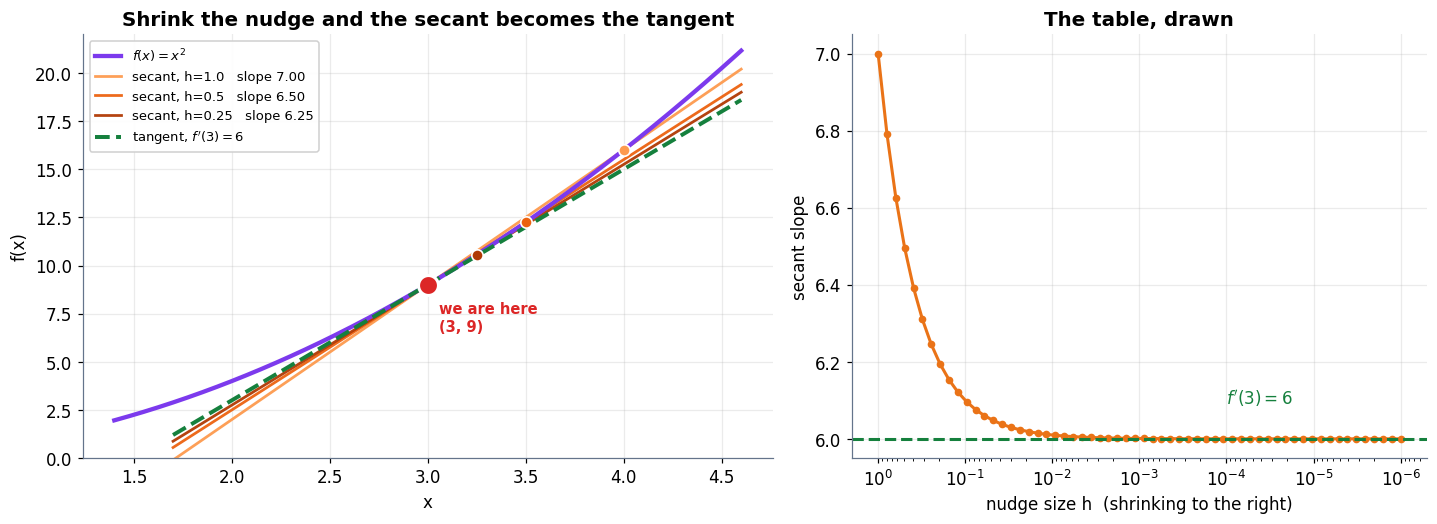

secant slope at h=1e-6 : 6.00000100
exact derivative 2x    : 6.00000000


In [4]:
# ============================================================
#  Figure: secants collapsing onto the tangent at x = 3
# ============================================================
fig = plt.figure(figsize=(13.2, 4.9))
gs = fig.add_gridspec(1, 2, width_ratios=[1.2, 1])

ax1 = fig.add_subplot(gs[0])
xs = np.linspace(1.4, 4.6, 300)
ax1.plot(xs, f(xs), color=C_MODEL, lw=2.8, label="$f(x)=x^2$", zorder=3)

hs = [1.0, 0.5, 0.25]
shades = plt.cm.Oranges(np.linspace(0.45, 0.85, len(hs)))
for h, col in zip(hs, shades):
    m = (f(x0 + h) - f(x0)) / h
    ax1.plot([x0 - 1.3, x0 + 1.6], [f(x0) - 1.3 * m, f(x0) + 1.6 * m],
             color=col, lw=1.8, alpha=0.95, zorder=2,
             label=f"secant, h={h}   slope {m:.2f}")
    ax1.scatter([x0 + h], [f(x0 + h)], s=55, color=col, zorder=5,
                edgecolor="white", lw=1.1)

m_true = 2 * x0
ax1.plot([x0 - 1.3, x0 + 1.6], [f(x0) - 1.3 * m_true, f(x0) + 1.6 * m_true],
         color=C_TRUE, lw=2.6, ls="--", zorder=4,
         label=f"tangent, $f'(3)={m_true:.0f}$")
ax1.scatter([x0], [f(x0)], s=170, color=C_ERR, zorder=6, edgecolor="white", lw=2)
ax1.text(x0 + 0.06, f(x0) - 2.4, "we are here\n(3, 9)", color=C_ERR,
         fontsize=9.6, fontweight="bold")
ax1.set_ylim(0, 22)
tidy(ax1, "x", "f(x)", "Shrink the nudge and the secant becomes the tangent", legend=True)
ax1.legend(fontsize=8.6, loc="upper left")

ax2 = fig.add_subplot(gs[1])
h_grid = np.logspace(0, -6, 60)
slopes = (f(x0 + h_grid) - f(x0)) / h_grid
ax2.semilogx(h_grid, slopes, "o-", color=C_PRED, lw=2.0, ms=4)
ax2.axhline(m_true, color=C_TRUE, ls="--", lw=2.0)
ax2.text(1e-4, m_true + 0.09, f"$f'(3) = {m_true:.0f}$", color=C_TRUE,
         fontsize=11, fontweight="bold")
ax2.invert_xaxis()
tidy(ax2, "nudge size h  (shrinking to the right)", "secant slope",
     "The table, drawn")
plt.tight_layout(); plt.show()

print(f"secant slope at h=1e-6 : {(f(x0+1e-6)-f(x0))/1e-6:.8f}")
print(f"exact derivative 2x    : {m_true:.8f}")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows


**Left — the geometry.** Horizontal is $x$, vertical is $f(x)=x^2$. The purple curve is the loss; the red dot at $(3, 9)$ is where you are standing. Each orange line is a **secant**: the straight line through your point and one nudged point $h$ to the right. As $h$ shrinks from 1 to 0.5 to 0.25, the orange lines rotate and settle onto the green dashed **tangent**, whose slope is exactly 6.

**Right — the same story as numbers.** Horizontal is the nudge size $h$ on a log axis, *shrinking as you move right*; vertical is the secant slope it produces. The curve flattens onto the green line at 6. This is the printed table with the dots joined up.

**What to look for:** the left panel is not three approximations to a curve — it is three approximations to a **number**. The whole point of the derivative is to squeeze a family of two-point slopes down to a single one-point slope, and the right panel is the squeeze happening.

**The common misread:** that the tangent line is "the derivative". The tangent is a *picture* of the derivative; the derivative itself is the single number 6 — the slope of that line. When we later carry gradients through a hundred layers, we carry numbers like 6, never lines.


</div>

## 1.2 ✅ The Part That Actually Matters: The **Sign**

$f'(3) = +6$. Read that out loud in words rather than symbols:

> *"At $x = 3$, increasing $x$ increases the error — at a rate of 6 units of error per unit of $x$."*

So to reduce the error, go **the other way**: decrease $x$. That single sentence is gradient descent in one dimension, and it is the reason calculus is in this book at all. (The word *gradient* is doing no work yet — with one knob there is only one slope. Part 2 earns the word properly, and Part 3 turns it into an update rule.)

$$ \textbf{step against the sign of the derivative} $$

- $f'(x) > 0$ → the ground rises to the right → move **left**.
- $f'(x) < 0$ → the ground rises to the left → move **right**.
- $f'(x) = 0$ → the ground is flat → you are at a bottom, a top, or a ledge.

The magnitude is the second gift: $|f'|$ tells you *how* steep, which is how far it is worth stepping.


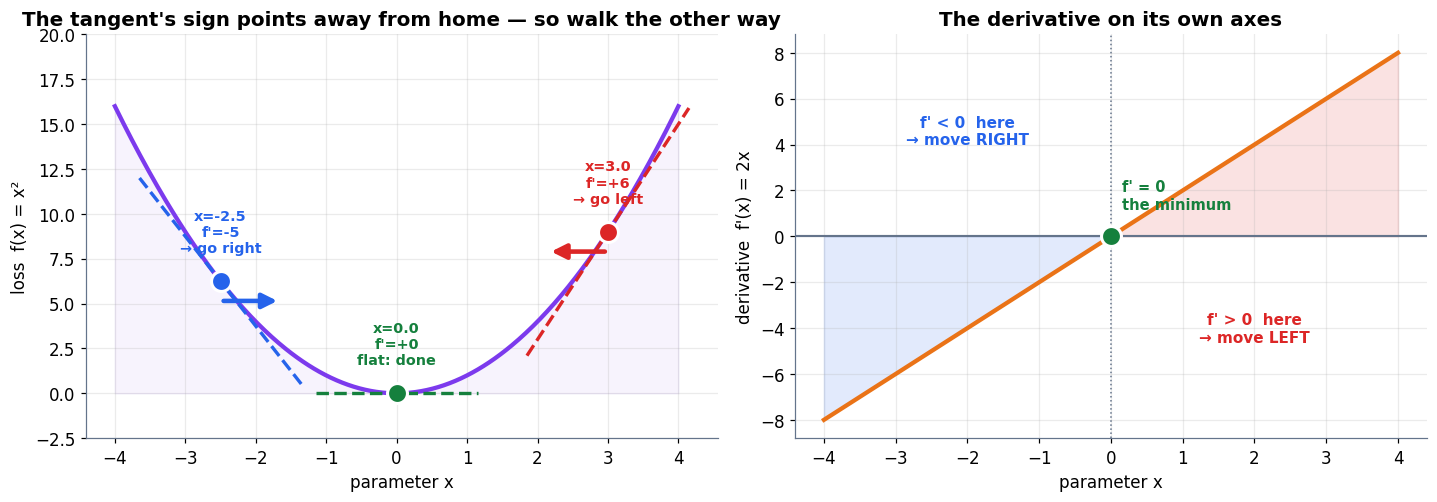

  x =  -2.5   f'(x) =  -5.0   ->  step right
  x =   0.0   f'(x) =   0.0   ->  step nowhere — flat
  x =   3.0   f'(x) =   6.0   ->  step left


In [5]:
# ============================================================
#  Figure: the sign of the derivative IS the direction home
# ============================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13.2, 4.7))

xs = np.linspace(-4, 4, 400)
ax1.plot(xs, xs ** 2, color=C_MODEL, lw=2.8, zorder=2)
ax1.fill_between(xs, 0, xs ** 2, color=C_MODEL, alpha=0.06)

for xp, col in [(-2.5, C_DATA), (3.0, C_ERR), (0.0, C_TRUE)]:
    slope = 2 * xp
    ax1.scatter([xp], [xp ** 2], s=170, color=col, zorder=6,
                edgecolor="white", lw=2)
    tl = np.linspace(xp - 1.15, xp + 1.15, 2)
    ax1.plot(tl, xp ** 2 + slope * (tl - xp), color=col, lw=2.2, ls="--", zorder=4)
    if slope != 0:
        step = -0.85 * np.sign(slope)          # step AGAINST the sign
        ax1.annotate("", xy=(xp + step, xp ** 2 - 1.1), xytext=(xp, xp ** 2 - 1.1),
                     arrowprops=dict(arrowstyle="-|>", color=col, lw=3.0,
                                     mutation_scale=20))
    lab = f"x={xp:.1f}\nf'={slope:+.0f}"
    lab += "\n→ go left" if slope > 0 else ("\n→ go right" if slope < 0 else "\nflat: done")
    ax1.text(xp, xp ** 2 + 1.6, lab, ha="center", fontsize=9.4,
             color=col, fontweight="bold")
ax1.set_ylim(-2.5, 20)
tidy(ax1, "parameter x", "loss  f(x) = x²",
     "The tangent's sign points away from home — so walk the other way")

ax2.plot(xs, 2 * xs, color=C_PRED, lw=2.8)
ax2.axhline(0, color=C_GREY, lw=1.4)
ax2.axvline(0, color=C_GREY, lw=1.0, ls=":")
ax2.fill_between(xs, 0, 2 * xs, where=(xs > 0), color=C_ERR, alpha=0.13)
ax2.fill_between(xs, 0, 2 * xs, where=(xs < 0), color=C_DATA, alpha=0.13)
ax2.text(2.0, -4.6, "f' > 0  here\n→ move LEFT", color=C_ERR, fontsize=10,
         fontweight="bold", ha="center")
ax2.text(-2.0, 4.0, "f' < 0  here\n→ move RIGHT", color=C_DATA, fontsize=10,
         fontweight="bold", ha="center")
ax2.scatter([0], [0], s=170, color=C_TRUE, zorder=6, edgecolor="white", lw=2)
ax2.text(0.15, 1.2, "f' = 0\nthe minimum", color=C_TRUE, fontsize=9.6,
         fontweight="bold")
tidy(ax2, "parameter x", "derivative  f'(x) = 2x",
     "The derivative on its own axes")
plt.tight_layout(); plt.show()

for xp in [-2.5, 0.0, 3.0]:
    d = 2 * xp
    where = "left" if d > 0 else ("right" if d < 0 else "nowhere — flat")
    print(f"  x = {xp:>5.1f}   f'(x) = {d:>5.1f}   ->  step {where}")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows


**Left — the loss and three standing positions.** Horizontal is the parameter, vertical is the loss $x^2$. Each dot is a place you might be standing; each dashed line is the tangent there, and each solid arrow is **the step you should take**, which always points *opposite* to the tangent's tilt. At $x=3$ the tangent rises steeply to the right ($f' = +6$), so the arrow points left. At $x=-2.5$ the tangent falls to the right ($f' = -5$), so the arrow points right. At $x=0$ the tangent is flat and there is no arrow to draw.

**Right — the derivative promoted to a curve of its own.** Horizontal is still the parameter, but vertical is now $f'(x) = 2x$ rather than $f(x)$. The red region is where the derivative is positive (move left), the blue region where it is negative (move right), and the green dot is the single crossing point where it is zero.

**What to look for:** the right panel contains *no information about how high the loss is* — and it does not need any. Direction is entirely determined by the sign, and step size by the magnitude. A model being trained never sees the left panel; it only ever gets one number from the right one.

**The common misread:** that you step *along* the gradient. You step **against** it — the minus sign that Part 3 makes official. The derivative is a signpost to the top of the hill, and the whole trick of learning is to read the signpost and then deliberately walk the opposite way.


</div>

## 1.3 📐 Four Rules That Cover Almost Everything

In practice nobody computes that limit by hand. A handful of rules do all the work, and these four cover the overwhelming majority of machine learning:

| Rule | Statement | Example |
|---|---|---|
| **Power** | $\dfrac{d}{dx}\,x^n = n\,x^{n-1}$ | $x^2 \to 2x$;  a constant $\to 0$ |
| **Sum** | $(u + v)' = u' + v'$ | $x^2 - 4x + 5 \to 2x - 4$ |
| **Product** | $(u \cdot v)' = u'v + uv'$ | $x^2 e^x \to 2xe^x + x^2e^x$ |
| **Chain** | $\dfrac{d}{dx} f(g(x)) = f'(g(x)) \cdot g'(x)$ | $(3x+1)^2 \to 2(3x+1)\cdot 3$ |

The last one is the important one. **Part 4 turns the chain rule into the whole of backpropagation** — every gradient in every neural network on Earth is that one line applied over and over.

Rather than trusting the table, let us check all four: symbolically with SymPy, and numerically with a finite difference.


In [6]:
# ============================================================
#  All four rules, verified twice: symbolically and numerically
# ============================================================
import sympy as sp

x = sp.Symbol("x")

def central_diff(fn, a, h=1e-5):
    """Numerical derivative. Central differences: error ~ h², far better than one-sided."""
    return (fn(a + h) - fn(a - h)) / (2 * h)

tests = [
    ("power",   x ** 5,                 lambda t: t ** 5,                       1.3),
    ("sum",     x ** 2 - 4 * x + 5,     lambda t: t ** 2 - 4 * t + 5,           0.7),
    ("product", x ** 2 * sp.exp(x),     lambda t: t ** 2 * np.exp(t),           0.9),
    ("chain",   (3 * x + 1) ** 2,       lambda t: (3 * t + 1) ** 2,             2.0),
    ("chain²",  sp.sin(x ** 2),         lambda t: np.sin(t ** 2),               1.1),
]

print(f"{'rule':<9}{'f(x)':<20}{'symbolic f\'(x)':<28}{'at a':>6}"
      f"{'sympy':>12}{'finite diff':>14}{'gap':>11}")
print("=" * 100)
for name, expr, fn, a in tests:
    d = sp.simplify(sp.diff(expr, x))
    sym_val = float(d.subs(x, a))
    num_val = central_diff(fn, a)
    print(f"{name:<9}{str(expr):<20}{str(d):<28}{a:>6.2f}"
          f"{sym_val:>12.6f}{num_val:>14.6f}{abs(sym_val-num_val):>11.2e}")
print("=" * 100)
print("Every rule agrees with brute-force nudging to ~1e-9. The rules are not magic;")
print("they are just the limit, pre-computed once so you never have to take it again.")


rule     f(x)                symbolic f'(x)                at a       sympy   finite diff        gap
power    x**5                5*x**4                        1.30   14.280500     14.280500   1.78e-09
sum      x**2 - 4*x + 5      2*x - 4                       0.70   -2.600000     -2.600000   1.41e-11
product  x**2*exp(x)         x*(x + 2)*exp(x)              0.90    6.419564      6.419564   4.66e-10
chain    (3*x + 1)**2        18*x + 6                      2.00   42.000000     42.000000   8.97e-10
chain²   sin(x**2)           2*x*cos(x**2)                 1.10    0.776643      0.776643   2.62e-10
Every rule agrees with brute-force nudging to ~1e-9. The rules are not magic;
they are just the limit, pre-computed once so you never have to take it again.


## 1.4 ✍️ One Worked Loss, End to End

Now the line the whole notebook is really about. Take a tiny loss with a single parameter $w$:

$$ L(w) = w^2 - 4w + 5 $$

**Differentiate** with the power and sum rules, term by term:

$$ \frac{d}{dw}\,w^2 = 2w, \qquad \frac{d}{dw}\,(-4w) = -4, \qquad \frac{d}{dw}\,5 = 0 $$

$$ \boxed{\,L'(w) = 2w - 4\,} $$

**Find the bottom** by setting the slope to zero:

$$ 2w - 4 = 0 \quad\Longrightarrow\quad w = 2, \qquad L(2) = 4 - 8 + 5 = 1 $$

<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ✅ Slope zero is the fingerprint of *done*

At the bottom of the bowl there is no downhill left to find, and the derivative says so by vanishing. Every optimiser in machine learning is, in the end, a search for a place where the slope is zero.

Note also that the minimum loss here is **1, not 0**. A flat spot means *"nothing better nearby"*, not *"no error"* — exactly the floor we hit in Notebook 1 when a straight line could not pass through three points.

</div>


L(w)  = w**2 - 4*w + 5
L'(w) = 2*w - 4    <- power rule + sum rule, checked by sympy
L'(w) = 0 at w = [2]   with L = [1.0]
second derivative L''(w) = 2 > 0  -> it is a MINIMUM, not a maximum

      w      L(w)     L'(w)   finite diff   verdict
--------------------------------------------------------------
   -1.0    10.000    -6.000     -6.000000   go right
    0.0     5.000    -4.000     -4.000000   go right
    1.0     2.000    -2.000     -2.000000   go right
    2.0     1.000     0.000      0.000000   STOP — bottom
    3.0     2.000     2.000      2.000000   go left
    5.0    10.000     6.000      6.000000   go left


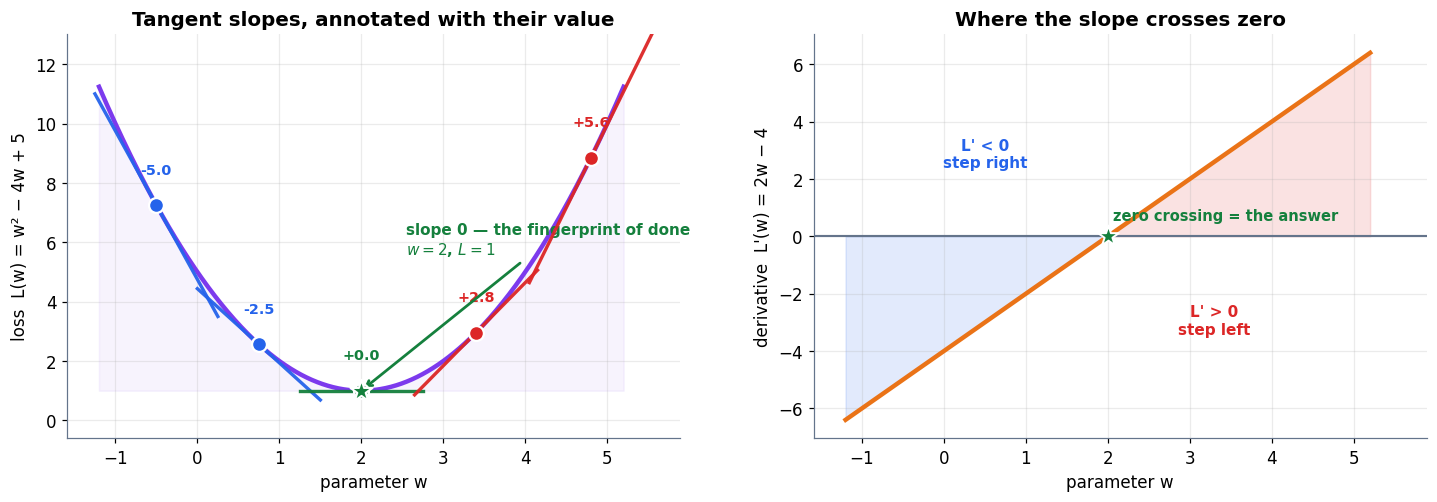

In [7]:
# ============================================================
#  L(w) = w² − 4w + 5 : derivative, stationary point, picture
# ============================================================
w_sym = sp.Symbol("w")
L_sym = w_sym ** 2 - 4 * w_sym + 5
dL_sym = sp.diff(L_sym, w_sym)
roots = sp.solve(sp.Eq(dL_sym, 0), w_sym)

print("L(w)  =", L_sym)
print("L'(w) =", dL_sym, "   <- power rule + sum rule, checked by sympy")
print("L'(w) = 0 at w =", roots, "  with L =", [float(L_sym.subs(w_sym, r)) for r in roots])
print("second derivative L''(w) =", sp.diff(L_sym, w_sym, 2), "> 0  -> it is a MINIMUM, not a maximum")
print()

def L(w):  return w ** 2 - 4 * w + 5
def dL(w): return 2 * w - 4

print(f"{'w':>7}{'L(w)':>10}{'L\'(w)':>10}{'finite diff':>14}   verdict")
print("-" * 62)
for wv in [-1.0, 0.0, 1.0, 2.0, 3.0, 5.0]:
    fd = (L(wv + 1e-5) - L(wv - 1e-5)) / 2e-5
    verdict = "go left" if dL(wv) > 1e-9 else ("go right" if dL(wv) < -1e-9 else "STOP — bottom")
    print(f"{wv:>7.1f}{L(wv):>10.3f}{dL(wv):>10.3f}{fd:>14.6f}   {verdict}")

# ============================================================
#  Figure: the bowl, its tangents, and the flat spot at w = 2
# ============================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13.2, 4.7), sharex=True)

ws = np.linspace(-1.2, 5.2, 400)
ax1.plot(ws, L(ws), color=C_MODEL, lw=2.9, zorder=3)
ax1.fill_between(ws, L(ws), L(ws).min(), color=C_MODEL, alpha=0.06)

for wp in [-0.5, 0.75, 2.0, 3.4, 4.8]:
    s = dL(wp)
    col = C_TRUE if abs(s) < 1e-9 else (C_ERR if s > 0 else C_DATA)
    seg = np.linspace(wp - 0.75, wp + 0.75, 2)
    ax1.plot(seg, L(wp) + s * (seg - wp), color=col, lw=2.2, alpha=0.95, zorder=4)
    ax1.scatter([wp], [L(wp)], s=95, color=col, zorder=6, edgecolor="white", lw=1.5)
    ax1.text(wp, L(wp) + 1.05, f"{s:+.1f}", ha="center", fontsize=9.4,
             color=col, fontweight="bold")

ax1.scatter([2.0], [1.0], s=230, marker="*", color=C_TRUE, zorder=7,
            edgecolor="white", lw=1.4)
ax1.annotate("slope 0 — the fingerprint of done\n$w=2$, $L=1$", xy=(2.0, 1.0),
             xytext=(2.55, 5.6), fontsize=10, color=C_TRUE, fontweight="bold",
             arrowprops=dict(arrowstyle="->", color=C_TRUE, lw=1.8))
ax1.set_ylim(-0.6, 13)
tidy(ax1, "parameter w", "loss  L(w) = w² − 4w + 5",
     "Tangent slopes, annotated with their value")

ax2.plot(ws, dL(ws), color=C_PRED, lw=2.9)
ax2.axhline(0, color=C_GREY, lw=1.4)
ax2.fill_between(ws, 0, dL(ws), where=(dL(ws) > 0), color=C_ERR, alpha=0.13)
ax2.fill_between(ws, 0, dL(ws), where=(dL(ws) < 0), color=C_DATA, alpha=0.13)
ax2.scatter([2.0], [0.0], s=200, marker="*", color=C_TRUE, zorder=6,
            edgecolor="white", lw=1.3)
ax2.text(3.3, -3.4, "L' > 0\nstep left", color=C_ERR, ha="center",
         fontsize=10, fontweight="bold")
ax2.text(0.5, 2.4, "L' < 0\nstep right", color=C_DATA, ha="center",
         fontsize=10, fontweight="bold")
ax2.text(2.06, 0.55, "zero crossing = the answer", color=C_TRUE,
         fontsize=9.6, fontweight="bold")
tidy(ax2, "parameter w", "derivative  L'(w) = 2w − 4", "Where the slope crosses zero")
plt.tight_layout(); plt.show()


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows


**Left — the bowl with its slopes written on it.** Horizontal is the parameter $w$, vertical is the loss $L(w) = w^2 - 4w + 5$. Five tangent lines are drawn, each labelled with its own slope. Red tangents ($L' > 0$) tilt up to the right; blue tangents ($L' < 0$) tilt down; the green one at $w=2$ is dead level. The green star marks the minimum, at height **1** rather than 0.

**Right — the same five slopes, plotted as their own function.** Horizontal is again $w$; vertical is now $L'(w) = 2w - 4$, a straight line. The single place it crosses zero is $w = 2$, and *solving that crossing is exactly what "training" means* for this one-parameter model.

**What to look for:** the tangent labels on the left get *smaller in magnitude* as you approach the star — $+5.6$, $-2.5$, $0$, $+2.8$. That shrinking is the self-braking effect from Notebook 1: as a fixed-step optimiser nears the bottom, the gradient shrinks and the steps shorten automatically, with nobody adjusting anything.

**The common misread:** treating "slope zero" as "loss zero". They are unrelated. Here the flat spot sits at $L = 1$, because the bowl's floor is at height 1. A converged model is one that cannot locally improve — not one that is right.


</div>

# Part 2 · From One Knob to Many — the Gradient ⭐⭐

<div style="background: linear-gradient(135deg, #fc466b 0%, #3f5efb 100%); padding: 28px; border-radius: 18px; color: white; margin: 12px 0;">


### A real model does not have one knob.

A small network has thousands. A large one has hundreds of billions. The loss is no longer $f(x)$ but $f(x_1, x_2, \dots, x_n)$, and "which way is downhill" stops being a choice between *left* and *right* — there are now infinitely many directions to step in.

The fix is almost insultingly simple: **wiggle one knob at a time, and stack the answers into a vector.** That vector is the gradient, and it has one property that makes the entire field of optimisation possible.


</div>

## 2.1 Partial Derivatives: Freeze Everything Else

To ask "how does the loss respond to $x_1$?", change $x_1$ and hold every other variable **fixed**. The derivative you get that way is a **partial derivative**, written with a curly $\partial$ instead of a straight $d$ to remind you that the other knobs were held still.

Take the two-variable bowl we will use for the rest of Part 2:

$$ f(x, y) = x^2 + 3y^2 $$

**Freeze $y$**, differentiate in $x$. The term $3y^2$ has no $x$ in it, so as far as $x$ is concerned it is a constant, and constants differentiate to zero:

$$ \frac{\partial f}{\partial x} = 2x $$

**Freeze $x$**, differentiate in $y$. Now $x^2$ is the constant:

$$ \frac{\partial f}{\partial y} = 6y $$

Evaluate both at the point $(x, y) = (2, 1)$:

$$ \frac{\partial f}{\partial x} = 2\cdot 2 = 4, \qquad \frac{\partial f}{\partial y} = 6\cdot 1 = 6 $$

Stack those two numbers into a vector and you have the **gradient**, written $\nabla f$ (say "grad f" or "del f"):

$$ \nabla f = \begin{bmatrix} \partial f/\partial x \\[2pt] \partial f/\partial y \end{bmatrix} = \begin{bmatrix} 4 \\ 6 \end{bmatrix} \quad\text{at } (2,1), \qquad \|\nabla f\| = \sqrt{4^2 + 6^2} = \sqrt{52} \approx 7.2 $$

<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🧠 The gradient is not a slope

A derivative is one number. A gradient is a **direction plus a magnitude** — a vector living in the same space as your parameters. Its direction is the way the function increases fastest; its length is *how fast*, along that fastest way.

That is the whole reason we can train models: out of infinitely many directions we could step, the gradient hands us the single best one, for the price of $n$ one-at-a-time wiggles.

</div>


f(x, y) = x**2 + 3*y**2
  ∂f/∂x = 2*x    (3y² was a constant, so it vanished)
  ∂f/∂y = 6*y    (x² was a constant, so it vanished)

at (x, y) = (2, 1),  f = 7
  by hand        ∇f = [4. 6.]
  by sympy       ∇f = [4. 6.]
  by wiggling    ∇f = [4.000000 6.000000]
  agreement                max gap = 1.15e-10

  magnitude  ||∇f|| = sqrt(4² + 6²) = sqrt(52) = 7.2111
  book quotes sqrt(52) ≈ 7.2 ; we compute 7.2111


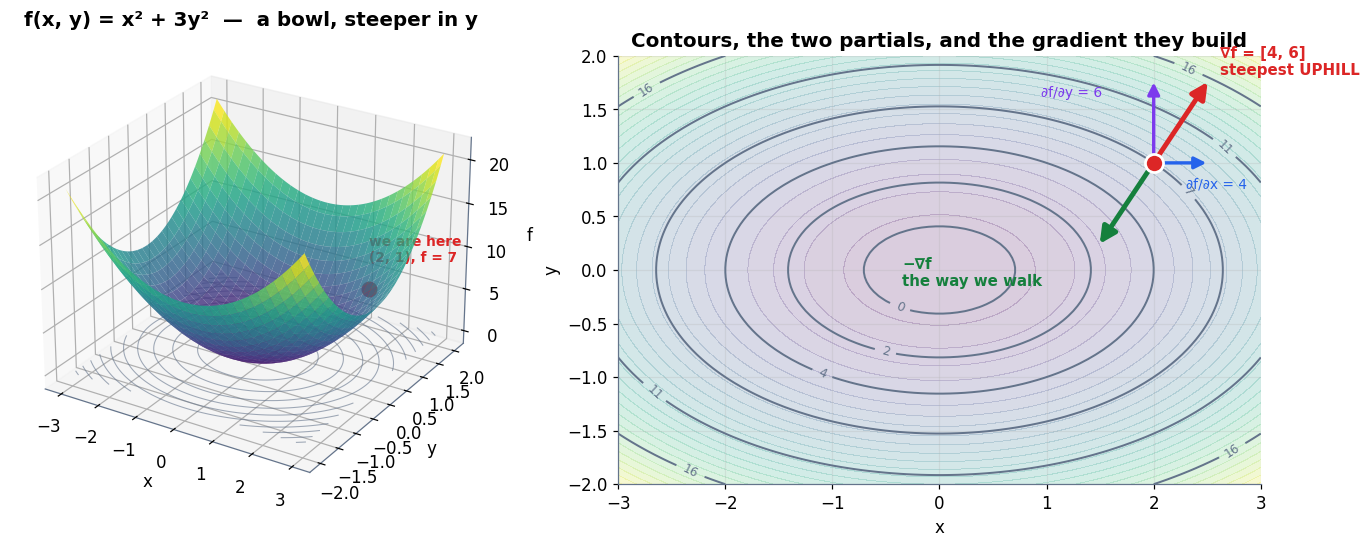

In [8]:
# ============================================================
#  Partials and the gradient, three independent ways
# ============================================================
xs_, ys_ = sp.symbols("x y")
f_sym = xs_ ** 2 + 3 * ys_ ** 2
fx_sym, fy_sym = sp.diff(f_sym, xs_), sp.diff(f_sym, ys_)

print("f(x, y) =", f_sym)
print("  ∂f/∂x =", fx_sym, "   (3y² was a constant, so it vanished)")
print("  ∂f/∂y =", fy_sym, "   (x² was a constant, so it vanished)")
print()

def f2(p):
    """The bowl, taking p = [x, y]."""
    return p[0] ** 2 + 3 * p[1] ** 2

def grad2(p):
    """∇f = [∂f/∂x, ∂f/∂y], worked out by hand once."""
    return np.array([2 * p[0], 6 * p[1]])

def numerical_grad(fn, p, h=1e-6):
    """Wiggle each coordinate one at a time — the definition, in code."""
    p = np.asarray(p, dtype=float)
    g = np.zeros_like(p)
    for i in range(p.size):
        e = np.zeros_like(p); e[i] = h
        g[i] = (fn(p + e) - fn(p - e)) / (2 * h)
    return g

P = np.array([2.0, 1.0])
g_hand = grad2(P)
g_sym  = np.array([float(fx_sym.subs({xs_: P[0], ys_: P[1]})),
                   float(fy_sym.subs({xs_: P[0], ys_: P[1]}))])
g_num  = numerical_grad(f2, P)

print(f"at (x, y) = ({P[0]:.0f}, {P[1]:.0f}),  f = {f2(P):.0f}")
print(f"  by hand        ∇f = {g_hand}")
print(f"  by sympy       ∇f = {g_sym}")
print(f"  by wiggling    ∇f = [{g_num[0]:.6f} {g_num[1]:.6f}]")
print(f"  agreement                max gap = {np.abs(g_hand - g_num).max():.2e}")
print()
print(f"  magnitude  ||∇f|| = sqrt({g_hand[0]:.0f}² + {g_hand[1]:.0f}²)"
      f" = sqrt({(g_hand**2).sum():.0f}) = {np.linalg.norm(g_hand):.4f}")
print(f"  book quotes sqrt(52) ≈ 7.2 ; we compute {np.linalg.norm(g_hand):.4f}")

# ============================================================
#  Figure: the bowl, its contours, and the gradient arrow
# ============================================================
gx = np.linspace(-3, 3, 90)
gy = np.linspace(-2, 2, 90)
GX, GY = np.meshgrid(gx, gy)
GZ = GX ** 2 + 3 * GY ** 2

fig = plt.figure(figsize=(13.4, 5.0))

ax1 = fig.add_subplot(1, 2, 1, projection="3d")
ax1.plot_surface(GX, GY, GZ, cmap="viridis", alpha=0.82, linewidth=0,
                 rstride=3, cstride=3, antialiased=True)
ax1.contour(GX, GY, GZ, levels=10, zdir="z", offset=0, colors=C_GREY,
            linewidths=0.7, alpha=0.6)
ax1.scatter([2], [1], [f2(P)], s=90, color=C_ERR, depthshade=False)
ax1.text(2, 1, f2(P) + 3.2, "we are here\n(2, 1), f = 7", color=C_ERR,
         fontsize=9, fontweight="bold")
ax1.set_xlabel("x"); ax1.set_ylabel("y"); ax1.set_zlabel("f")
ax1.set_title("f(x, y) = x² + 3y²  —  a bowl, steeper in y", pad=2)
ax1.view_init(elev=26, azim=-58)

ax2 = fig.add_subplot(1, 2, 2)
cs = ax2.contour(GX, GY, GZ, levels=[0.5, 2, 4, 7, 11, 16, 22], colors=C_GREY,
                 linewidths=1.3)
ax2.clabel(cs, inline=True, fontsize=8, fmt="%.0f")
ax2.contourf(GX, GY, GZ, levels=30, cmap="viridis", alpha=0.20)

g = grad2(P)
ax2.annotate("", xy=(P[0] + g[0] * 0.13, P[1] + g[1] * 0.13), xytext=tuple(P),
             arrowprops=dict(arrowstyle="-|>", color=C_ERR, lw=3.2, mutation_scale=22))
ax2.text(P[0] + 0.62, P[1] + 0.82, f"∇f = [{g[0]:.0f}, {g[1]:.0f}]\nsteepest UPHILL",
         color=C_ERR, fontsize=9.8, fontweight="bold")
ax2.annotate("", xy=(P[0] - g[0] * 0.13, P[1] - g[1] * 0.13), xytext=tuple(P),
             arrowprops=dict(arrowstyle="-|>", color=C_TRUE, lw=3.2, mutation_scale=22))
ax2.text(P[0] - 2.35, P[1] - 1.15, "−∇f\nthe way we walk", color=C_TRUE,
         fontsize=9.8, fontweight="bold")

# the two partials as their own little arrows
ax2.annotate("", xy=(P[0] + 0.52, P[1]), xytext=tuple(P),
             arrowprops=dict(arrowstyle="-|>", color=C_DATA, lw=2.2, mutation_scale=16))
ax2.text(P[0] + 0.30, P[1] - 0.24, "∂f/∂x = 4", color=C_DATA, fontsize=9)
ax2.annotate("", xy=(P[0], P[1] + 0.78), xytext=tuple(P),
             arrowprops=dict(arrowstyle="-|>", color=C_MODEL, lw=2.2, mutation_scale=16))
ax2.text(P[0] - 1.05, P[1] + 0.62, "∂f/∂y = 6", color=C_MODEL, fontsize=9)

ax2.scatter([P[0]], [P[1]], s=140, color=C_ERR, zorder=6, edgecolor="white", lw=1.8)
ax2.set_aspect("equal")
tidy(ax2, "x", "y", "Contours, the two partials, and the gradient they build")
plt.tight_layout(); plt.show()


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows


**Left — the loss as terrain.** Two parameters, so the loss is a surface rather than a curve: $x$ and $y$ run along the floor, height is $f = x^2 + 3y^2$. The red dot is the point $(2, 1)$ where $f = 7$. The bowl is **not round** — the $3$ in front of $y^2$ makes it three times steeper in the $y$ direction than in $x$, which is a fact you can see in the elongated shape and which will matter a great deal in Part 3.

**Right — the same bowl from directly above.** Grey rings are **contour lines**: sets of points with equal loss, labelled with their height, exactly like a map of a hill. The blue and purple arrows are the two partial derivatives, each computed by wiggling one axis with the other frozen — 4 units of rise per unit of $x$, 6 per unit of $y$. The thick red arrow is what you get by stacking them: $\nabla f = [4, 6]$, the **steepest uphill** direction. The green arrow is its negative, which is where training will actually walk.

**What to look for:** the red arrow crosses the contour rings at a **right angle**. That is not a coincidence of this drawing — §2.3 proves it must always happen.

**The common misread:** reading the red arrow as "the direction of the minimum". It is not. It is the direction of steepest *local* increase, so its negative is the steepest *local* decrease — which points at the bottom here only because this bowl happens to be symmetric about the origin. On a curved valley the negative gradient points across the valley wall, not at the exit.


</div>

## 2.2 📐 Why Does the Gradient Point *Steepest* Uphill?

This is usually stated and never justified. It deserves better, because the reason is one line of linear algebra — and it is the dot product you built in **Notebook 2** (`foundations_2_linear_algebra.ipynb`).

**Set-up.** Stand at a point and choose a direction to step: a **unit** vector $\mathbf{u}$ (length 1, so we are comparing directions fairly, not cheating by taking a longer step). Step a tiny distance $\varepsilon$ that way. How much does $f$ change?

$$ f(\mathbf{p} + \varepsilon\mathbf{u}) - f(\mathbf{p}) \;\approx\; \varepsilon \, \big(\nabla f \cdot \mathbf{u}\big) $$

That quantity $\nabla f \cdot \mathbf{u}$ is called the **directional derivative**: the rate of change of $f$ *along* $\mathbf{u}$.

**The argument.** Now write the dot product in its geometric form — the one Notebook 2 derived:

$$ \nabla f \cdot \mathbf{u} \;=\; \|\nabla f\|\,\|\mathbf{u}\|\cos\theta \;=\; \|\nabla f\|\cos\theta \qquad (\text{since } \|\mathbf{u}\| = 1) $$

where $\theta$ is the angle between your chosen direction and the gradient. Everything on the right is fixed except $\cos\theta$, and $\cos\theta$ is largest — exactly $1$ — when $\theta = 0$.

$$ \boxed{\;\text{The fastest increase happens when } \mathbf{u} \text{ points the same way as } \nabla f.\;} $$

Three free corollaries fall out of the same line:

- $\theta = 180°$: $\cos\theta = -1$, the **fastest decrease**. This is why the update rule has a minus sign.
- $\theta = 90°$: $\cos\theta = 0$, **no change at all** — you are walking along a contour.
- The maximum rate itself is $\|\nabla f\|$, which is why the gradient's *length* is the steepness.

Linear algebra hands calculus the reason this whole method works. Let us confirm it by brute force: try hundreds of directions and see which one wins.


Brute-force search over 3601 directions at the point (2, 1)
  fastest-climb direction found : 56.30°
  direction of ∇f = [4, 6]      : 56.31°
  best climb rate measured      : 7.2111
  ||∇f||                        : 7.2111
  slowest (steepest descent)    : -7.2111   =  −||∇f||
  max |measured − ||∇f||cosθ|   : 1.47e-10

The winner out of every direction tried is the gradient's own direction, and
the winning rate is exactly ||∇f||. Neither was assumed — both were measured.


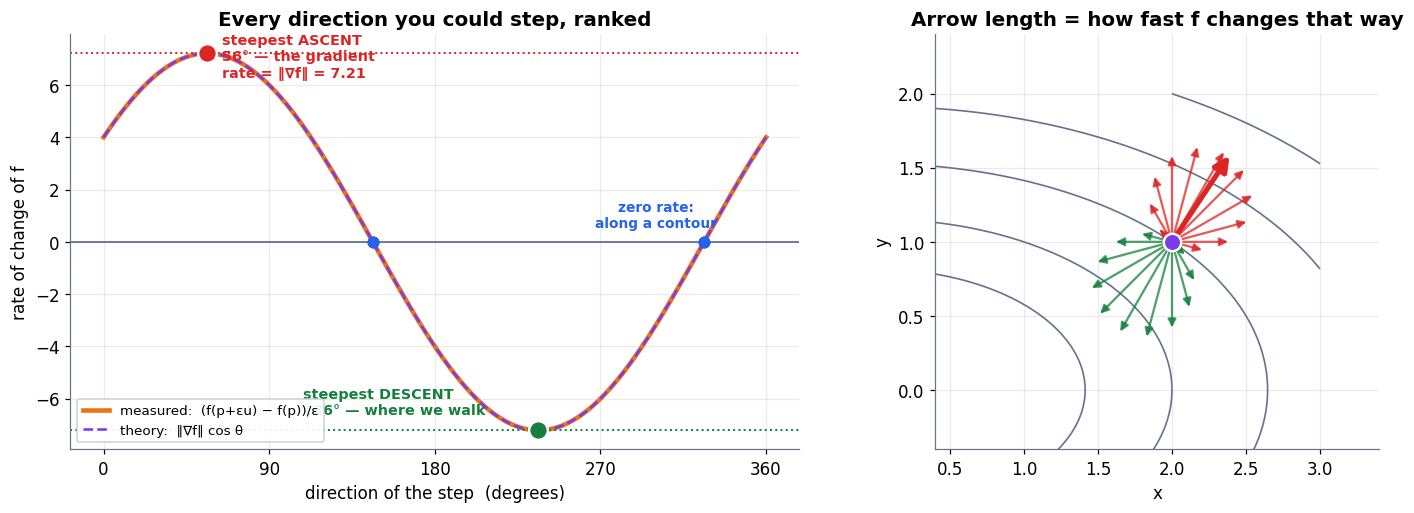

In [9]:
# ============================================================
#  Brute force: try every direction and see which climbs fastest
# ============================================================
angles = np.linspace(0, 2 * np.pi, 3601)         # every tenth of a degree
g = grad2(P)
g_hat = g / np.linalg.norm(g)

# (a) the honest measurement: actually step both ways and see how f changes
eps = 1e-5
measured = np.array([(f2(P + eps * np.array([np.cos(a), np.sin(a)]))
                      - f2(P - eps * np.array([np.cos(a), np.sin(a)]))) / (2 * eps)
                     for a in angles])
# (b) the theory: ∇f · u = ||∇f|| cos θ
theta_to_grad = angles - np.arctan2(g[1], g[0])
predicted = np.linalg.norm(g) * np.cos(theta_to_grad)

best = angles[np.argmax(measured)]
print(f"Brute-force search over {len(angles)} directions at the point (2, 1)")
print("=" * 66)
print(f"  fastest-climb direction found : {np.degrees(best):.2f}°")
print(f"  direction of ∇f = [4, 6]      : {np.degrees(np.arctan2(g[1], g[0])):.2f}°")
print(f"  best climb rate measured      : {measured.max():.4f}")
print(f"  ||∇f||                        : {np.linalg.norm(g):.4f}")
print(f"  slowest (steepest descent)    : {measured.min():.4f}   =  −||∇f||")
print(f"  max |measured − ||∇f||cosθ|   : {np.abs(measured - predicted).max():.2e}")
print()
print("The winner out of every direction tried is the gradient's own direction, and")
print("the winning rate is exactly ||∇f||. Neither was assumed — both were measured.")

# ============================================================
#  Figure: the cosine law of steepest ascent
# ============================================================
fig = plt.figure(figsize=(13.4, 4.8))
gs = fig.add_gridspec(1, 2, width_ratios=[1.25, 1])

ax1 = fig.add_subplot(gs[0])
ax1.plot(np.degrees(angles), measured, color=C_PRED, lw=3.0,
         label="measured:  (f(p+εu) − f(p))/ε")
ax1.plot(np.degrees(angles), predicted, color=C_MODEL, lw=1.7, ls="--",
         label="theory:  ‖∇f‖ cos θ")
ax1.axhline(0, color=C_GREY, lw=1.2)
ax1.axhline(np.linalg.norm(g), color=C_ERR, lw=1.3, ls=":")
ax1.axhline(-np.linalg.norm(g), color=C_TRUE, lw=1.3, ls=":")
ax1.scatter([np.degrees(best)], [measured.max()], s=150, color=C_ERR, zorder=6,
            edgecolor="white", lw=1.6)
ax1.text(np.degrees(best) + 8, measured.max() - 0.9,
         f"steepest ASCENT\n{np.degrees(best):.0f}° — the gradient\nrate = ‖∇f‖ = {np.linalg.norm(g):.2f}",
         color=C_ERR, fontsize=9.4, fontweight="bold")
worst = np.degrees(angles[np.argmin(measured)])
ax1.scatter([worst], [measured.min()], s=150, color=C_TRUE, zorder=6,
            edgecolor="white", lw=1.6)
ax1.text(worst - 128, measured.min() + 0.6,
         f"steepest DESCENT\n{worst:.0f}° — where we walk", color=C_TRUE,
         fontsize=9.4, fontweight="bold")
for zc in np.degrees(angles[np.where(np.abs(measured) < 0.02)]):
    ax1.scatter([zc], [0], s=45, color=C_DATA, zorder=5)
ax1.text(300, 0.55, "zero rate:\nalong a contour", color=C_DATA, fontsize=9,
         fontweight="bold", ha="center")
ax1.set_xticks([0, 90, 180, 270, 360])
tidy(ax1, "direction of the step  (degrees)", "rate of change of f",
     "Every direction you could step, ranked", legend=True)
ax1.legend(fontsize=8.8, loc="lower left")

ax2 = fig.add_subplot(gs[1])
ax2.contour(GX, GY, GZ, levels=[2, 4, 7, 11, 16], colors=C_GREY, linewidths=1.1)
for a in np.linspace(0, 2 * np.pi, 25)[:-1]:
    u = np.array([np.cos(a), np.sin(a)])
    rate = g @ u
    col = C_ERR if rate > 0 else C_TRUE
    ax2.annotate("", xy=tuple(P + 0.10 * abs(rate) * u), xytext=tuple(P),
                 arrowprops=dict(arrowstyle="-|>", color=col, lw=1.5,
                                 alpha=0.75, mutation_scale=11))
ax2.annotate("", xy=tuple(P + 0.10 * np.linalg.norm(g) * g_hat), xytext=tuple(P),
             arrowprops=dict(arrowstyle="-|>", color=C_ERR, lw=3.4, mutation_scale=20))
ax2.scatter([P[0]], [P[1]], s=130, color=C_MODEL, zorder=6, edgecolor="white", lw=1.6)
ax2.set_xlim(0.4, 3.4); ax2.set_ylim(-0.4, 2.4); ax2.set_aspect("equal")
tidy(ax2, "x", "y", "Arrow length = how fast f changes that way")
plt.tight_layout(); plt.show()


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows


**Left — every possible direction, ranked.** Horizontal is the compass bearing of the step, from 0° to 360°; vertical is how fast $f$ changes if you step that way. The thick orange curve was **measured** by actually stepping a tenth of a degree at a time — 3,601 directions — and watching $f$ move; the thin dashed purple curve is the prediction $\|\nabla f\|\cos\theta$. They lie on top of each other to about $10^{-9}$ — the theory is not an approximation of the experiment, it *is* the experiment.

**The three dotted lines are the three corollaries.** The red ceiling at $+7.21$ is $\|\nabla f\|$, touched exactly once, at the gradient's own bearing of 56°. The green floor at $-7.21$ is steepest descent, at 236° — exactly 180° opposite. The blue dots where the curve crosses zero are the directions along which $f$ does not change at all: the contour directions, and they sit exactly 90° from the gradient.

**Right — the same ranking drawn on the map.** Every short arrow is a candidate direction, with its length proportional to how fast $f$ changes and its colour showing the sign (red = uphill, green = downhill). The thick red arrow is the gradient. You can see the family of arrows form a smooth lobe — that lobe is the cosine curve from the left panel, wrapped around a point.

**The common misread:** thinking steepest descent is the *fastest route to the minimum*. It is only the best direction **right here**, for an infinitesimal step. On a stretched bowl like this one, following it exactly produces the zig-zag you will see in Part 3 — locally optimal, globally impatient.


</div>

## 2.3 The Gradient Is Perpendicular to the Contours

The figure showed it; here is why it *must* be true, in two lines.

A contour line is the set of points where $f$ stays **constant**. Walk along it and, by definition, $f$ does not change — so the directional derivative in the contour's own direction $\mathbf{t}$ is zero:

$$ \nabla f \cdot \mathbf{t} = 0 $$

But a dot product of two non-zero vectors is zero exactly when they are **perpendicular** (Notebook 2, §on orthogonality). Therefore $\nabla f \perp \mathbf{t}$: the gradient always crosses the contour lines at a right angle.

This is a genuinely useful mental image. Contours are the *"no progress"* directions; the gradient is the one that leaves them as fast as possible.


In [10]:
# ============================================================
#  Perpendicularity, measured
# ============================================================
# Walk along the contour f = 7 through (2, 1). Parametrise it as an ellipse:
#   x = √7 cos t, y = √(7/3) sin t     (check: x² + 3y² = 7 for all t)
t = np.arccos(2 / np.sqrt(7))
pt = np.array([np.sqrt(7) * np.cos(t), np.sqrt(7 / 3) * np.sin(t)])
tangent = np.array([-np.sqrt(7) * np.sin(t), np.sqrt(7 / 3) * np.cos(t)])
tangent /= np.linalg.norm(tangent)

gg = grad2(pt)
print(f"point on the contour f = 7 :  ({pt[0]:.6f}, {pt[1]:.6f})   f = {f2(pt):.6f}")
print(f"unit tangent to the contour:  [{tangent[0]:.6f}, {tangent[1]:.6f}]")
print(f"gradient there             :  [{gg[0]:.6f}, {gg[1]:.6f}]")
print()
print(f"  ∇f · t          = {gg @ tangent:.2e}      (zero: walking the contour changes nothing)")
print(f"  angle between   = {np.degrees(np.arccos(np.clip(gg @ tangent / np.linalg.norm(gg), -1, 1))):.4f}°")
print()
# and confirm f really is flat along the tangent
for step in [1e-3, 1e-4]:
    print(f"  f(p + {step:g}·t) − f(p) = {f2(pt + step*tangent) - f2(pt):+.3e}"
          f"   vs  f(p + {step:g}·∇f/‖∇f‖) − f(p) = "
          f"{f2(pt + step*gg/np.linalg.norm(gg)) - f2(pt):+.3e}")


point on the contour f = 7 :  (2.000000, 1.000000)   f = 7.000000
unit tangent to the contour:  [-0.832050, 0.554700]
gradient there             :  [4.000000, 6.000000]

  ∇f · t          = 8.88e-16      (zero: walking the contour changes nothing)
  angle between   = 90.0000°

  f(p + 0.001·t) − f(p) = +1.615e-06   vs  f(p + 0.001·∇f/‖∇f‖) − f(p) = +7.213e-03
  f(p + 0.0001·t) − f(p) = +1.615e-08   vs  f(p + 0.0001·∇f/‖∇f‖) − f(p) = +7.211e-04


<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ✅ Part 2 takeaway


A **partial derivative** is an ordinary derivative taken with every other variable frozen. Stack all of them and you have the **gradient** — a vector, not a number.

It points **steepest uphill**, its length is **how steep**, and it sits **perpendicular to the contours**. None of that is decoration: the first fact gives training its direction, the second gives it a step size, and all three follow from one dot product, $\nabla f \cdot \mathbf{u} = \|\nabla f\| \cos\theta$.

🔗 That dot product is the one you built in `foundations_2_linear_algebra.ipynb`. This is the moment linear algebra pays calculus back.


</div>

# Part 3 · Gradient Descent — Turning the Compass Into Learning ⭐⭐

<div style="background: linear-gradient(135deg, #fc466b 0%, #3f5efb 100%); padding: 28px; border-radius: 18px; color: white; margin: 12px 0;">


### We wanted downhill. The gradient gives us uphill. So we walk the other way.

$$ \theta \leftarrow \theta - \eta \, \nabla L(\theta) $$

This is the **UPDATE** box from Notebook 1, now fully opened. It is one line, it has trained every model in this book, and it has trained every model you have ever used. Part 3 works it by hand, then breaks it on purpose.


</div>

## 3.1 The Update Rule, Term by Term

$$ \theta \;\leftarrow\; \theta \;-\; \eta \, \nabla L(\theta) $$

| Symbol | Name | What it is |
|---|---|---|
| $\theta$ | **parameters** | every number the model is allowed to change, bundled into one vector |
| $\nabla L(\theta)$ | **gradient** | the steepest-uphill direction of the loss, *at the current parameters* |
| $\eta$ | **learning rate** | a small positive number: how far to step |
| $-$ | the minus sign | the entire reason this is descent and not ascent |

Two things are worth saying out loud before we run it:

1. **The gradient is re-evaluated every step.** It is a *local* reading, valid where you are standing; move, and it changes. Training is a sequence of local decisions, never a global plan.
2. **$\eta$ is not part of the mathematics.** The gradient is a fact about your loss; $\eta$ is a choice you make. That separation is exactly where §3.3 goes wrong on purpose.

### ✍️ Three steps by hand

Bowl: $f(x, y) = x^2 + 3y^2$, gradient $\nabla f = [2x,\; 6y]$, start $(2, 1)$, learning rate $\eta = 0.1$.

**Start.** $f(2,1) = 4 + 3 = 7$. Gradient $= [4, 6]$.

**Step 1.** $x \leftarrow 2 - 0.1(4) = 1.6$; $y \leftarrow 1 - 0.1(6) = 0.4$. New loss $= 1.6^2 + 3(0.4)^2 = 2.56 + 0.48 = 3.04$.

**Step 2.** Gradient at $(1.6, 0.4)$ is $[3.2, 2.4]$. $x \leftarrow 1.28$, $y \leftarrow 0.16$. Loss $= 1.6384 + 0.0768 = 1.7152$.

**Step 3.** Gradient $[2.56, 0.96]$. $x \leftarrow 1.024$, $y \leftarrow 0.064$. Loss $\approx 1.0609$.

$$ 7 \;\to\; 3.04 \;\to\; 1.72 \;\to\; 1.06 $$

and we never once saw the whole surface. Only the slope under our feet, three times. Now let the machine check the arithmetic.


In [11]:
# ============================================================
#  Three steps of gradient descent, printed to full precision
# ============================================================
p = np.array([2.0, 1.0])
eta = 0.1

print("f(x,y) = x² + 3y² ,  ∇f = [2x, 6y] ,  η = 0.1")
print("=" * 74)
print(f"{'step':>5}{'x':>12}{'y':>12}{'loss':>14}{'∇f':>22}")
print("-" * 74)
trace = []
for step in range(4):
    gp = grad2(p)
    trace.append((step, p.copy(), f2(p)))
    print(f"{step:>5}{p[0]:>12.6f}{p[1]:>12.6f}{f2(p):>14.6f}"
          f"{'[' + f'{gp[0]:.3f}, {gp[1]:.3f}' + ']':>22}")
    p = p - eta * gp                       # θ ← θ − η∇L(θ)
print("-" * 74)

book = [7, 3.04, 1.715, 1.06]
ours = [t[2] for t in trace]
print(f"{'book quotes':<16}" + "".join(f"{b:>12}" for b in book))
print(f"{'we compute':<16}" + "".join(f"{o:>12.6f}" for o in ours))
print()
print("Exact match (the book rounds 1.7152 -> 1.715 and 1.060864 -> 1.06).")
print(f"The bowl's true minimum is f(0,0) = 0; after 3 steps we are at {ours[-1]:.4f}.")


f(x,y) = x² + 3y² ,  ∇f = [2x, 6y] ,  η = 0.1
 step           x           y          loss                    ∇f
--------------------------------------------------------------------------
    0    2.000000    1.000000      7.000000        [4.000, 6.000]
    1    1.600000    0.400000      3.040000        [3.200, 2.400]
    2    1.280000    0.160000      1.715200        [2.560, 0.960]
    3    1.024000    0.064000      1.060864        [2.048, 0.384]
--------------------------------------------------------------------------
book quotes                7        3.04       1.715        1.06
we compute          7.000000    3.040000    1.715200    1.060864

Exact match (the book rounds 1.7152 -> 1.715 and 1.060864 -> 1.06).
The bowl's true minimum is f(0,0) = 0; after 3 steps we are at 1.0609.


## 3.2 The Same Loop as Ten Lines of NumPy

Everything above, with the narration removed. This is what `torch` and `keras` run underneath — minus the framework machinery, and minus the part where they work out `grad` for you.


In [12]:
# ============================================================
#  Gradient descent, complete, in ten lines
# ============================================================
import numpy as np

def loss(p):                       # p = [x, y]
    return p[0] ** 2 + 3 * p[1] ** 2

def grad(p):                       # ∇f = [∂f/∂x, ∂f/∂y]
    return np.array([2 * p[0], 6 * p[1]])

p = np.array([2.0, 1.0])           # starting parameters
eta = 0.1                          # learning rate
for step in range(4):
    print(step, p, loss(p))
    p = p - eta * grad(p)          # θ ← θ − η∇L(θ)

print()
print("Notice what is NOT here: there is no calculus at runtime.")
print("We differentiated once, by hand, and the loop only evaluates and subtracts.")
print("A real network has millions of parameters and nobody differentiates by hand —")
print("which is exactly the problem Parts 4 and 5 solve.")


0 [2. 1.] 7.0
1 [1.6 0.4] 3.04
2 [1.28 0.16] 1.7152
3 [1.024 0.064] 1.060864

Notice what is NOT here: there is no calculus at runtime.
We differentiated once, by hand, and the loop only evaluates and subtracts.
A real network has millions of parameters and nobody differentiates by hand —
which is exactly the problem Parts 4 and 5 solve.


## 3.3 ⚠️ The Pitfall Everyone Hits First: the Step That Overshoots

The gradient tells you the direction downhill and how steep it is **right here**. It says nothing whatsoever about **how far away the bottom is**. A step of size $\eta$ can sail straight past the valley floor and land higher up the opposite wall.

Watch it happen on the same bowl. Follow only the $y$ coordinate, whose slope is $\partial f / \partial y = 6y$, start at $y = 1$, and set $\eta = 0.4$:

**Step 1.** $y \leftarrow 1 - 0.4(6 \cdot 1) = 1 - 2.4 = -1.4$. We aimed at 0 and shot past it to $-1.4$ — *further from the minimum than we started.*

**Step 2.** Gradient is now $6(-1.4) = -8.4$, so $y \leftarrow -1.4 - 0.4(-8.4) = -1.4 + 3.36 = +1.96$. Further still.

The loss climbs $3 \to 5.88 \to 11.5$ instead of falling. **The direction was correct every single time.** The size was not.

### 📐 Exactly when does this happen?

For this bowl the $y$-update is a pure multiplication:

$$ y \leftarrow y - \eta(6y) = (1 - 6\eta)\,y $$

Each step multiplies $y$ by the fixed factor $(1 - 6\eta)$. So the sequence shrinks toward zero if and only if that factor has magnitude less than 1:

$$ |1 - 6\eta| < 1 \quad\Longleftrightarrow\quad 0 < \eta < \tfrac{1}{3} $$

- $\eta = 0.1$: factor $= 0.4$ → $y$ shrinks by 60% per step. ✅
- $\eta = 1/6 \approx 0.167$: factor $= 0$ → lands on the minimum in **one** step. 🎯
- $\eta = 0.4$: factor $= -1.4$ → $y$ flips sign **and grows 40% every step**. 💥

The alternating sign is the fingerprint: a diverging run does not wander off, it *ping-pongs* across the valley with growing amplitude.


In [13]:
# ============================================================
#  Divergence, computed — and the exact stability threshold
# ============================================================
print("y-only descent on 3y²  (slope 6y), starting at y = 1")
print("=" * 72)
for eta_try in [0.1, 0.4]:
    y = 1.0
    factor = 1 - 6 * eta_try
    print(f"\n  η = {eta_try}   ->  each step multiplies y by (1 − 6η) = {factor:+.2f}")
    print(f"    {'step':>6}{'y':>14}{'loss 3y²':>14}")
    for s in range(4):
        print(f"    {s:>6}{y:>14.6f}{3 * y ** 2:>14.6f}")
        y = y - eta_try * (6 * y)
    print(f"    verdict: {'CONVERGING' if abs(factor) < 1 else 'DIVERGING'}")

print("\n" + "=" * 72)
print("Book quotes for η = 0.4 :  y  1 → −1.4 → +1.96      loss  3 → 5.88 → 11.5")
y = 1.0; ys = []; ls = []
for s in range(3):
    ys.append(y); ls.append(3 * y ** 2); y = y - 0.4 * 6 * y
print(f"We compute              :  y  {ys[0]:g} → {ys[1]:g} → {ys[2]:g}"
      f"      loss  {ls[0]:g} → {ls[1]:g} → {ls[2]:g}")
print()
print("Stability threshold |1 − 6η| < 1  ->  0 < η < 1/3 = 0.3333...")
for eta_try in [0.30, 1/3, 0.34]:
    y = 1.0
    for _ in range(60): y = y - eta_try * 6 * y
    print(f"  η = {eta_try:.4f}  ->  |y| after 60 steps = {abs(y):.4e}"
          f"   ({'stable' if abs(y) < 1 else 'blown up'})")


y-only descent on 3y²  (slope 6y), starting at y = 1

  η = 0.1   ->  each step multiplies y by (1 − 6η) = +0.40
      step             y      loss 3y²
         0      1.000000      3.000000
         1      0.400000      0.480000
         2      0.160000      0.076800
         3      0.064000      0.012288
    verdict: CONVERGING

  η = 0.4   ->  each step multiplies y by (1 − 6η) = -1.40
      step             y      loss 3y²
         0      1.000000      3.000000
         1     -1.400000      5.880000
         2      1.960000     11.524800
         3     -2.744000     22.588608
    verdict: DIVERGING

Book quotes for η = 0.4 :  y  1 → −1.4 → +1.96      loss  3 → 5.88 → 11.5
We compute              :  y  1 → -1.4 → 1.96      loss  3 → 5.88 → 11.5248

Stability threshold |1 − 6η| < 1  ->  0 < η < 1/3 = 0.3333...
  η = 0.3000  ->  |y| after 60 steps = 1.5325e-06   (stable)
  η = 0.3333  ->  |y| after 60 steps = 1.0000e+00   (blown up)
  η = 0.3400  ->  |y| after 60 steps = 1.0520e+01   

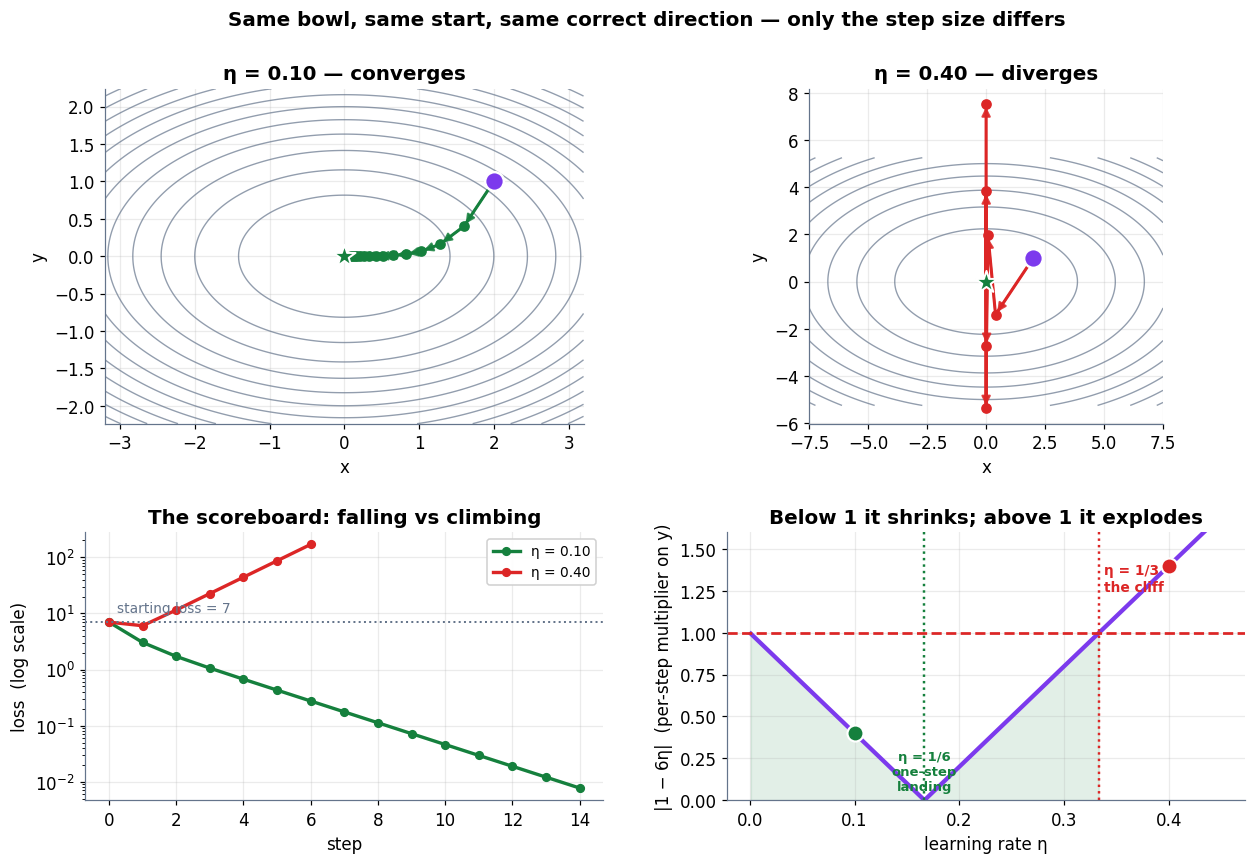

In [14]:
# ============================================================
#  Figure: converge vs diverge, on the map and on the scoreboard
# ============================================================
def descend(p0, eta, steps=14):
    p, path = np.array(p0, dtype=float), [np.array(p0, dtype=float)]
    for _ in range(steps):
        p = p - eta * grad2(p)
        path.append(p.copy())
    return np.array(path)

good = descend([2.0, 1.0], 0.10)
bad  = descend([2.0, 1.0], 0.40, steps=6)

fig = plt.figure(figsize=(13.6, 8.4))
gs = fig.add_gridspec(2, 2, height_ratios=[1.25, 1], hspace=0.36, wspace=0.24)

for col, (path, e, name, colr) in enumerate(
        [(good, 0.10, "η = 0.10 — converges", C_TRUE),
         (bad,  0.40, "η = 0.40 — diverges",  C_ERR)]):
    ax = fig.add_subplot(gs[0, col])
    lim = 3.2 if col == 0 else 7.5
    gx2 = np.linspace(-lim, lim, 140); gy2 = np.linspace(-lim * 0.7, lim * 0.7, 140)
    A, B = np.meshgrid(gx2, gy2)
    Z = A ** 2 + 3 * B ** 2
    ax.contour(A, B, Z, levels=12, colors=C_GREY, linewidths=0.9, alpha=0.7)
    ax.plot(path[:, 0], path[:, 1], "o-", color=colr, lw=2.0, ms=6, zorder=4)
    for i in range(len(path) - 1):
        ax.annotate("", xy=path[i + 1], xytext=path[i],
                    arrowprops=dict(arrowstyle="-|>", color=colr, lw=1.4,
                                    alpha=0.85, mutation_scale=12))
    ax.scatter([2], [1], s=150, color=C_MODEL, zorder=6, edgecolor="white", lw=1.6)
    ax.scatter([0], [0], s=230, marker="*", color=C_TRUE, zorder=6,
               edgecolor="white", lw=1.3)
    ax.set_aspect("equal")
    tidy(ax, "x", "y", name)

ax3 = fig.add_subplot(gs[1, 0])
ax3.semilogy([f2(q) for q in good], "o-", color=C_TRUE, lw=2.2, ms=5,
             label="η = 0.10")
ax3.semilogy([f2(q) for q in bad], "o-", color=C_ERR, lw=2.2, ms=5,
             label="η = 0.40")
ax3.axhline(f2(good[0]), color=C_GREY, ls=":", lw=1.3)
ax3.text(0.25, f2(good[0]) * 1.5, "starting loss = 7", color=C_GREY, fontsize=9)
tidy(ax3, "step", "loss  (log scale)", "The scoreboard: falling vs climbing", legend=True)

ax4 = fig.add_subplot(gs[1, 1])
etas = np.linspace(0.001, 0.45, 400)
ax4.plot(etas, np.abs(1 - 6 * etas), color=C_MODEL, lw=2.8)
ax4.axhline(1.0, color=C_ERR, lw=1.8, ls="--")
ax4.axvline(1 / 3, color=C_ERR, lw=1.6, ls=":")
ax4.axvline(1 / 6, color=C_TRUE, lw=1.6, ls=":")
ax4.fill_between(etas, 0, np.abs(1 - 6 * etas), where=(np.abs(1 - 6 * etas) < 1),
                 color=C_TRUE, alpha=0.12)
ax4.scatter([0.1], [abs(1 - 0.6)], s=110, color=C_TRUE, zorder=6,
            edgecolor="white", lw=1.4)
ax4.scatter([0.4], [abs(1 - 2.4)], s=110, color=C_ERR, zorder=6,
            edgecolor="white", lw=1.4)
ax4.text(1 / 6, 0.06, "η = 1/6\none-step\nlanding", color=C_TRUE, fontsize=8.6,
         ha="center", fontweight="bold")
ax4.text(1 / 3 + 0.005, 1.25, "η = 1/3\nthe cliff", color=C_ERR, fontsize=9,
         fontweight="bold")
ax4.set_ylim(0, 1.6)
tidy(ax4, "learning rate η", "|1 − 6η|  (per-step multiplier on y)",
     "Below 1 it shrinks; above 1 it explodes")
fig.suptitle("Same bowl, same start, same correct direction — only the step size differs",
             fontsize=13, fontweight="bold", y=0.965)
plt.show()


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows


**Top left, $\eta = 0.10$.** The map from above: grey ellipses are contours, purple dot is the start $(2,1)$, green star is the minimum. The path marches inward and settles on the star. Look closely at the shape of the march — it comes down steeply in $y$ first and then slides along in $x$, because the bowl is three times steeper in $y$, so the $y$ component of the gradient is bigger and gets dealt with first.

**Top right, $\eta = 0.40$.** Same bowl, same start, note the **much wider axis range**. The path zig-zags across the valley with each swing larger than the last. Every one of those arrows points downhill *from where it starts* — the direction is right every single time. The trip is simply too long.

**Bottom left — the scoreboard**, loss against step on a log axis. Green falls in a near-straight line (a constant factor per step). Red rises in a near-straight line: same mechanism, factor bigger than 1. A loss curve that climbs in a *smooth* line like this is almost never a broken gradient; it is nearly always too large a learning rate.

**Bottom right — why, exactly.** Horizontal is the learning rate, vertical is the per-step multiplier $|1 - 6\eta|$ that the $y$ coordinate gets. Inside the shaded region the multiplier is under 1 and $y$ shrinks; at $\eta = 1/6$ the multiplier is **zero**, so descent lands on the minimum in a single step; past $\eta = 1/3$ the multiplier exceeds 1 and every step makes things worse. Our two runs are the two dots.

**The common misread:** blaming the gradient when a run diverges. The gradient was correct in all six red steps. Direction and distance are two separate problems, and $\nabla L$ only ever solves the first.


</div>

<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ The threshold is a property of the *loss*, not a universal number

$\eta < 1/3$ is the rule for **this** bowl, because the $y$ curvature is 6. In general the stable range depends on the largest curvature of your loss surface (formally, the largest eigenvalue of its Hessian) — which is why there is no learning rate that works everywhere, and why every training recipe begins with a sweep or a scheduler.

The *shape* of the trouble, though, is always this one: correct direction, excessive distance, alternating signs, a smoothly climbing loss.

</div>

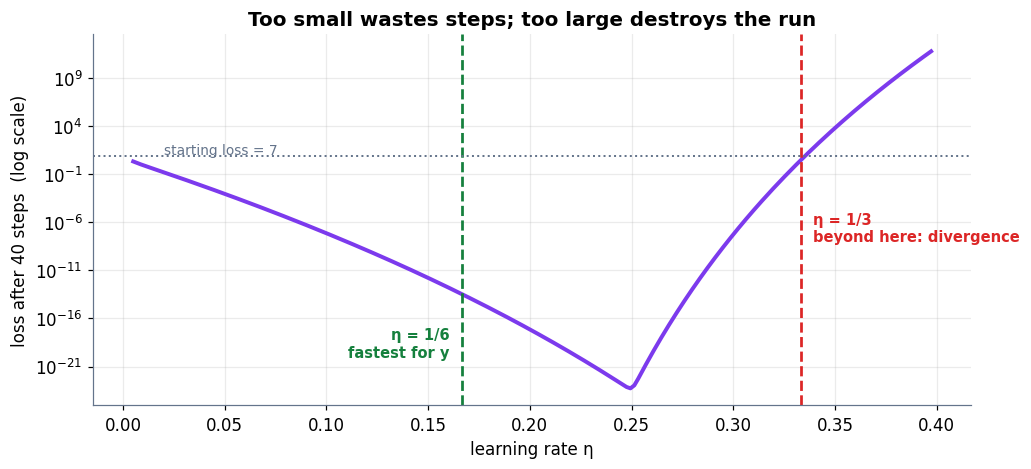

  best η in the sweep      : 0.2495   -> loss 5.406e-24
  η = 0.01 (too timid)     : loss 0.8158   (started at 7)
  η = 0.30 (just inside)   : loss 5.301e-08
  η = 0.34 (just outside)  : loss 6.915e+01


In [15]:
# ============================================================
#  A learning-rate sweep: where the cliff actually is
# ============================================================
def final_loss(eta, steps=40, p0=(2.0, 1.0)):
    p = np.array(p0, dtype=float)
    for _ in range(steps):
        p = p - eta * grad2(p)
        if not np.isfinite(p).all() or np.abs(p).max() > 1e12:
            return np.inf
    return f2(p)

sweep = np.linspace(0.005, 0.42, 220)
finals = np.array([final_loss(e) for e in sweep])

fig, ax = plt.subplots(figsize=(9.6, 4.4))
ok = np.isfinite(finals) & (finals < 1e12)
ax.semilogy(sweep[ok], np.maximum(finals[ok], 1e-30), color=C_MODEL, lw=2.6)
ax.axvline(1 / 3, color=C_ERR, ls="--", lw=1.8)
ax.axvline(1 / 6, color=C_TRUE, ls="--", lw=1.8)
ax.axhline(7, color=C_GREY, ls=":", lw=1.3)
ax.text(1 / 3 + 0.006, 1e-8, "η = 1/3\nbeyond here: divergence", color=C_ERR,
        fontsize=9.6, fontweight="bold")
ax.text(1 / 6 - 0.006, 1e-20, "η = 1/6\nfastest for y", color=C_TRUE,
        fontsize=9.6, fontweight="bold", ha="right")
ax.text(0.02, 12, "starting loss = 7", color=C_GREY, fontsize=9)
tidy(ax, "learning rate η", "loss after 40 steps  (log scale)",
     "Too small wastes steps; too large destroys the run")
plt.tight_layout(); plt.show()

best_e = sweep[np.nanargmin(np.where(np.isfinite(finals), finals, np.inf))]
print(f"  best η in the sweep      : {best_e:.4f}   -> loss {final_loss(best_e):.3e}")
print(f"  η = 0.01 (too timid)     : loss {final_loss(0.01):.4f}   (started at 7)")
print(f"  η = 0.30 (just inside)   : loss {final_loss(0.30):.3e}")
print(f"  η = 0.34 (just outside)  : loss {final_loss(0.34):.3e}")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows


**One figure, the whole learning-rate story.** Horizontal is $\eta$; vertical is the loss remaining after 40 steps, on a log axis, having started from a loss of 7 (grey dotted line).

**Read it left to right.** At the far left, 40 steps take the loss from 7 down to only about 0.8 — every step pointed the right way, but far too short to finish the job. As $\eta$ grows the curve plunges — better step size, dramatically fewer steps needed for the same progress. It bottoms out in a broad basin, then turns around and climbs steeply, and past the red line at $\eta = 1/3$ the run diverges outright.

**What to look for:** the valley is **wide and flat on a log scale**. Anything from roughly 0.05 to 0.30 gets you within a rounding error of the answer in 40 steps. This is why learning-rate tuning works at all in practice — you are hunting for an order of magnitude, not a decimal place.

**Also worth noticing:** the minimum of this curve is *not* at $\eta = 1/6$. That value is optimal for the $y$ coordinate alone (it zeroes $y$ in one step); the $x$ coordinate, with curvature 2 instead of 6, prefers $\eta = 1/2$. With one shared learning rate the best compromise sits between them — which is exactly the tension that adaptive optimisers like Adam exist to resolve.

**The common misread:** treating the cliff edge as the target. Running at 0.32 here is technically stable and genuinely reckless: on real losses the curvature changes as you move, so a rate that is marginally stable at the start can diverge ten thousand steps later.


</div>

<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ✅ Part 3 takeaway


$$ \theta \leftarrow \theta - \eta \nabla L(\theta) $$

Read $\nabla L$, step against it, repeat until the gradient is zero. That is **all** of gradient descent, and every optimiser you will ever meet — SGD, momentum, RMSProp, Adam — is a variation on which gradient you use and how you scale the step.

The gradient gives you a **direction you can trust** and a **distance you cannot**. Losing that distinction is the single most common way a training run fails.

🔗 This is the **UPDATE** box from `foundations_1_the_learning_machine.ipynb`, now derived rather than asserted. What is still missing: in a real network nobody can write `grad()` by hand. That is Part 4.


</div>

# Part 4 · The Chain Rule — Reaching a Weight Far From the Loss ⭐⭐⭐

<div style="background: linear-gradient(135deg, #fc466b 0%, #3f5efb 100%); padding: 28px; border-radius: 18px; color: white; margin: 12px 0;">


### A neural network is a function inside a function inside a function, ninety layers deep.

Training it means answering one question, millions of times per second:

> *If I nudge **this one weight**, buried in layer three, how much does the **final loss** change?*

That sounds impossible. The weight is separated from the loss by dozens of matrix multiplies and nonlinearities; there is no formula connecting them directly. And yet a single rule from first-year calculus answers it **exactly**, and answers it **cheaply**.

That rule is the **chain rule**. The algorithm that applies it layer by layer is **backpropagation**. Part 4 builds the rule; Part 5 builds the algorithm.


</div>

## 4.1 The Puzzle, Stated Precisely

Suppose the loss $L$ depends on a prediction $y$, which depends on a hidden value $h$, which depends on a weight $w$:

$$ w \;\longrightarrow\; h \;\longrightarrow\; y \;\longrightarrow\; L $$

We want $\dfrac{dL}{dw}$ — the sensitivity of the loss to that weight. We have **no formula** that connects them directly. What we do have is every individual link:

- how $h$ responds to $w$ — that is $\dfrac{dh}{dw}$
- how $y$ responds to $h$ — that is $\dfrac{dy}{dh}$
- how $L$ responds to $y$ — that is $\dfrac{dL}{dy}$

Each of those is easy: one small function, one derivative rule from Part 1. The question is how to **glue local slopes into a global slope.**

### 📐 The glue

$$ \boxed{\;\frac{dL}{dw} \;=\; \frac{dL}{dy} \cdot \frac{dy}{dh} \cdot \frac{dh}{dw}\;} $$

You multiply the local derivatives along the chain. That is the whole rule.

<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🧠 Why it looks like fractions cancelling — and why that is allowed

Written in Leibniz notation the $dy$'s and $dh$'s appear to cancel like fractions:

$$ \frac{dL}{\cancel{dy}} \cdot \frac{\cancel{dy}}{\cancel{dh}} \cdot \frac{\cancel{dh}}{dw} = \frac{dL}{dw} $$

These are **limits, not fractions**, so strictly that cancellation is not the proof. But it is not a lie either: the cancellation is a genuine, provable consequence of the limit definition. Multiply the difference quotients $\frac{\Delta L}{\Delta y}\cdot\frac{\Delta y}{\Delta h}\cdot\frac{\Delta h}{\Delta w}$ — where the cancellation is plain ordinary arithmetic — and then take the limit of the product.

This is one of the rare cases where the sloppy intuition and the rigorous statement agree. Use it.

</div>

Everything that follows in this notebook — every complication in backpropagation, every line of `autograd` — is bookkeeping on top of that one line.


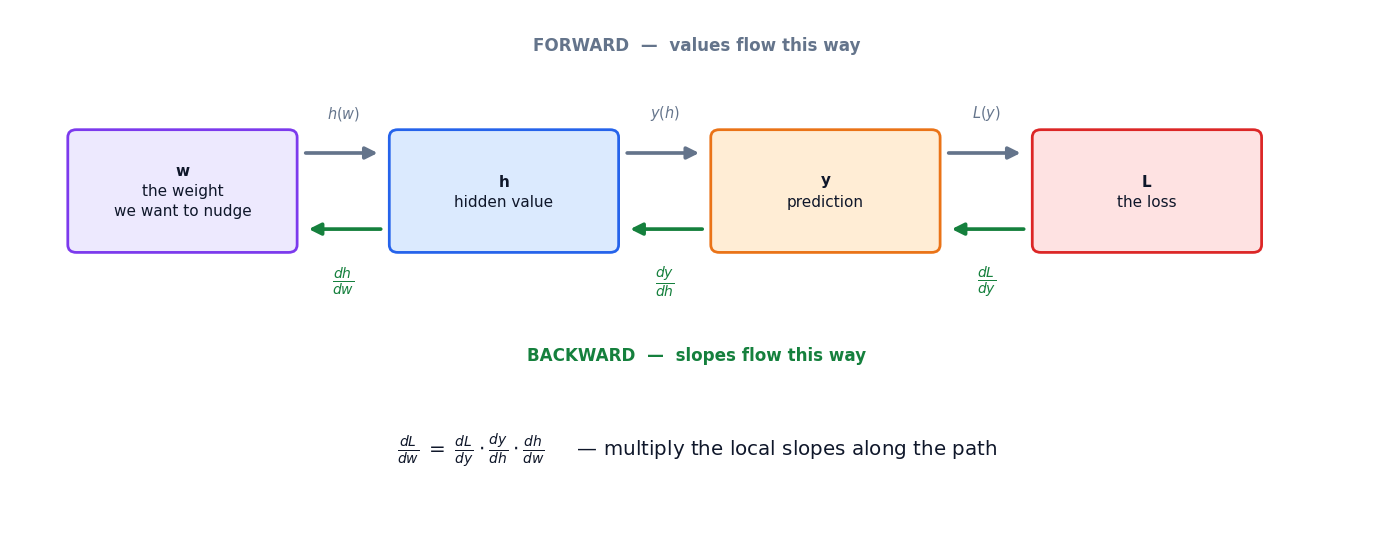

In [16]:
# ============================================================
#  Figure: one hard global derivative = a product of easy local ones
# ============================================================
fig, ax = plt.subplots(figsize=(12.8, 5.0))
stage(ax, (0, 12.8), (0, 5.4))

nodes = [(1.6, "w", "the weight\nwe want to nudge", C_MODEL, "#EDE9FE"),
         (4.6, "h", "hidden value", C_DATA, "#DBEAFE"),
         (7.6, "y", "prediction", C_PRED, "#FFEDD5"),
         (10.6, "L", "the loss", C_ERR, "#FEE2E2")]
for x, name, sub, ec, fc in nodes:
    box(ax, x, 3.5, 2.1, 1.25, f"$\\mathbf{{{name}}}$\n{sub}", fc=fc, ec=ec, fs=10)

# forward arrows
for x0, x1, lab in [(2.65, 3.55, "$h(w)$"), (5.65, 6.55, "$y(h)$"), (8.65, 9.55, "$L(y)$")]:
    arrow(ax, (x0, 3.9), (x1, 3.9), color=C_GREY, lw=2.4, label=lab, label_off=(0, 0.42), fs=9.5)

# backward arrows with the local slopes
for x0, x1, lab in [(9.55, 8.65, r"$\frac{dL}{dy}$"),
                    (6.55, 5.65, r"$\frac{dy}{dh}$"),
                    (3.55, 2.65, r"$\frac{dh}{dw}$")]:
    arrow(ax, (x0, 3.1), (x1, 3.1), color=C_TRUE, lw=2.4, label=lab,
          label_off=(0, -0.55), fs=13)

ax.text(6.4, 4.98, "FORWARD  —  values flow this way",
        ha="center", fontsize=11, color=C_GREY, fontweight="bold")
ax.text(6.4, 1.72, "BACKWARD  —  slopes flow this way",
        ha="center", fontsize=11, color=C_TRUE, fontweight="bold")
ax.text(6.4, 0.72,
        r"$\frac{dL}{dw} \;=\; \frac{dL}{dy}\cdot\frac{dy}{dh}\cdot\frac{dh}{dw}$"
        "     — multiply the local slopes along the path",
        ha="center", fontsize=13, color="#0F172A")
plt.tight_layout(); plt.show()


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows


**Four boxes and two rows of arrows.** The boxes are the values in the computation: the weight $w$ we are allowed to change, the hidden value $h$ it produces, the prediction $y$, and the loss $L$ at the end.

**The grey arrows on top are the forward pass** — the direction actual numbers travel when the model makes a prediction. Each is labelled with the function that does the work.

**The green arrows underneath are the backward pass** — the direction *slopes* travel. Each is labelled with one local derivative, and each is easy: it involves only the single small function on that link, never the whole composition.

**What to look for:** the backward arrows go the *other way*. That is the entire idea. We do not compute $dL/dw$ by pushing something forward from $w$; we start at the loss, where the derivative is trivially known, and drag it backward, multiplying by one local slope per link until we arrive at $w$.

**The common misread:** thinking the chain rule is an approximation, a linearisation that is "good enough for small nudges". It is not. The product of the local derivatives is **exactly** the global derivative — an identity, not an estimate. The next cell checks it against brute force to eight digits.


</div>

## 4.2 ✍️ Napkin Arithmetic on a Two-Link Chain

Abstract rules are hard to internalise, so put real numbers on a tiny composed function:

$$ h = 3w, \qquad y = h^2, \qquad L = y $$

and pick $w = 2$.

**Forward pass** (compute the values, left to right):

$$ h = 3(2) = 6, \qquad y = 6^2 = 36, \qquad L = 36 $$

**The three local slopes** (each one function at a time):

$$ \frac{dh}{dw} = 3, \qquad \frac{dy}{dh} = 2h = 2(6) = 12, \qquad \frac{dL}{dy} = 1 $$

**Multiply along the chain:**

$$ \frac{dL}{dw} = \frac{dL}{dy}\cdot\frac{dy}{dh}\cdot\frac{dh}{dw} = 1 \cdot 12 \cdot 3 = \mathbf{36} $$

So increasing $w$ raises $L$ at a rate of 36 to 1.

**Sanity-check it by brute force.** Nudge $w$ from 2 to 2.001. Then $h = 6.003$, $y = 36.036009$, so $L$ rose by about $0.036$, and $0.036 / 0.001 = 36$. The chain rule and the finite difference agree.

Note the ordering that will matter later: $dy/dh = 2h$ needed the value $h = 6$ **from the forward pass**. The backward pass consumes what the forward pass cached.


In [17]:
# ============================================================
#  The two-link chain: chain rule vs brute force
# ============================================================
def forward(w):
    h = 3 * w
    y = h ** 2
    L = y
    return h, y, L

w0 = 2.0
h0, y0, L0 = forward(w0)
print("FORWARD PASS at w = 2")
print("=" * 56)
print(f"  h = 3w      = {h0:g}")
print(f"  y = h²      = {y0:g}")
print(f"  L = y       = {L0:g}")
print()

dL_dy = 1.0
dy_dh = 2 * h0          # needs h from the forward pass
dh_dw = 3.0
dL_dw = dL_dy * dy_dh * dh_dw

print("BACKWARD PASS — local slopes, multiplied")
print("=" * 56)
print(f"  dL/dy = {dL_dy:g}")
print(f"  dy/dh = 2h = 2·{h0:g} = {dy_dh:g}      <- reuses the cached h")
print(f"  dh/dw = {dh_dw:g}")
print(f"  dL/dw = {dL_dy:g} × {dy_dh:g} × {dh_dw:g} = {dL_dw:g}")
print()

print("BRUTE FORCE — nudge w and watch L")
print("=" * 76)
print(f"{'nudge':>10}{'w+nudge':>12}{'h':>12}{'y = L':>16}{'ΔL/nudge':>16}")
print("-" * 76)
for nudge in [0.001, 1e-5, 1e-7]:
    h1, y1, L1 = forward(w0 + nudge)
    print(f"{nudge:>10.0e}{w0 + nudge:>12.6f}{h1:>12.6f}{y1:>16.9f}"
          f"{(L1 - L0) / nudge:>16.6f}")
print("-" * 76)
h1, y1, L1 = forward(2.001)
print(f"The book's line: w 2 -> 2.001 gives h = {h1:g}, y = {y1:g},")
print(f"  so L rose by {L1 - L0:.6f} and the rate is {(L1 - L0) / 0.001:.4f}.")
print(f"  (Forward differences are biased high by h·f''/2; the book rounds this to 36.)")
print(f"Central difference, the fair test: "
      f"{(forward(w0 + 1e-5)[2] - forward(w0 - 1e-5)[2]) / 2e-5:.9f}")
print(f"Chain rule                       : {dL_dw:.9f}")


FORWARD PASS at w = 2
  h = 3w      = 6
  y = h²      = 36
  L = y       = 36

BACKWARD PASS — local slopes, multiplied
  dL/dy = 1
  dy/dh = 2h = 2·6 = 12      <- reuses the cached h
  dh/dw = 3
  dL/dw = 1 × 12 × 3 = 36

BRUTE FORCE — nudge w and watch L
     nudge     w+nudge           h           y = L        ΔL/nudge
----------------------------------------------------------------------------
     1e-03    2.001000    6.003000    36.036009000       36.009000
     1e-05    2.000010    6.000030    36.000360001       36.000090
     1e-07    2.000000    6.000000    36.000003600       36.000001
----------------------------------------------------------------------------
The book's line: w 2 -> 2.001 gives h = 6.003, y = 36.036,
  so L rose by 0.036009 and the rate is 36.0090.
  (Forward differences are biased high by h·f''/2; the book rounds this to 36.)
Central difference, the fair test: 36.000000001
Chain rule                       : 36.000000000


In [18]:
# ============================================================
#  Same thing, checked symbolically — no numbers involved
# ============================================================
w_s = sp.Symbol("w")
h_s = 3 * w_s
y_s = h_s ** 2
L_s = y_s
print("Composed by hand :  L(w) =", sp.expand(L_s))
print("sympy dL/dw      :", sp.diff(L_s, w_s), " -> at w=2 :",
      float(sp.diff(L_s, w_s).subs(w_s, 2)))
print()
# ... and factored the way the chain rule sees it
hh = sp.Symbol("h"); yy = sp.Symbol("y")
print("link by link     :  dL/dy =", sp.diff(yy, yy),
      " dy/dh =", sp.diff(hh ** 2, hh),
      " dh/dw =", sp.diff(3 * w_s, w_s))
print("product at w = 2 :", 1 * float(sp.diff(hh ** 2, hh).subs(hh, 6)) * 3)
print()
print("Composing first and differentiating, or differentiating each link and")
print("multiplying, give the same number. That equivalence IS the chain rule.")


Composed by hand :  L(w) = 9*w**2
sympy dL/dw      : 18*w  -> at w=2 : 36.0

link by link     :  dL/dy = 1  dy/dh = 2*h  dh/dw = 3
product at w = 2 : 36.0

Composing first and differentiating, or differentiating each link and
multiplying, give the same number. That equivalence IS the chain rule.


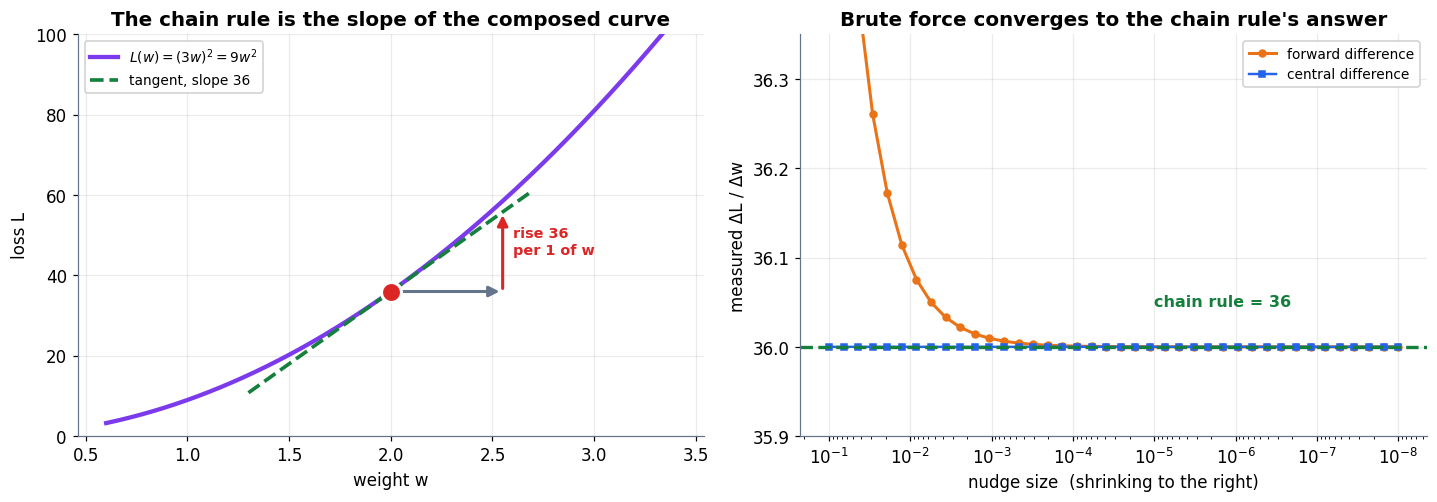

In [19]:
# ============================================================
#  Figure: the chain, the composed curve, and the converging ratio
# ============================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13.2, 4.7))

ws = np.linspace(0.6, 3.4, 300)
ax1.plot(ws, 9 * ws ** 2, color=C_MODEL, lw=2.8, label="$L(w) = (3w)^2 = 9w^2$")
tl = np.linspace(1.3, 2.7, 2)
ax1.plot(tl, L0 + dL_dw * (tl - w0), color=C_TRUE, lw=2.4, ls="--",
         label=f"tangent, slope {dL_dw:.0f}")
ax1.scatter([w0], [L0], s=170, color=C_ERR, zorder=6, edgecolor="white", lw=2)
ax1.annotate("", xy=(2.55, L0), xytext=(w0, L0),
             arrowprops=dict(arrowstyle="-|>", color=C_GREY, lw=2, mutation_scale=14))
ax1.annotate("", xy=(2.55, L0 + dL_dw * 0.55), xytext=(2.55, L0),
             arrowprops=dict(arrowstyle="-|>", color=C_ERR, lw=2, mutation_scale=14))
ax1.text(2.60, L0 + dL_dw * 0.26, "rise 36\nper 1 of w", color=C_ERR, fontsize=9.4,
         fontweight="bold")
ax1.set_ylim(0, 100)
tidy(ax1, "weight w", "loss L", "The chain rule is the slope of the composed curve",
     legend=True)
ax1.legend(fontsize=9, loc="upper left")

hs_ = np.logspace(-1, -8, 40)
ratios = [(forward(w0 + hh_)[2] - L0) / hh_ for hh_ in hs_]
cent = [(forward(w0 + hh_)[2] - forward(w0 - hh_)[2]) / (2 * hh_) for hh_ in hs_]
ax2.semilogx(hs_, ratios, "o-", color=C_PRED, lw=2.0, ms=4.5, label="forward difference")
ax2.semilogx(hs_, cent, "s-", color=C_DATA, lw=1.6, ms=3.6, label="central difference")
ax2.axhline(dL_dw, color=C_TRUE, ls="--", lw=2.2)
ax2.text(1e-5, dL_dw + 0.045, "chain rule = 36", color=C_TRUE, fontsize=10.5,
         fontweight="bold")
ax2.invert_xaxis()
ax2.set_ylim(35.9, 36.35)
tidy(ax2, "nudge size  (shrinking to the right)", "measured ΔL / Δw",
     "Brute force converges to the chain rule's answer", legend=True)
ax2.legend(fontsize=9)
plt.tight_layout(); plt.show()


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows


**Left — the composed function, drawn.** Horizontal is the weight $w$; vertical is the loss $L$ that comes out the far end of the chain. Composing the links by hand gives $L(w) = (3w)^2 = 9w^2$, the purple curve. The green dashed tangent at $w=2$ has slope **36** — the number the chain rule produced without ever composing anything. The grey and red arrows read that slope off the picture: move 1 to the right, climb 36.

**Right — brute force closing in.** Horizontal is the nudge size, shrinking as you go right; vertical is the measured ratio $\Delta L / \Delta w$. The orange curve is the one-sided nudge the book uses; the blue curve is the two-sided version. Both converge on the green line at 36, but notice they approach it **differently**: the one-sided measurement sits consistently *above* 36 and drifts down, while the two-sided one is essentially on 36 from the start.

**What to look for:** the one-sided bias is why the book's brute-force check reads $36.009$ rather than exactly $36$ when the nudge is $0.001$. That extra $0.009$ is not error in the chain rule — it is error in the *measurement*, and it shrinks in proportion to the nudge.

**The common misread:** concluding that the finite difference is the ground truth and the chain rule an approximation of it. It is the reverse. The chain rule gives the exact tangent slope; the finite difference is the noisy instrument we use to audit it.


</div>

## 4.3 ⚠️ When a Value Fans Out, the Gradients **Add**

A single chain is the easy case. Real networks are not chains, they are **graphs**: one value almost always feeds several places at once. Every neuron sends its output to many neurons in the next layer.

If you nudge that neuron, the loss feels the change through **every one** of those paths — so what is its gradient?

$$ \textbf{When a value fans out, its gradient is the } \textbf{sum} \textbf{ of the gradients coming back along each path.} $$

Not the maximum. Not the average. The sum. This is the multivariable chain rule, and the reason is physical: a small change in the value perturbs every path *simultaneously*, and the perturbations add up at the loss.

### ✍️ Small numbers, so you can check it in your head

Let $u = 2$ be used twice — once as $p = 3u$, once as $q = u^2$ — and let the loss be $L = p + q$.

| | value | $\dfrac{dL}{d(\cdot)}$ | local slope to $u$ | contribution |
|---|---|---|---|---|
| path 1 | $p = 3u = 6$ | $1$ | $dp/du = 3$ | $1 \times 3 = 3$ |
| path 2 | $q = u^2 = 4$ | $1$ | $dq/du = 2u = 4$ | $1 \times 4 = 4$ |
| | | | | $\Sigma = \mathbf{7}$ |

$$ \frac{dL}{du} = 1\cdot 3 \;+\; 1\cdot 4 \;=\; 7 $$

If you had followed only one branch you would have reported 3 or 4 — and been wrong. Brute force settles it: nudge $u$ from 2 to 2.001 and $L$ moves from 10 to about 10.007.


In [20]:
# ============================================================
#  Fan-out: the gradient is the SUM over paths
# ============================================================
def fan(u):
    p = 3 * u
    q = u ** 2
    return p, q, p + q

u0 = 2.0
p0, q0, Lf0 = fan(u0)
print(f"u = {u0:g}   ->   p = 3u = {p0:g},  q = u² = {q0:g},  L = p + q = {Lf0:g}")
print()
print("Path 1:  dL/dp × dp/du = 1 × 3      = 3")
print(f"Path 2:  dL/dq × dq/du = 1 × 2u = 1 × {2*u0:g}  = {2*u0:g}")
print(f"SUM   :  dL/du                     = {3 + 2*u0:g}      <- the correct answer")
print(f"(max would say {max(3, 2*u0):g}; mean would say {(3 + 2*u0)/2:g}; both are wrong)")
print()

print("BRUTE FORCE")
print("=" * 62)
print(f"{'nudge':>10}{'L(u+nudge)':>20}{'ΔL/nudge':>16}")
print("-" * 62)
for nudge in [0.001, 1e-5, 1e-7]:
    print(f"{nudge:>10.0e}{fan(u0 + nudge)[2]:>20.9f}{(fan(u0 + nudge)[2] - Lf0) / nudge:>16.6f}")
print("-" * 62)
print(f"L(2.001) = {fan(2.001)[2]:.9f}")
print("  The book prints 10.007002 for this value.")
print(f"  We compute {fan(2.001)[2]:.9f}  (3·2.001 = 6.003 exactly, 2.001² = 4.004001 exactly,")
print("  and 6.003 + 4.004001 = 10.007001). The book's final digit looks like a typo;")
print("  the rate it concludes — about 7 — is right either way.")
print()
u_s = sp.Symbol("u")
print("sympy, for certainty:  d/du (3u + u²) =", sp.diff(3 * u_s + u_s ** 2, u_s),
      "-> at u=2 :", float(sp.diff(3 * u_s + u_s ** 2, u_s).subs(u_s, 2)))


u = 2   ->   p = 3u = 6,  q = u² = 4,  L = p + q = 10

Path 1:  dL/dp × dp/du = 1 × 3      = 3
Path 2:  dL/dq × dq/du = 1 × 2u = 1 × 4  = 4
SUM   :  dL/du                     = 7      <- the correct answer
(max would say 4; mean would say 3.5; both are wrong)

BRUTE FORCE
     nudge          L(u+nudge)        ΔL/nudge
--------------------------------------------------------------
     1e-03        10.007001000        7.001000
     1e-05        10.000070000        7.000010
     1e-07        10.000000700        7.000000
--------------------------------------------------------------
L(2.001) = 10.007001000
  The book prints 10.007002 for this value.
  We compute 10.007001000  (3·2.001 = 6.003 exactly, 2.001² = 4.004001 exactly,
  and 6.003 + 4.004001 = 10.007001). The book's final digit looks like a typo;
  the rate it concludes — about 7 — is right either way.

sympy, for certainty:  d/du (3u + u²) = 2*u + 3 -> at u=2 : 7.0


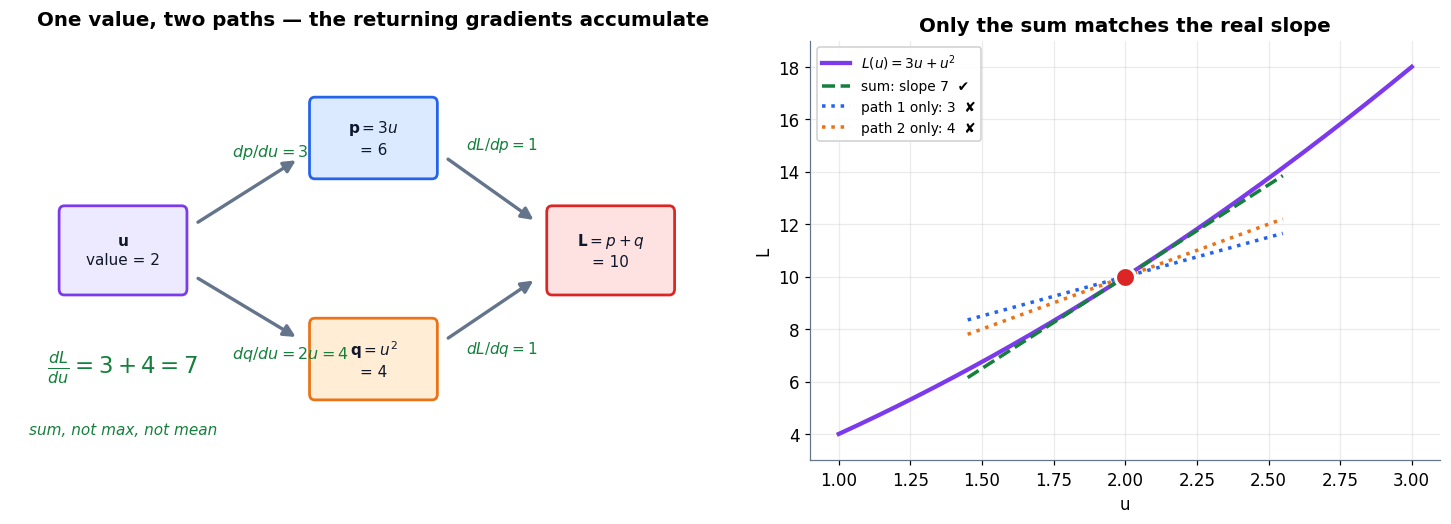

In [21]:
# ============================================================
#  Figure: two paths back into one node
# ============================================================
fig = plt.figure(figsize=(13.4, 4.9))
gs = fig.add_gridspec(1, 2, width_ratios=[1.15, 1])

ax = fig.add_subplot(gs[0])
stage(ax, (0, 11), (0, 5.6))
box(ax, 1.7, 2.8, 1.9, 1.15, "$\\mathbf{u}$\nvalue = 2", fc="#EDE9FE", ec=C_MODEL, fs=10)
box(ax, 5.5, 4.3, 1.9, 1.05, "$\\mathbf{p} = 3u$\n= 6", fc="#DBEAFE", ec=C_DATA, fs=10)
box(ax, 5.5, 1.35, 1.9, 1.05, "$\\mathbf{q} = u^2$\n= 4", fc="#FFEDD5", ec=C_PRED, fs=10)
box(ax, 9.1, 2.8, 1.9, 1.15, "$\\mathbf{L} = p+q$\n= 10", fc="#FEE2E2", ec=C_ERR, fs=10)

arrow(ax, (2.7, 3.1), (4.5, 4.1), color=C_GREY, lw=2.2)
arrow(ax, (2.7, 2.5), (4.5, 1.55), color=C_GREY, lw=2.2)
arrow(ax, (6.5, 4.1), (8.1, 3.1), color=C_GREY, lw=2.2)
arrow(ax, (6.5, 1.55), (8.1, 2.5), color=C_GREY, lw=2.2)

ax.text(3.35, 4.06, "$dp/du = 3$", fontsize=10.5, color=C_TRUE, fontweight="bold")
ax.text(3.35, 1.36, "$dq/du = 2u = 4$", fontsize=10.5, color=C_TRUE, fontweight="bold")
ax.text(6.9, 4.15, "$dL/dp = 1$", fontsize=10, color=C_TRUE)
ax.text(6.9, 1.42, "$dL/dq = 1$", fontsize=10, color=C_TRUE)
ax.text(1.7, 1.15, "$\\frac{dL}{du} = 3 + 4 = 7$", ha="center", fontsize=15,
        color=C_TRUE, fontweight="bold")
ax.text(1.7, 0.35, "sum, not max, not mean", ha="center", fontsize=10,
        color=C_TRUE, style="italic")
ax.set_title("One value, two paths — the returning gradients accumulate", pad=10)

ax2 = fig.add_subplot(gs[1])
us = np.linspace(1.0, 3.0, 300)
ax2.plot(us, 3 * us + us ** 2, color=C_MODEL, lw=2.8, label="$L(u) = 3u + u^2$")
seg = np.linspace(1.45, 2.55, 2)
for slope, col, lab in [(7.0, C_TRUE, "sum: slope 7  ✔"),
                        (3.0, C_DATA, "path 1 only: 3  ✘"),
                        (4.0, C_PRED, "path 2 only: 4  ✘")]:
    ax2.plot(seg, Lf0 + slope * (seg - u0), color=col, lw=2.3,
             ls="--" if slope == 7 else ":", label=lab)
ax2.scatter([u0], [Lf0], s=170, color=C_ERR, zorder=6, edgecolor="white", lw=2)
ax2.set_ylim(3, 19)
tidy(ax2, "u", "L", "Only the sum matches the real slope", legend=True)
ax2.legend(fontsize=9, loc="upper left")
plt.tight_layout(); plt.show()


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows


**Left — the computation as a graph.** $u$ sits on the left with value 2. It fans out along two paths: the top one triples it into $p$, the bottom one squares it into $q$, and the loss adds them. Green labels on the arrows are the local slopes. Each path returns a gradient to $u$ — 3 from the top, 4 from the bottom — and $u$'s true gradient is what you get by **adding them**, not by picking one.

**Right — the proof, geometrically.** Horizontal is $u$, vertical is the actual composed loss $L(u) = 3u + u^2$. Three candidate tangents are drawn at $u = 2$: the dotted blue line of slope 3 (path 1 alone), the dotted orange line of slope 4 (path 2 alone), and the dashed green line of slope 7 (the sum). Only the green line is genuinely tangent to the curve — the other two visibly cut across it.

**What to look for:** the two wrong lines are both *too shallow*. Following a single path always **underestimates** the gradient of a fanned-out value, because you have thrown away real influence. In a deep network, where a neuron may feed hundreds of downstream units, that undercount would be catastrophic.

**The common misread:** treating the sum as double-counting. It is not: the two paths are different routes by which one nudge reaches the loss, and their effects genuinely both happen. Averaging them would mean claiming that a nudge to $u$ somehow only half-affects each branch.


</div>

<div style="background-color: #f8d7da; border-left: 5px solid #dc3545; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ This is the single most common backprop bug you will write

In code, a fan-out means a node's gradient must be **accumulated** — `grad += ...` — not assigned — `grad = ...`.

Every framework does this for you: `torch` initialises `.grad` to zero and *adds* into it, which is exactly why you must call `optimizer.zero_grad()` each iteration. That call is not ceremony; it is you clearing an accumulator whose accumulating behaviour is required by the multivariable chain rule you just proved.

Forget it and your gradients silently sum across iterations — the same bug as a fan-out you forgot to add, wearing a different hat.

</div>

## 4.4 From a Chain to a Neuron

A real neuron is that same chain, with specific links. It computes a weighted sum, then squashes it through a nonlinear **activation** $\varphi$:

$$ z = w \cdot x + b, \qquad a = \varphi(z), \qquad L = \text{(whatever loss sits on top)} $$

To update $w$ we want $dL/dw$, and the chain rule gives three links again:

$$ \frac{dL}{dw} \;=\; \underbrace{\frac{dL}{da}}_{\text{from above}} \cdot \underbrace{\frac{da}{dz}}_{=\,\varphi'(z)} \cdot \underbrace{\frac{dz}{dw}}_{=\,x} $$

Read it **right to left**, which is how backpropagation actually runs:

1. $\dfrac{dz}{dw} = x$ — the pre-activation's slope with respect to the weight is just the input. (Cached from the forward pass.)
2. $\dfrac{da}{dz} = \varphi'(z)$ — the activation's own slope, evaluated at the cached $z$.
3. $\dfrac{dL}{da}$ — comes from whatever sits downstream.

<div style="background-color: #f3e5f5; border-left: 5px solid #9c27b0; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📖 The shape of every gradient in every network

$$ \text{gradient at a weight} \;=\; \underbrace{\text{one number handed down from above}}_{\text{how much the loss cares about this neuron's output}} \;\times\; \underbrace{\text{two purely local slopes}}_{\text{how this neuron transforms its input}} $$

Nothing else is ever needed. A neuron does not need to know what the loss is, how deep the network is, or what happens downstream — only the single number handed to it. Part 5 turns that observation into an algorithm.

</div>

### 📐 Deriving $\sigma'$, properly

The classic activation is the **sigmoid**, $\sigma(z) = \dfrac{1}{1 + e^{-z}}$. Its derivative is famously tidy, and it is worth deriving rather than memorising.

Write it as a power and use the chain rule from §4.2:

$$ \sigma(z) = (1 + e^{-z})^{-1} $$

$$ \sigma'(z) = -1\,(1 + e^{-z})^{-2} \cdot \frac{d}{dz}(1 + e^{-z}) = -(1 + e^{-z})^{-2} \cdot (-e^{-z}) = \frac{e^{-z}}{(1 + e^{-z})^2} $$

Now split that fraction deliberately into two pieces:

$$ \frac{e^{-z}}{(1 + e^{-z})^2} = \underbrace{\frac{1}{1 + e^{-z}}}_{\textstyle \sigma(z)} \cdot \underbrace{\frac{e^{-z}}{1 + e^{-z}}}_{\textstyle 1 - \sigma(z)} $$

The second factor really is $1 - \sigma$: $\;1 - \frac{1}{1+e^{-z}} = \frac{1 + e^{-z} - 1}{1+e^{-z}} = \frac{e^{-z}}{1+e^{-z}}$. Therefore

$$ \boxed{\;\sigma'(z) = \sigma(z)\,\big(1 - \sigma(z)\big)\;} $$

which is delightful in practice: the backward pass gets the activation's derivative **for free** from the value the forward pass already computed. No exponentials twice.


In [22]:
# ============================================================
#  σ'(z) = σ(1−σ) — derived above, now verified three ways
# ============================================================
z_s = sp.Symbol("z")
sig_s = 1 / (1 + sp.exp(-z_s))
dsig_s = sp.diff(sig_s, z_s)

print("sympy raw derivative      :", dsig_s)
print("simplified                :", sp.simplify(dsig_s))
identity = sp.simplify(dsig_s - sig_s * (1 - sig_s))
print("σ'(z) − σ(1−σ) simplifies to:", identity, " -> the identity holds exactly"
      if identity == 0 else " -> MISMATCH")
print()

def sigmoid(z):  return 1 / (1 + np.exp(-z))
def sigmoid_p(z):
    s = sigmoid(z)
    return s * (1 - s)

print(f"{'z':>7}{'σ(z)':>12}{'σ(1−σ)':>14}{'finite diff':>15}{'gap':>12}")
print("-" * 62)
for zv in [-6, -2, -0.5, 0.0, 0.5, 2, 6]:
    fd = (sigmoid(zv + 1e-6) - sigmoid(zv - 1e-6)) / 2e-6
    print(f"{zv:>7.1f}{sigmoid(zv):>12.6f}{sigmoid_p(zv):>14.6f}{fd:>15.6f}"
          f"{abs(sigmoid_p(zv) - fd):>12.2e}")
print("-" * 62)

zs = np.linspace(-12, 12, 20001)
i = np.argmax(sigmoid_p(zs))
print(f"maximum of σ' is {sigmoid_p(zs)[i]:.6f} at z = {zs[i]:.4f}"
      f"   (exactly 1/4 at z = 0, since σ(0) = 1/2)")
print("Remember that ceiling of 0.25. Part 5 measures what it does to a deep stack.")


sympy raw derivative      : exp(-z)/(1 + exp(-z))**2
simplified                : 1/(4*cosh(z/2)**2)
σ'(z) − σ(1−σ) simplifies to: 0  -> the identity holds exactly

      z        σ(z)        σ(1−σ)    finite diff         gap
--------------------------------------------------------------
   -6.0    0.002473      0.002467       0.002467    3.72e-13
   -2.0    0.119203      0.104994       0.104994    5.66e-12
   -0.5    0.377541      0.235004       0.235004    1.70e-11
    0.0    0.500000      0.250000       0.250000    3.49e-11
    0.5    0.622459      0.235004       0.235004    1.07e-11
    2.0    0.880797      0.104994       0.104994    2.21e-11
    6.0    0.997527      0.002467       0.002467    7.23e-11
--------------------------------------------------------------
maximum of σ' is 0.250000 at z = -0.0000   (exactly 1/4 at z = 0, since σ(0) = 1/2)
Remember that ceiling of 0.25. Part 5 measures what it does to a deep stack.


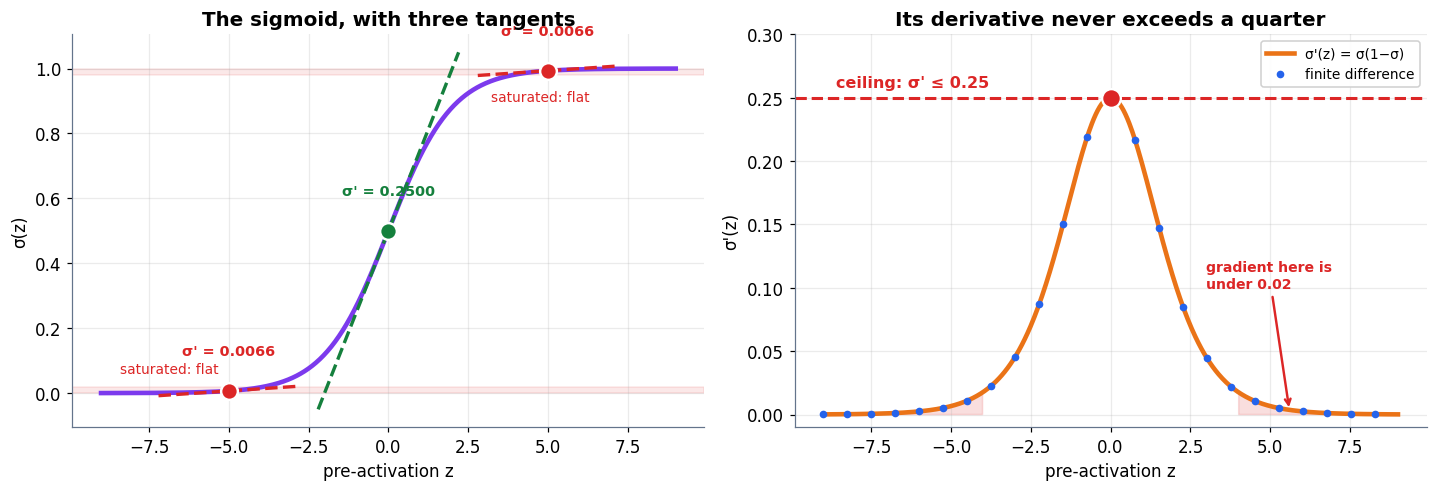

In [23]:
# ============================================================
#  Figure: the sigmoid, its derivative, and the saturation trap
# ============================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13.2, 4.6), sharex=True)

zz = np.linspace(-9, 9, 600)
ax1.plot(zz, sigmoid(zz), color=C_MODEL, lw=3.0)
for zp, col in [(-5.0, C_ERR), (0.0, C_TRUE), (5.0, C_ERR)]:
    s = sigmoid_p(zp)
    seg = np.linspace(zp - 2.2, zp + 2.2, 2)
    ax1.plot(seg, sigmoid(zp) + s * (seg - zp), color=col, lw=2.2, ls="--")
    ax1.scatter([zp], [sigmoid(zp)], s=120, color=col, zorder=6,
                edgecolor="white", lw=1.6)
    ax1.text(zp, sigmoid(zp) + 0.11, f"σ' = {s:.4f}", ha="center", fontsize=9.4,
             color=col, fontweight="bold")
ax1.axhspan(0, 0.02, color=C_ERR, alpha=0.10)
ax1.axhspan(0.98, 1.0, color=C_ERR, alpha=0.10)
ax1.text(-8.4, 0.06, "saturated: flat", color=C_ERR, fontsize=9)
ax1.text(3.2, 0.90, "saturated: flat", color=C_ERR, fontsize=9)
tidy(ax1, "pre-activation z", "σ(z)", "The sigmoid, with three tangents")

ax2.plot(zz, sigmoid_p(zz), color=C_PRED, lw=3.0, label="σ'(z) = σ(1−σ)")
ax2.plot(zz[::25], (sigmoid(zz[::25] + 1e-6) - sigmoid(zz[::25] - 1e-6)) / 2e-6,
         "o", color=C_DATA, ms=4, label="finite difference")
ax2.axhline(0.25, color=C_ERR, ls="--", lw=2.0)
ax2.text(-8.6, 0.258, "ceiling: σ' ≤ 0.25", color=C_ERR, fontsize=10.5,
         fontweight="bold")
ax2.scatter([0], [0.25], s=150, color=C_ERR, zorder=6, edgecolor="white", lw=1.5)
ax2.fill_between(zz, 0, sigmoid_p(zz), where=(np.abs(zz) > 4), color=C_ERR, alpha=0.15)
ax2.annotate("gradient here is\nunder 0.02", xy=(5.6, 0.0033), xytext=(3.0, 0.10),
             fontsize=9.2, color=C_ERR, fontweight="bold",
             arrowprops=dict(arrowstyle="->", color=C_ERR, lw=1.6))
ax2.set_ylim(-0.01, 0.30)
tidy(ax2, "pre-activation z", "σ'(z)", "Its derivative never exceeds a quarter",
     legend=True)
ax2.legend(fontsize=9)
plt.tight_layout(); plt.show()


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows


**Left — the sigmoid with three tangents.** Horizontal is the pre-activation $z$; vertical is $\sigma(z)$, which squashes any real number into $(0, 1)$. Three tangent lines are drawn with their slopes labelled. At $z = 0$ the curve is at its steepest and the slope is $0.25$. At $z = \pm 5$ the curve has flattened out into the shaded **saturation** bands and the slope has collapsed to about $0.0066$.

**Right — that slope, as its own curve.** Horizontal is still $z$; vertical is $\sigma'(z) = \sigma(1-\sigma)$. Blue dots are an independent finite-difference measurement laid on top of the formula, and they land on it exactly — the derivation in the markdown above is confirmed, not assumed. The red ceiling marks the maximum, exactly $1/4$, reached only at $z = 0$.

**What to look for:** the whole curve lives **below 0.25**, and the shaded tails are where almost all of it lives once a network's activations spread out. This is the single most consequential number in Part 5: every layer of sigmoid you stack multiplies the gradient by *at most* a quarter, and typically by far less.

**The common misread:** reading the flat tails of the left panel as harmless — "the neuron has made up its mind". A saturated neuron does not merely stop changing: it stops **transmitting**, because everything upstream of it gets multiplied by a number near zero. One saturated layer can mute every layer behind it.


</div>

In [24]:
# ============================================================
#  A whole neuron's weight gradient — chain rule vs brute force
# ============================================================
# One neuron, squared-error loss on one example.
x_in, y_true = 1.7, 1.0
w_n, b_n = 0.8, -0.3

def neuron_loss(w, b, x=x_in, y=y_true):
    z = w * x + b
    a = sigmoid(z)
    return (a - y) ** 2, z, a

L_n, z_n, a_n = neuron_loss(w_n, b_n)
print("FORWARD  (and cache everything the backward pass will need)")
print("=" * 60)
print(f"  x = {x_in},  w = {w_n},  b = {b_n}")
print(f"  z = w·x + b = {z_n:.6f}      <- cached")
print(f"  a = σ(z)    = {a_n:.6f}      <- cached")
print(f"  L = (a − y)² = {L_n:.6f}")
print()

dL_da = 2 * (a_n - y_true)
da_dz = a_n * (1 - a_n)          # σ'(z), free from the cached a
dz_dw = x_in
dz_db = 1.0
grad_w = dL_da * da_dz * dz_dw
grad_b = dL_da * da_dz * dz_db

print("BACKWARD  (right to left, one link at a time)")
print("=" * 60)
print(f"  dL/da = 2(a − y)      = {dL_da:+.6f}")
print(f"  da/dz = a(1 − a)      = {da_dz:+.6f}     <- reuses cached a, no exp() needed")
print(f"  dz/dw = x             = {dz_dw:+.6f}")
print(f"  dL/dw = product       = {grad_w:+.9f}")
print(f"  dL/db = same, ×1      = {grad_b:+.9f}")
print()

fd_w = (neuron_loss(w_n + 1e-6, b_n)[0] - neuron_loss(w_n - 1e-6, b_n)[0]) / 2e-6
fd_b = (neuron_loss(w_n, b_n + 1e-6)[0] - neuron_loss(w_n, b_n - 1e-6)[0]) / 2e-6
print("CHECK  (finite differences, which know nothing about the chain rule)")
print("=" * 60)
print(f"  dL/dw : chain {grad_w:+.9f}   brute {fd_w:+.9f}   gap {abs(grad_w-fd_w):.2e}")
print(f"  dL/db : chain {grad_b:+.9f}   brute {fd_b:+.9f}   gap {abs(grad_b-fd_b):.2e}")


FORWARD  (and cache everything the backward pass will need)
  x = 1.7,  w = 0.8,  b = -0.3
  z = w·x + b = 1.060000      <- cached
  a = σ(z)    = 0.742691      <- cached
  L = (a − y)² = 0.066208

BACKWARD  (right to left, one link at a time)
  dL/da = 2(a − y)      = -0.514619
  da/dz = a(1 − a)      = +0.191101     <- reuses cached a, no exp() needed
  dz/dw = x             = +1.700000
  dL/dw = product       = -0.167185382
  dL/db = same, ×1      = -0.098344342

CHECK  (finite differences, which know nothing about the chain rule)
  dL/dw : chain -0.167185382   brute -0.167185382   gap 2.26e-11
  dL/db : chain -0.098344342   brute -0.098344342   gap 2.60e-11


<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ✅ Part 4 takeaway


$$ \frac{dL}{dw} = \frac{dL}{dy}\cdot\frac{dy}{dh}\cdot\frac{dh}{dw} $$

**Multiply local slopes along the path; add across paths that fan out.** Those two sentences are the entire chain rule, and every gradient in every network is an instance of them.

Three details that Part 5 will lean on hard:

1. The backward pass **consumes what the forward pass cached** ($h$, $z$, $a$, $x$).
2. A neuron's weight gradient is always *one number from above* × *two local slopes*.
3. $\sigma'(z) = \sigma(1-\sigma) \le 0.25$ — a ceiling that will come back to bite in §5.5.


</div>

# Part 5 · Backpropagation ⭐⭐⭐⭐

<div style="background: linear-gradient(135deg, #fc466b 0%, #3f5efb 100%); padding: 28px; border-radius: 18px; color: white; margin: 12px 0;">


### The chain rule, organised so that nothing is computed twice.

Part 4 gave us the rule. It did not give us an algorithm, and the difference is not academic — it is the difference between training a hundred-billion-parameter model in weeks and never training it at all.

In this part we make the cost argument with a **stopwatch**, define the one quantity that flows backward, write the four-line matrix step, then build a network from scratch, **gradient-check it against brute force**, confirm it against `torch.autograd`, and finally **measure** the vanishing-gradient problem rather than merely warning about it.


</div>

## 5.1 Why One Backward Pass and Not a Million Forward Ones

Imagine a network with a million weights. Here is the obvious, honest, hopeless way to get every gradient:

> For each weight in turn: nudge it, run a **full forward pass**, see how the loss moved, restore it.

That is **one million and one forward passes per training step**. And a training run is hundreds of thousands of steps.

### 📐 Where the saving comes from

Look again at a neuron's weight gradient from §4.4:

$$ \frac{dL}{dw} = \underbrace{\frac{dL}{da}}_{\text{shared}} \cdot \underbrace{\varphi'(z) \cdot x}_{\text{local}} $$

The upstream factor $\dfrac{dL}{da}$ is **shared by every weight feeding into that neuron**. Compute it once, reuse it for all of them — and then push it one step further back so the previous layer can reuse it too.

So the recipe is:

1. **One forward sweep** to compute (and cache) every value.
2. **One backward sweep** to distribute one reusable gradient per node.

The backward pass costs roughly the same as the forward pass — it does the same matrix multiplications, transposed. **Two passes, not a million.** And, remarkably, that cost does not depend on the number of parameters at all: it is the same two passes for a network with a thousand weights and one with a trillion.

Let us not take this on faith. Stopwatch.


  hidden  params P   brute force (s)   backprop (s)   speed-up   max |gap|
       4        17            0.0050       0.000162         31×    1.0e-06
       8        33            0.0075       0.000637         12×    1.0e-06
      16        65            0.0206       0.000370         56×    1.0e-06
      32       129            0.0785       0.001561         50×    1.4e-06
      64       257            0.3396       0.001201        283×    1.0e-06
     128       513            1.1298       0.002192        515×    3.6e-06
Both columns compute the SAME gradient (last column: they agree).
Only one of them has a cost that grows with the parameter count.


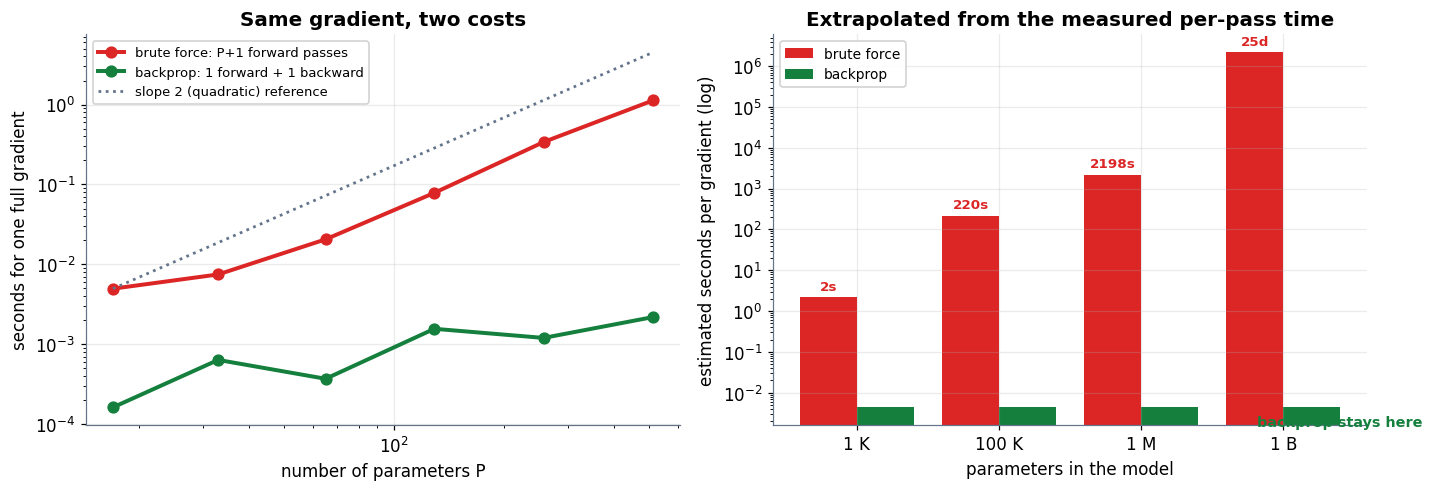

measured cost of ONE forward pass on this machine : 2198.1 µs
a 1,000,000-parameter model, brute force          : 36.6 minutes PER TRAINING STEP
a 1,000,000,000-parameter model, brute force      : 25.4 days PER TRAINING STEP
the same model, backpropagation                   : 4.396 ms per training step
A training run is hundreds of thousands of steps. That is the whole argument.


In [25]:
# ============================================================
#  Measured: brute-force gradients vs one backward pass
# ============================================================
import time

def make_net(n_hidden, rng):
    """A 2 -> n_hidden -> 1 network, weights flattened into one vector."""
    sizes = [(n_hidden, 2), (n_hidden, 1), (1, n_hidden), (1, 1)]
    return np.concatenate([rng.standard_normal(r * c) * 0.5 for r, c in sizes]), sizes

def unpack(theta, sizes):
    out, i = [], 0
    for r, c in sizes:
        out.append(theta[i:i + r * c].reshape(r, c)); i += r * c
    return out

def net_loss(theta, sizes, X, Y):
    """Forward pass only: X is (2, N), Y is (1, N)."""
    W1, b1, W2, b2 = unpack(theta, sizes)
    A1 = np.tanh(W1 @ X + b1)
    A2 = W2 @ A1 + b2
    return float(((A2 - Y) ** 2).mean())

def net_grad_backprop(theta, sizes, X, Y):
    """Forward, cache, then one backward sweep."""
    W1, b1, W2, b2 = unpack(theta, sizes)
    N = X.shape[1]
    Z1 = W1 @ X + b1; A1 = np.tanh(Z1)
    A2 = W2 @ A1 + b2
    d2 = 2 * (A2 - Y) / N                       # dL/dz for the output layer
    gW2, gb2 = d2 @ A1.T, d2.sum(1, keepdims=True)
    d1 = (W2.T @ d2) * (1 - A1 ** 2)            # push back, times tanh'
    gW1, gb1 = d1 @ X.T, d1.sum(1, keepdims=True)
    return np.concatenate([g.ravel() for g in (gW1, gb1, gW2, gb2)])

def net_grad_bruteforce(theta, sizes, X, Y, h=1e-6):
    """The naive way: one full forward pass per parameter."""
    base = net_loss(theta, sizes, X, Y)
    g = np.empty_like(theta)
    for i in range(theta.size):
        t = theta.copy(); t[i] += h
        g[i] = (net_loss(t, sizes, X, Y) - base) / h
    return g

Xd = rng.standard_normal((2, 200))
Yd = np.sin(Xd[0:1] * 1.5) + 0.3 * Xd[1:2]

print(f"{'hidden':>8}{'params P':>10}{'brute force (s)':>18}{'backprop (s)':>15}"
      f"{'speed-up':>11}{'max |gap|':>12}")
print("=" * 76)
timings = []
for nh in [4, 8, 16, 32, 64, 128]:
    th, sizes = make_net(nh, rng)
    t0 = time.perf_counter(); gb = net_grad_bruteforce(th, sizes, Xd, Yd)
    t_brute = time.perf_counter() - t0
    t0 = time.perf_counter()
    for _ in range(20): gp = net_grad_backprop(th, sizes, Xd, Yd)
    t_bp = (time.perf_counter() - t0) / 20
    timings.append((th.size, t_brute, t_bp))
    print(f"{nh:>8}{th.size:>10}{t_brute:>18.4f}{t_bp:>15.6f}"
          f"{t_brute / t_bp:>11.0f}×{np.abs(gb - gp).max():>11.1e}")
print("=" * 76)
print("Both columns compute the SAME gradient (last column: they agree).")
print("Only one of them has a cost that grows with the parameter count.")

# ============================================================
#  Figure: the two cost curves, and where they end up
# ============================================================
P = np.array([t[0] for t in timings], dtype=float)
t_brute = np.array([t[1] for t in timings])
t_bp = np.array([t[2] for t in timings])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13.2, 4.6))

ax1.loglog(P, t_brute, "o-", color=C_ERR, lw=2.6, ms=7, label="brute force: P+1 forward passes")
ax1.loglog(P, t_bp, "o-", color=C_TRUE, lw=2.6, ms=7, label="backprop: 1 forward + 1 backward")
ref = t_brute[0] * (P / P[0]) ** 2
ax1.loglog(P, ref, ls=":", color=C_GREY, lw=1.8, label="slope 2 (quadratic) reference")
tidy(ax1, "number of parameters P", "seconds for one full gradient",
     "Same gradient, two costs", legend=True)
ax1.legend(fontsize=8.6, loc="upper left")

per_forward = t_brute[-1] / (P[-1] + 1)
scales = np.array([1e3, 1e5, 1e6, 1e9])
brute_est = per_forward * (scales + 1)
bp_est = np.full_like(scales, 2 * per_forward)
xpos = np.arange(len(scales))
ax2.bar(xpos - 0.2, brute_est, 0.4, color=C_ERR, label="brute force")
ax2.bar(xpos + 0.2, bp_est, 0.4, color=C_TRUE, label="backprop")
ax2.set_yscale("log")
ax2.set_xticks(xpos)
ax2.set_xticklabels(["1 K", "100 K", "1 M", "1 B"])
for xi, (b, s) in enumerate(zip(brute_est, bp_est)):
    lab = f"{b:.0f}s" if b < 3600 else f"{b/3600:.0f}h" if b < 86400 * 3 else f"{b/86400:.0f}d"
    ax2.text(xi - 0.2, b * 1.5, lab, ha="center", fontsize=8.8, color=C_ERR,
             fontweight="bold")
ax2.text(len(scales) - 0.6, bp_est[0] * 0.35, "backprop stays here", color=C_TRUE,
         fontsize=9.4, fontweight="bold", ha="center")
tidy(ax2, "parameters in the model", "estimated seconds per gradient (log)",
     "Extrapolated from the measured per-pass time", legend=True)
ax2.legend(fontsize=9)
plt.tight_layout(); plt.show()

print(f"measured cost of ONE forward pass on this machine : {per_forward*1e6:.1f} µs")
print(f"a 1,000,000-parameter model, brute force          : "
      f"{per_forward * 1e6 / 60:.1f} minutes PER TRAINING STEP")
print(f"a 1,000,000,000-parameter model, brute force      : "
      f"{per_forward * 1e9 / 86400:.1f} days PER TRAINING STEP")
print(f"the same model, backpropagation                   : "
      f"{2 * per_forward * 1e3:.3f} ms per training step")
print("A training run is hundreds of thousands of steps. That is the whole argument.")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows


**Left — measured, not asserted.** Both axes are logarithmic: horizontal is the number of parameters in the network, vertical is the wall-clock seconds to compute one complete gradient. The red curve is brute force (nudge every weight, one full forward pass each); the green curve is backprop (one forward, one backward). The grey dotted line is a pure quadratic for reference.

**Read the slopes, not the heights.** On log-log axes a straight line's slope is the power law. Red climbs steeply — it pays for every parameter, and each of those passes itself costs more as the network widens, hence roughly quadratic. Green is nearly flat by comparison, and crucially the **gap widens without limit**: this is not a constant-factor speed-up you could engineer around.

**Right — that trend extrapolated**, using the per-forward-pass time actually measured on this machine (the printed numbers below the figure are the ones that count, since they depend on the hardware you are running). At a thousand parameters the naive method is merely wasteful. At a million it is **minutes per training step** — and a run is hundreds of thousands of steps. At a billion it is days per step. The green bars do not move, because two passes is two passes regardless of how many weights those passes touch.

**What to look for:** the last column of the printed table. Both methods return the **same numbers**, agreeing to about $10^{-6}$ — which is the accuracy of the *one-sided* nudge, not of backprop. Backprop is not an approximation that trades accuracy for speed; it is the identical gradient, computed without repeating shared work.

**The common misread:** thinking the saving comes from clever linear algebra or GPU tricks. It comes from *reuse*: the upstream gradient $dL/da$ is shared by everything feeding a neuron, so it is computed once. Removing the repetition is the whole algorithm.


</div>

## 5.2 The Delta That Flows Backward

To turn the chain rule into an algorithm we need to name the thing that gets passed along. Define, at every neuron:

$$ \boxed{\;\delta \;=\; \frac{dL}{dz}\;} $$

the sensitivity of the loss to that neuron's **pre-activation** $z$ (the value *before* the activation function). This is the signal backpropagation moves around, and once a layer knows its $\delta$, two things follow immediately:

1. **The weight gradients are free:** $\dfrac{dL}{dW} = \delta \cdot x^{\top}$ — this layer's delta times this layer's cached input.
2. **The message to the previous layer is nearly free:** push $\delta$ back through the weights, then multiply by the previous layer's activation slope.

### 📐 The four-line backward step

For a layer computing $z = Wx + b$ and $a = \varphi(z)$:

```python
# forward pass cached:  x (the input), z = W @ x + b, a = phi(z)
delta         = grad_from_above * phi_prime(z)   # elementwise -> dL/dz for this layer
grad_W        = delta @ x.T                      # gradient for the weights
grad_b        = delta                            # gradient for the bias
grad_to_below = W.T @ delta                      # the delta handed to the previous layer
```

Four lines. `grad_from_above` arrives from the layer in front; multiply elementwise by the activation's slope to get this layer's `delta`; read off the weight gradient, the bias gradient, and the message to send backward. Chain that loop from the output layer down to the first and **every gradient in the network is computed.**

### 📐 Why the backward pass uses $W^{\top}$

This is the one line people accept without checking, so let us derive it with indices. The forward pass says

$$ z_i = \sum_j W_{ij} x_j \qquad\Longrightarrow\qquad \frac{\partial z_i}{\partial x_j} = W_{ij} $$

Now $x_j$ **fans out**: it feeds every single $z_i$. By the fan-out rule from §4.3, its gradient is the **sum over all those paths**:

$$ \frac{dL}{dx_j} \;=\; \sum_i \frac{dL}{dz_i}\,\frac{\partial z_i}{\partial x_j} \;=\; \sum_i \delta_i\, W_{ij} \;=\; \big(W^{\top}\delta\big)_j $$

That sum-over-$i$-with-$j$-fixed **is** the definition of multiplying by the transpose. The transpose is not a trick to make the shapes fit; it is the fan-out rule written in matrix form. The forward pass uses $W$; the backward pass uses the same weights run in reverse, routing each unit's error back to whatever fed it.


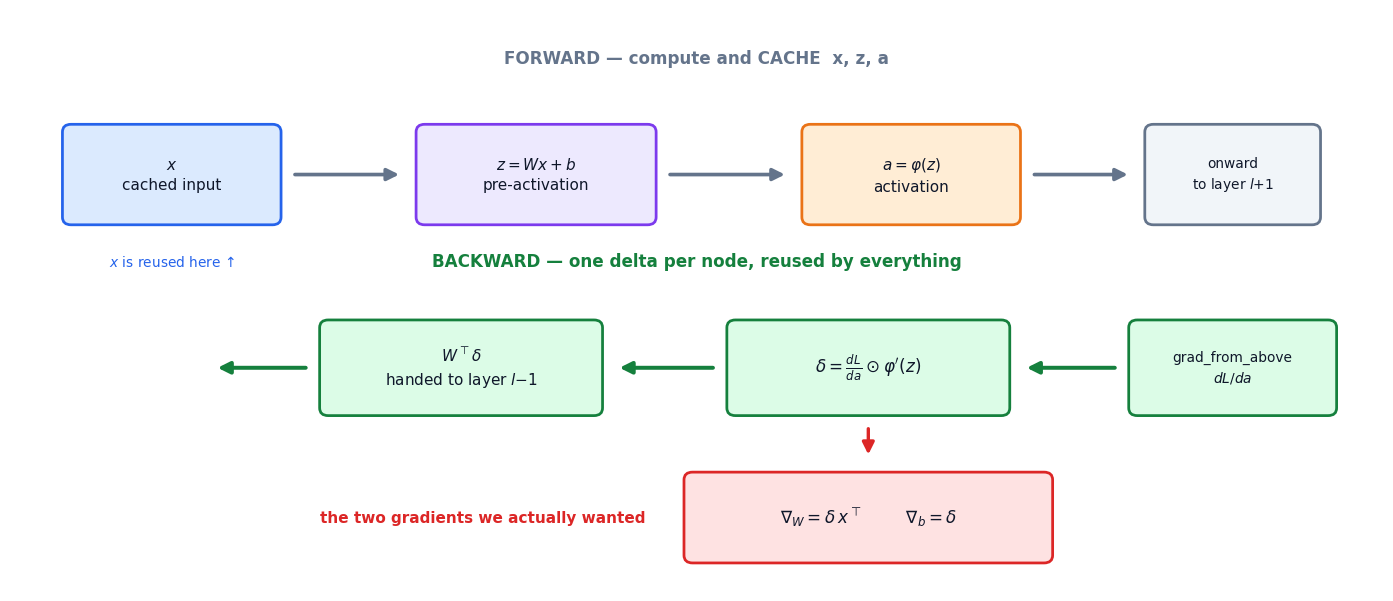

In [26]:
# ============================================================
#  Figure: one layer, forward and backward
# ============================================================
fig, ax = plt.subplots(figsize=(12.8, 5.6))
stage(ax, (0, 12.8), (0, 6.0))

box(ax, 1.5, 4.3, 2.0, 1.0, "$x$\ncached input", fc="#DBEAFE", ec=C_DATA, fs=10)
box(ax, 4.9, 4.3, 2.2, 1.0, "$z = Wx + b$\npre-activation", fc="#EDE9FE", ec=C_MODEL, fs=10)
box(ax, 8.4, 4.3, 2.0, 1.0, "$a = \\varphi(z)$\nactivation", fc="#FFEDD5", ec=C_PRED, fs=10)
box(ax, 11.4, 4.3, 1.6, 1.0, "onward\nto layer $l{+}1$", fc=C_SOFT, ec=C_GREY, fs=9)
arrow(ax, (2.55, 4.3), (3.75, 4.3), color=C_GREY, lw=2.4)
arrow(ax, (6.05, 4.3), (7.35, 4.3), color=C_GREY, lw=2.4)
arrow(ax, (9.45, 4.3), (10.55, 4.3), color=C_GREY, lw=2.4)
ax.text(6.4, 5.45, "FORWARD — compute and CACHE  x, z, a", ha="center",
        fontsize=11, color=C_GREY, fontweight="bold")

box(ax, 11.4, 2.3, 1.9, 0.95, "grad_from_above\n$dL/da$", fc="#DCFCE7", ec=C_TRUE, fs=9)
box(ax, 8.0, 2.3, 2.6, 0.95, "$\\delta = \\frac{dL}{da}\\odot\\varphi'(z)$",
    fc="#DCFCE7", ec=C_TRUE, fs=11)
box(ax, 4.2, 2.3, 2.6, 0.95, "$W^{\\top}\\delta$\nhanded to layer $l{-}1$",
    fc="#DCFCE7", ec=C_TRUE, fs=10)
arrow(ax, (10.4, 2.3), (9.35, 2.3), color=C_TRUE, lw=2.6)
arrow(ax, (6.65, 2.3), (5.55, 2.3), color=C_TRUE, lw=2.6)
arrow(ax, (2.85, 2.3), (1.8, 2.3), color=C_TRUE, lw=2.6)
ax.text(6.4, 3.35, "BACKWARD — one delta per node, reused by everything",
        ha="center", fontsize=11, color=C_TRUE, fontweight="bold")

box(ax, 8.0, 0.75, 3.4, 0.9, "$\\nabla_W = \\delta\\, x^{\\top}$        "
    "$\\nabla_b = \\delta$", fc="#FEE2E2", ec=C_ERR, fs=11)
arrow(ax, (8.0, 1.78), (8.0, 1.26), color=C_ERR, lw=2.2)
ax.text(4.4, 0.75, "the two gradients we actually wanted", fontsize=10,
        color=C_ERR, fontweight="bold", ha="center", va="center")
ax.text(1.5, 3.35, "$x$ is reused here ↑", fontsize=9, color=C_DATA, ha="center")
plt.tight_layout(); plt.show()


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows


**Top row — the forward pass.** The input $x$ arrives, gets multiplied by $W$ and shifted by $b$ into the pre-activation $z$, which is squashed by $\varphi$ into the activation $a$ that goes on to the next layer. The word **CACHE** is the important one: $x$, $z$ and $a$ are all kept, because the backward pass will need them.

**Bottom row — the backward pass, running right to left.** A single number per neuron arrives from in front (`grad_from_above` $= dL/da$). Multiply it elementwise by $\varphi'(z)$ — using the cached $z$ — and you have this layer's $\delta$. Push $\delta$ through $W^{\top}$ and you have the message for the layer behind.

**Bottom box, in red — the payoff.** The weight gradient is $\delta x^{\top}$: this layer's delta against this layer's cached input. Notice that it is *free* once $\delta$ exists, which is why the whole algorithm is organised around computing deltas rather than around computing weight gradients directly.

**What to look for:** the backward row has exactly the same number of boxes as the forward row, and each does one matrix multiply. That symmetry is the cost claim from §5.1 made visible — a backward pass is a forward pass with the arrows and the matrices flipped.

**The common misread:** thinking each weight gets its own backward trip. Nothing in the bottom row is per-weight; it is all per-**neuron**. A layer of 1,000 neurons feeding 1,000 more has a million weights but only a thousand deltas, and those thousand numbers are all the information the million weights need.


</div>

In [27]:
# ============================================================
#  The transpose, verified: is W.T @ delta really dL/dx ?
# ============================================================
rng_local = np.random.default_rng(11)
W = rng_local.standard_normal((4, 3))          # 3 inputs -> 4 outputs
b = rng_local.standard_normal((4, 1))
x = rng_local.standard_normal((3, 1))
c = rng_local.standard_normal((4, 1))          # an arbitrary downstream loss L = c·a

def layer_loss(xv):
    z = W @ xv + b
    a = np.tanh(z)
    return float((c.T @ a).item())

z = W @ x + b
a = np.tanh(z)
delta = c * (1 - a ** 2)                       # dL/da ⊙ φ'(z)
grad_x_formula = W.T @ delta                   # the claim

grad_x_numeric = np.zeros_like(x)
for j in range(x.size):                        # wiggle each input, one at a time
    xp, xm = x.copy(), x.copy()
    xp[j] += 1e-6; xm[j] -= 1e-6
    grad_x_numeric[j] = (layer_loss(xp) - layer_loss(xm)) / 2e-6

print("W is 4x3, so the forward pass maps 3 numbers -> 4 numbers.")
print("The backward pass must map 4 deltas -> 3 gradients, and W.T is 3x4.\n")
print(f"{'j':>4}{'(W.T @ delta)_j':>20}{'measured dL/dx_j':>20}{'gap':>12}")
print("-" * 58)
for j in range(3):
    print(f"{j:>4}{grad_x_formula[j,0]:>20.9f}{grad_x_numeric[j,0]:>20.9f}"
          f"{abs(grad_x_formula[j,0]-grad_x_numeric[j,0]):>12.1e}")
print("-" * 58)
print(f"and the WRONG version, W @ delta, does not even have a valid shape: "
      f"(4,3)@(4,1) -> ", end="")
try:
    _ = W @ delta
    print("it worked?!")
except ValueError as e:
    print("ValueError, as it must.")


W is 4x3, so the forward pass maps 3 numbers -> 4 numbers.
The backward pass must map 4 deltas -> 3 gradients, and W.T is 3x4.

   j     (W.T @ delta)_j    measured dL/dx_j         gap
----------------------------------------------------------
   0        -0.633815112        -0.633815112     5.3e-11
   1         1.324983709         1.324983709     1.3e-12
   2         0.039017546         0.039017546     5.5e-11
----------------------------------------------------------
and the WRONG version, W @ delta, does not even have a valid shape: (4,3)@(4,1) -> ValueError, as it must.


## 5.3 💻 Build It: a Network From Scratch

Enough diagrams. We will now write a small multilayer network in NumPy — forward, backward, and training loop — with nothing imported that knows what a gradient is.

**The problem.** Two interleaved crescents ("moons"), a classic non-linearly-separable toy. A straight line cannot separate them, so a model with no hidden layer is guaranteed to fail; this is the XOR argument from Part 7, with nicer geometry.

**The architecture.** $2 \to 16 \to 16 \to 1$, $\tanh$ in the hidden layers, sigmoid on the output, binary cross-entropy loss.

**The conventions**, which are worth stating because half of all backprop bugs are shape bugs:

| Object | Shape | Meaning |
|---|---|---|
| `A0 = X` | $(2, N)$ | inputs, **one column per example** |
| `W[l]` | $(n_l, n_{l-1})$ | layer $l$'s weights |
| `Z[l] = W[l] @ A[l-1] + b[l]` | $(n_l, N)$ | pre-activations |
| `D[l]` $= \delta$ | $(n_l, N)$ | one delta per neuron **per example** |
| `gW[l] = D[l] @ A[l-1].T` | $(n_l, n_{l-1})$ | summed over examples automatically |

That last row is worth a pause: the matrix product $\delta A^{\top}$ sums over the batch dimension all by itself. The "sum over examples" that ought to be an explicit loop is hiding inside a single `@`.

**One convenient identity.** For a sigmoid output with binary cross-entropy loss, the output layer's delta collapses to something beautiful:

$$ L = -\big[y\log a + (1-y)\log(1-a)\big], \quad a = \sigma(z) \;\;\Longrightarrow\;\; \delta = \frac{dL}{dz} = a - y $$

because the $\sigma(1-\sigma)$ from the activation cancels exactly against the $\frac{1}{a(1-a)}$ from the log-loss. (Notebook 3 derives the same cross-entropy from the likelihood; here it pays us back with the tidiest delta in machine learning.) We verify this cancellation in code rather than trusting it.


In [28]:
# ============================================================
#  First: verify the "δ = a − y" shortcut for sigmoid + BCE
# ============================================================
z_sym, y_sym = sp.symbols("z y")
a_sym = 1 / (1 + sp.exp(-z_sym))
bce = -(y_sym * sp.log(a_sym) + (1 - y_sym) * sp.log(1 - a_sym))
delta_sym = sp.simplify(sp.diff(bce, z_sym))
print("L(z) = BCE(σ(z), y)")
print("dL/dz simplified by sympy :", delta_sym)
print("claimed                   :", sp.simplify(a_sym - y_sym))
print("difference                :", sp.simplify(delta_sym - (a_sym - y_sym)),
      " -> the shortcut is exact")
print()
for zv, yv in [(0.4, 1.0), (-1.3, 0.0), (2.2, 1.0)]:
    num = float(sp.diff(bce, z_sym).subs({z_sym: zv, y_sym: yv}))
    short = 1 / (1 + np.exp(-zv)) - yv
    print(f"  z={zv:>5.1f}, y={yv:g}   sympy dL/dz = {num:+.9f}   a−y = {short:+.9f}")


L(z) = BCE(σ(z), y)
dL/dz simplified by sympy : (-y + (1 - y)*exp(z))/(exp(z) + 1)
claimed                   : (-y*(exp(z) + 1) + exp(z))/(exp(z) + 1)
difference                : 0  -> the shortcut is exact

  z=  0.4, y=1   sympy dL/dz = -0.401312340   a−y = -0.401312340
  z= -1.3, y=0   sympy dL/dz = +0.214165017   a−y = +0.214165017
  z=  2.2, y=1   sympy dL/dz = -0.099750489   a−y = -0.099750489


In [29]:
# ============================================================
#  A neural network, from scratch. No autograd anywhere.
# ============================================================
def make_moons(n_per_class=140, noise=0.18, seed=7):
    """Two interleaved crescents. No sklearn — just trigonometry and noise."""
    r = np.random.default_rng(seed)
    t = np.linspace(0, np.pi, n_per_class)
    x1 = np.stack([np.cos(t), np.sin(t)])                       # upper moon
    x2 = np.stack([1 - np.cos(t), 0.5 - np.sin(t)])             # lower moon
    X = np.concatenate([x1, x2], axis=1) + noise * r.standard_normal((2, 2 * n_per_class))
    Y = np.concatenate([np.zeros(n_per_class), np.ones(n_per_class)]).reshape(1, -1)
    idx = r.permutation(X.shape[1])
    return X[:, idx], Y[:, idx]

class Net:
    """A plain MLP: tanh hidden layers, sigmoid output, binary cross-entropy."""

    def __init__(self, sizes, seed=0):
        r = np.random.default_rng(seed)
        self.sizes = sizes
        # Xavier-ish init for tanh: variance 1/n_in keeps activations sane
        self.W = [r.standard_normal((sizes[i + 1], sizes[i])) * np.sqrt(1.0 / sizes[i])
                  for i in range(len(sizes) - 1)]
        self.b = [np.zeros((sizes[i + 1], 1)) for i in range(len(sizes) - 1)]

    # ---------------- forward: compute and cache ----------------
    def forward(self, X):
        A = [X]; Z = []
        last = len(self.W) - 1
        for l, (W, b) in enumerate(zip(self.W, self.b)):
            z = W @ A[-1] + b
            a = 1 / (1 + np.exp(-z)) if l == last else np.tanh(z)
            Z.append(z); A.append(a)
        return Z, A

    def loss(self, X, Y, eps=1e-12):
        A_out = self.forward(X)[1][-1]
        return float(-(Y * np.log(A_out + eps) + (1 - Y) * np.log(1 - A_out + eps)).mean())

    # ---------------- backward: four lines per layer ----------------
    def backward(self, X, Y):
        Z, A = self.forward(X)
        N = X.shape[1]
        gW = [None] * len(self.W); gb = [None] * len(self.b)

        delta = (A[-1] - Y) / N                       # sigmoid + BCE shortcut
        for l in reversed(range(len(self.W))):
            gW[l] = delta @ A[l].T                    # grad_W = delta @ x.T
            gb[l] = delta.sum(axis=1, keepdims=True)  # grad_b = delta (summed over batch)
            if l > 0:
                below = self.W[l].T @ delta           # grad_to_below = W.T @ delta
                delta = below * (1 - A[l] ** 2)       # times tanh'(z) = 1 − a²
        return gW, gb

    def step(self, X, Y, eta):
        gW, gb = self.backward(X, Y)
        for l in range(len(self.W)):
            self.W[l] -= eta * gW[l]                  # θ ← θ − η∇L
            self.b[l] -= eta * gb[l]

    def predict(self, X):
        return self.forward(X)[1][-1]

X_moon, Y_moon = make_moons()
net = Net([2, 16, 16, 1], seed=3)
print(f"data  : X {X_moon.shape},  Y {Y_moon.shape},  "
      f"class balance {Y_moon.mean():.2f}")
print(f"model : {net.sizes},  "
      f"{sum(w.size for w in net.W) + sum(bb.size for bb in net.b)} parameters")
print(f"loss before training: {net.loss(X_moon, Y_moon):.4f}"
      f"   (a coin flip would score {np.log(2):.4f})")


data  : X (2, 280),  Y (1, 280),  class balance 0.50
model : [2, 16, 16, 1],  337 parameters
loss before training: 0.6943   (a coin flip would score 0.6931)


### ✅ Before training it, prove the gradients are right

This is the single most valuable habit in this notebook. A wrong gradient does not raise an exception — it produces a training run that *looks* plausible and quietly learns the wrong thing, or learns nothing, or learns slowly for reasons you will spend a week hunting.

The test is called a **gradient check**: compare every analytic gradient against a brute-force central difference, and measure the relative error

$$ \text{rel err} = \frac{\|\,g_{\text{backprop}} - g_{\text{numeric}}\,\|}{\|g_{\text{backprop}}\| + \|g_{\text{numeric}}\|} $$

In `float64` a correct implementation lands around $10^{-9}$ or below. Anything above $10^{-5}$ means a real bug; anything around $10^{-2}$ usually means a missing transpose or a forgotten activation derivative.


In [30]:
# ============================================================
#  GRADIENT CHECK — backprop vs brute force, every parameter
# ============================================================
def flatten(net):
    return np.concatenate([w.ravel() for w in net.W] + [bb.ravel() for bb in net.b])

def load(net, theta):
    i = 0
    for l, w in enumerate(net.W):
        net.W[l] = theta[i:i + w.size].reshape(w.shape); i += w.size
    for l, bb in enumerate(net.b):
        net.b[l] = theta[i:i + bb.size].reshape(bb.shape); i += bb.size

check_net = Net([2, 6, 5, 1], seed=1)          # small enough to check EVERY parameter
Xc, Yc = X_moon[:, :40], Y_moon[:, :40]

gW, gb = check_net.backward(Xc, Yc)
g_analytic = np.concatenate([g.ravel() for g in gW] + [g.ravel() for g in gb])

theta0 = flatten(check_net)
g_numeric = np.empty_like(theta0)
h = 1e-6
for i in range(theta0.size):
    tp, tm = theta0.copy(), theta0.copy()
    tp[i] += h; tm[i] -= h
    load(check_net, tp); Lp = check_net.loss(Xc, Yc)
    load(check_net, tm); Lm = check_net.loss(Xc, Yc)
    g_numeric[i] = (Lp - Lm) / (2 * h)
load(check_net, theta0)

rel = (np.linalg.norm(g_analytic - g_numeric)
       / (np.linalg.norm(g_analytic) + np.linalg.norm(g_numeric)))
print(f"parameters checked        : {theta0.size}  (all of them)")
print(f"largest single |gap|      : {np.abs(g_analytic - g_numeric).max():.3e}")
print(f"RELATIVE ERROR            : {rel:.3e}")
print(f"verdict                   : {'PASS — under 1e-7' if rel < 1e-7 else 'FAIL'}")
print()
print(f"{'param':>7}{'backprop':>16}{'brute force':>16}")
print("-" * 40)
for i in [0, 1, 2, theta0.size // 2, theta0.size - 2, theta0.size - 1]:
    print(f"{i:>7}{g_analytic[i]:>16.9f}{g_numeric[i]:>16.9f}")
print("-" * 40)
print("Every one of these came from four lines of matrix algebra, and every one")
print("agrees with physically nudging that weight and re-running the network.")


parameters checked        : 59  (all of them)
largest single |gap|      : 1.154e-10
RELATIVE ERROR            : 4.593e-10
verdict                   : PASS — under 1e-7

  param        backprop     brute force
----------------------------------------
      0    -0.040057431    -0.040057431
      1     0.038636528     0.038636528
      2    -0.007165653    -0.007165654
     29    -0.003441539    -0.003441539
     57    -0.000144543    -0.000144543
     58    -0.028691923    -0.028691923
----------------------------------------
Every one of these came from four lines of matrix algebra, and every one
agrees with physically nudging that weight and re-running the network.


### ✅ And now the third opinion: `torch.autograd`

A finite difference is an independent check, but it is still *our* code. PyTorch's autograd is a completely separate implementation, written by other people, that applies the same chain rule by recording the operations of the forward pass onto a tape and replaying it backward.

If our four lines are right, torch must produce the **same numbers to machine precision** — not close, identical to about $10^{-16}$ in double precision. Note what we are *not* doing: we are not using torch to compute our gradients. We are using it as a referee.


In [31]:
# ============================================================
#  torch.autograd as an independent referee
# ============================================================
import torch
torch.manual_seed(0)

t_net = Net([2, 16, 16, 1], seed=3)            # same seed => same initial weights
Xt = torch.tensor(X_moon, dtype=torch.float64)
Yt = torch.tensor(Y_moon, dtype=torch.float64)
Wt = [torch.tensor(w, dtype=torch.float64, requires_grad=True) for w in t_net.W]
bt = [torch.tensor(bb, dtype=torch.float64, requires_grad=True) for bb in t_net.b]

A = Xt
for l in range(len(Wt)):
    Z = Wt[l] @ A + bt[l]
    A = torch.sigmoid(Z) if l == len(Wt) - 1 else torch.tanh(Z)
loss_t = -(Yt * torch.log(A) + (1 - Yt) * torch.log(1 - A)).mean()
loss_t.backward()

gW_ours, gb_ours = t_net.backward(X_moon, Y_moon)
print(f"loss   ours  {t_net.loss(X_moon, Y_moon):.12f}")
print(f"loss   torch {loss_t.item():.12f}")
print()
print(f"{'layer':>7}{'shape':>12}{'max |ours − torch|':>24}")
print("-" * 46)
worst = 0.0
for l in range(len(Wt)):
    dW = np.abs(gW_ours[l] - Wt[l].grad.numpy()).max()
    db = np.abs(gb_ours[l] - bt[l].grad.numpy()).max()
    worst = max(worst, dW, db)
    print(f"{'W' + str(l):>7}{str(tuple(gW_ours[l].shape)):>12}{dW:>24.3e}")
    print(f"{'b' + str(l):>7}{str(tuple(gb_ours[l].shape)):>12}{db:>24.3e}")
print("-" * 46)
print(f"worst disagreement anywhere : {worst:.3e}")
print("That is floating-point noise. Two independent implementations of the chain")
print("rule — ours in four lines, torch's on a tape — computed the same gradient.")


loss   ours  0.694285668875
loss   torch 0.694285668877

  layer       shape      max |ours − torch|
----------------------------------------------
     W0     (16, 2)               4.163e-17
     b0     (16, 1)               3.469e-18
     W1    (16, 16)               5.551e-17
     b1     (16, 1)               3.469e-18
     W2     (1, 16)               2.776e-17
     b2      (1, 1)               6.939e-18
----------------------------------------------
worst disagreement anywhere : 5.551e-17
That is floating-point noise. Two independent implementations of the chain
rule — ours in four lines, torch's on a tape — computed the same gradient.


In [32]:
# ============================================================
#  Train it. Same four-beat loop as Notebook 1.
# ============================================================
net = Net([2, 16, 16, 1], seed=3)
eta, EPOCHS = 0.6, 4000
hist, snaps = [], {}
for e in range(EPOCHS + 1):
    L = net.loss(X_moon, Y_moon)
    hist.append(L)
    if e in (0, 50, 300, 1200, EPOCHS):
        snaps[e] = ([w.copy() for w in net.W], [bb.copy() for bb in net.b], L)
    net.step(X_moon, Y_moon, eta)              # forward, backward, update

acc = ((net.predict(X_moon) > 0.5) == (Y_moon > 0.5)).mean()
print("TRAINING A NETWORK WITH GRADIENTS WE DERIVED OURSELVES")
print("=" * 58)
print(f"{'epoch':>8}{'loss':>14}")
print("-" * 58)
for e in [0, 50, 300, 1200, EPOCHS]:
    print(f"{e:>8}{hist[e]:>14.6f}")
print("-" * 58)
print(f"training accuracy : {acc * 100:.2f}%")
print(f"loss              : {hist[0]:.4f} -> {hist[-1]:.4f}")
print()
print("No autograd, no framework, no library that knows what a derivative is.")
print("Four lines per layer, run backward, 4000 times.")


TRAINING A NETWORK WITH GRADIENTS WE DERIVED OURSELVES
   epoch          loss
----------------------------------------------------------
       0      0.694286
      50      0.240310
     300      0.027670
    1200      0.007903
    4000      0.001653
----------------------------------------------------------
training accuracy : 100.00%
loss              : 0.6943 -> 0.0017

No autograd, no framework, no library that knows what a derivative is.
Four lines per layer, run backward, 4000 times.


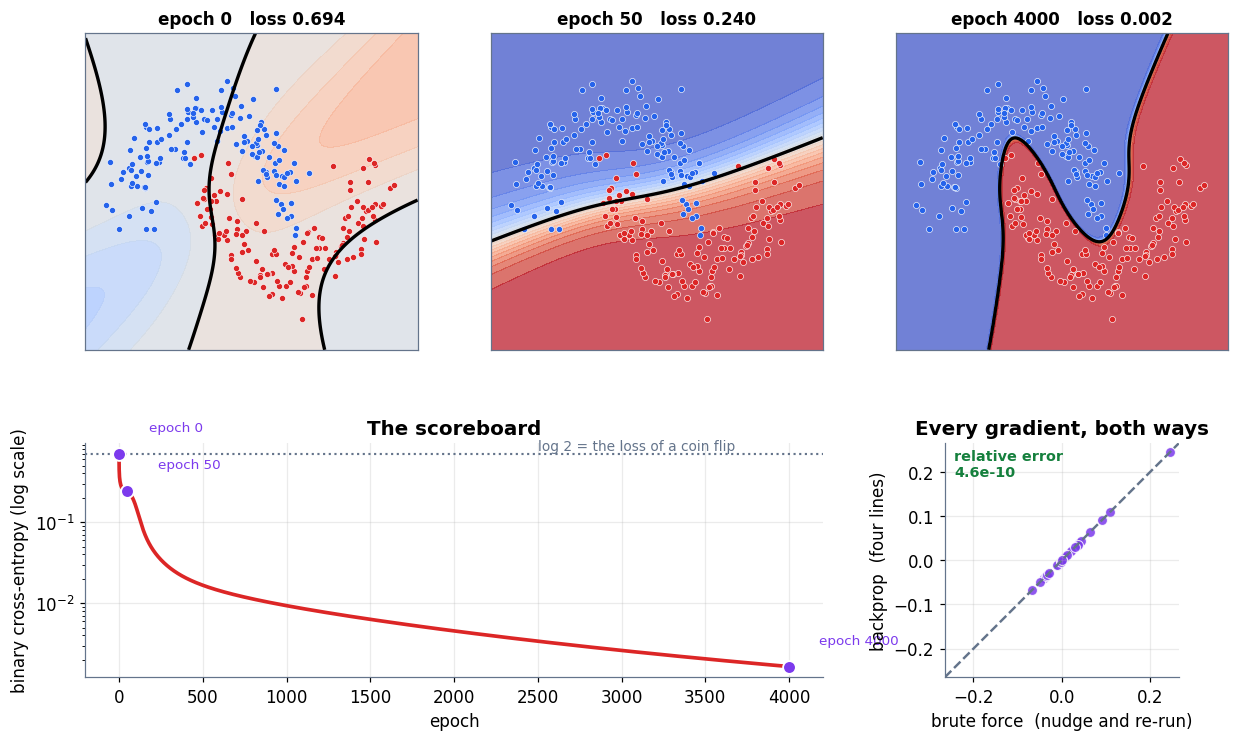

In [33]:
# ============================================================
#  Figure: the boundary being carved, and the loss falling
# ============================================================
fig = plt.figure(figsize=(13.4, 7.6))
gs = fig.add_gridspec(2, 3, height_ratios=[1.15, 0.85], hspace=0.34, wspace=0.22)

gxx, gyy = np.meshgrid(np.linspace(-1.6, 2.6, 220), np.linspace(-1.3, 1.8, 220))
grid = np.stack([gxx.ravel(), gyy.ravel()])
shown = [0, 50, EPOCHS]
for k, e in enumerate(shown):
    ax = fig.add_subplot(gs[0, k])
    Wb, bb_, Le = snaps[e]
    tmp = Net([2, 16, 16, 1]); tmp.W, tmp.b = Wb, bb_
    probs = tmp.predict(grid).reshape(gxx.shape)
    ax.contourf(gxx, gyy, probs, levels=np.linspace(0, 1, 21), cmap="coolwarm", alpha=0.75)
    ax.contour(gxx, gyy, probs, levels=[0.5], colors="k", linewidths=2.2)
    m0 = (Y_moon.ravel() == 0)
    ax.scatter(X_moon[0, m0], X_moon[1, m0], s=16, color=C_DATA, edgecolor="white", lw=0.4)
    ax.scatter(X_moon[0, ~m0], X_moon[1, ~m0], s=16, color=C_ERR, edgecolor="white", lw=0.4)
    ax.set_title(f"epoch {e}   loss {Le:.3f}", fontsize=11)
    ax.set_xticks([]); ax.set_yticks([])

ax4 = fig.add_subplot(gs[1, :2])
ax4.semilogy(hist, color=C_ERR, lw=2.4)
for e in shown:
    ax4.scatter([e], [hist[e]], s=70, color=C_MODEL, zorder=5, edgecolor="white", lw=1.2)
    ax4.annotate(f"epoch {e}", xy=(e, hist[e]), xytext=(e + 180, hist[e] * 1.9),
                 fontsize=8.8, color=C_MODEL)
ax4.axhline(np.log(2), color=C_GREY, ls=":", lw=1.4)
ax4.text(2500, np.log(2) * 1.12, "log 2 = the loss of a coin flip", color=C_GREY, fontsize=9)
tidy(ax4, "epoch", "binary cross-entropy (log scale)", "The scoreboard")

ax5 = fig.add_subplot(gs[1, 2])
lim = 1.08 * max(np.abs(g_analytic).max(), np.abs(g_numeric).max())
ax5.plot([-lim, lim], [-lim, lim], color=C_GREY, lw=1.6, ls="--")
ax5.scatter(g_numeric, g_analytic, s=42, color=C_MODEL, alpha=0.85,
            edgecolor="white", lw=0.7)
ax5.set_xlim(-lim, lim); ax5.set_ylim(-lim, lim); ax5.set_aspect("equal")
ax5.text(-lim * 0.92, lim * 0.72, f"relative error\n{rel:.1e}", fontsize=9.4,
         color=C_TRUE, fontweight="bold")
tidy(ax5, "brute force  (nudge and re-run)", "backprop  (four lines)",
     "Every gradient, both ways")
plt.show()


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows


**Top row — the decision boundary being carved, at three moments.** Both axes are the two input features. Blue and red dots are the two classes; the coloured background is the network's predicted probability, and the black line is the 0.5 contour — the actual decision boundary.

At **epoch 0** the boundary is an almost straight, arbitrary slash: the untrained network is effectively a linear model with random weights, and its loss of about 0.69 is exactly the $\log 2 = 0.693$ a coin flip would score. By **epoch 50** the line has begun to bend — this is the hidden layer earning its existence, since no straight line can separate two interleaved crescents. By the last epoch the boundary curves neatly through the gap between the moons.

**Bottom left — the loss on a log axis.** It plunges to about 0.25 within 25 epochs, then hits a visible **shoulder** near epoch 50 where progress nearly stops, then falls again once the boundary starts to curve, and finally settles into a long slow tail. That stall-then-drop shape is extremely common, and it is one reason "the loss stopped falling" is never on its own a reason to stop training.

**Bottom right — the gradient check, drawn.** Each dot is one parameter: horizontal is the gradient obtained by physically nudging that weight and re-running the whole network, vertical is the gradient our four lines of matrix algebra produced. The dashed line is $y = x$. Every dot is on it, to a relative error of about $10^{-10}$.

**The common misread:** treating that scatter as "close enough". It is not an approximate agreement — at this precision the two methods are computing the same number, and the residual is the finite difference's own truncation error, not ours. A gradient check that lands at $10^{-3}$ instead is not "nearly right"; it is a bug.


</div>

## 5.4 ⚠️ The Caveat: Vanishing and Exploding Gradients

The chain rule is exact. The **numbers it multiplies** are not guaranteed to be well behaved.

A gradient reaching layer 1 of an $N$-layer network is a product of roughly $N$ factors, one per layer. Write the typical magnitude of one factor as $\kappa$:

$$ \|\text{gradient at layer } 1\| \;\sim\; \kappa^{\,N} $$

That is an exponential, and exponentials have exactly two moods:

- $\kappa < 1$: the gradient **vanishes**. Early layers get essentially nothing and stop learning. With $\kappa = 0.25$ and $N = 25$, the factor is $0.25^{25} \approx 10^{-15}$.
- $\kappa > 1$: the gradient **explodes**. Updates overshoot wildly, and the loss goes to `NaN`.

And $\kappa$ has a known ceiling for the sigmoid. From §4.4:

$$ \sigma'(z) \le 0.25 \quad\text{for every } z $$

so **every** sigmoid layer multiplies the returning gradient by at most a quarter, and typically much less because most neurons are not sitting at $z = 0$. Stack enough of them and the gradient is gone before it reaches the first layer.

That is the standard warning. Let us not settle for a warning — let us measure it: push a random gradient vector back through $N$ random layers, record its length at every depth, and take the **median over many trials** so that one unlucky draw cannot fool us.


In [34]:
# ============================================================
#  MEASURED: how a gradient's size changes with depth
# ============================================================
def backward_norms(act, gain, depth=25, width=64, trials=120, seed=0):
    """Push a unit gradient back through `depth` random layers; return median ‖g‖."""
    r = np.random.default_rng(seed)
    allnorms = []
    for _ in range(trials):
        a = r.standard_normal(width) / np.sqrt(width)
        Zs, Ws = [], []
        for _ in range(depth):                                   # forward, cache z
            W = r.standard_normal((width, width)) * np.sqrt(gain / width)
            z = W @ a
            Ws.append(W); Zs.append(z)
            a = sigmoid(z) if act == "sigmoid" else np.maximum(z, 0.0)
        g = r.standard_normal(width); g /= np.linalg.norm(g)     # unit gradient at the top
        norms = [1.0]
        for l in range(depth - 1, -1, -1):                       # the four-line step
            phi_p = sigmoid_p(Zs[l]) if act == "sigmoid" else (Zs[l] > 0).astype(float)
            g = Ws[l].T @ (g * phi_p)
            norms.append(np.linalg.norm(g))
        allnorms.append(norms)
    return np.median(np.array(allnorms), axis=0)

configs = [("sigmoid, standard init (gain 1)", "sigmoid", 1.0, C_ERR),
           ("sigmoid, cranked up (gain 8)",    "sigmoid", 8.0, C_PRED),
           ("sigmoid, absurd init (gain 128)", "sigmoid", 128.0, "#0891B2"),
           ("ReLU + He init (gain 2)",         "relu",    2.0, C_TRUE),
           ("ReLU, init too large (gain 8)",   "relu",    8.0, C_MODEL)]

print("Median ‖gradient‖ after travelling back through N layers (width 64, 120 trials)")
print("=" * 92)
print(f"{'configuration':<34}{'N=5':>13}{'N=15':>13}{'N=25':>13}{'per-layer factor':>18}")
print("-" * 92)
curves = []
for label, act, gain, col in configs:
    n = backward_norms(act, gain)
    curves.append((label, n, col))
    print(f"{label:<34}{n[5]:>13.3e}{n[15]:>13.3e}{n[25]:>13.3e}"
          f"{n[25] ** (1 / 25):>18.4f}")
print("-" * 92)
print("A per-layer factor below 1 vanishes; above 1 explodes.")
print("ReLU+He sits just under 1 BY DESIGN. Sigmoid can be forced above 1, but only")
print("with an absurd initialisation -- in practice it fails by vanishing first.")
print(f"For reference, 0.25**25 = {0.25**25:.3e}  (the sigmoid's best possible case).")


Median ‖gradient‖ after travelling back through N layers (width 64, 120 trials)
configuration                               N=5         N=15         N=25  per-layer factor
--------------------------------------------------------------------------------------------
sigmoid, standard init (gain 1)       6.887e-04    3.485e-10    1.749e-16            0.2343
sigmoid, cranked up (gain 8)          3.567e-02    4.521e-05    6.854e-08            0.5169
sigmoid, absurd init (gain 128)       9.525e-01    9.553e-01    2.061e+00            1.0293
ReLU + He init (gain 2)               8.845e-01    7.508e-01    5.659e-01            0.9775
ReLU, init too large (gain 8)         2.830e+01    2.460e+04    1.899e+07            1.9550
--------------------------------------------------------------------------------------------
A per-layer factor below 1 vanishes; above 1 explodes.
ReLU+He sits just under 1 BY DESIGN. Sigmoid can be forced above 1, but only
with an absurd initialisation -- in practice it fa

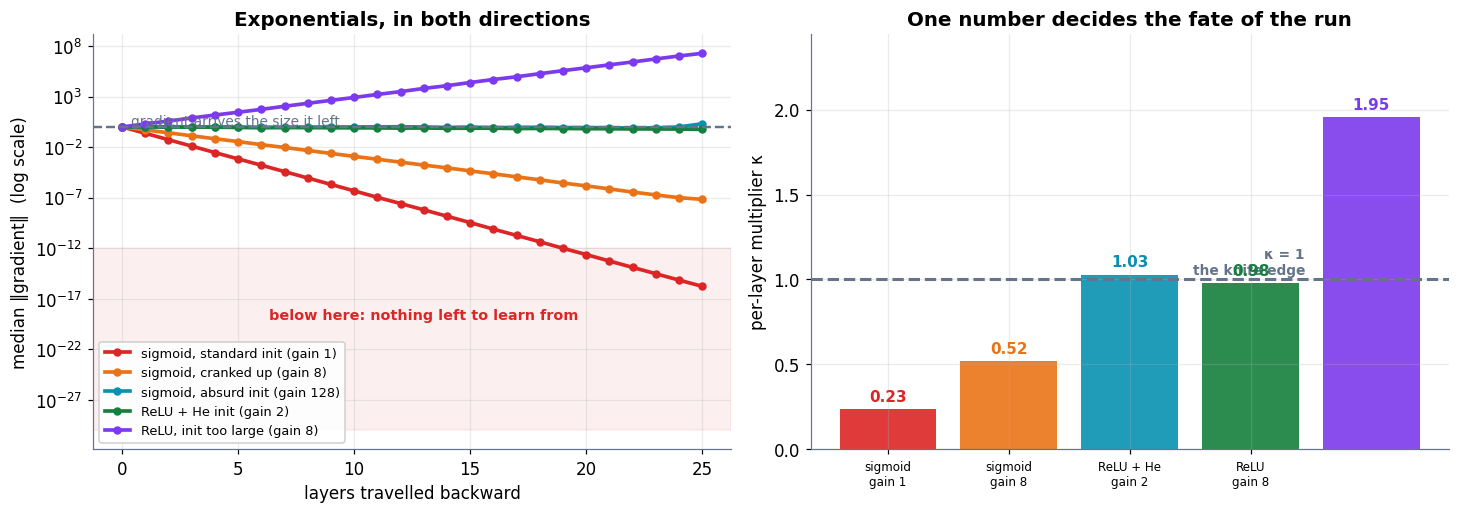

In [35]:
# ============================================================
#  Figure: four ways a gradient can travel 25 layers
# ============================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13.4, 4.8))

for label, n, col in curves:
    ax1.semilogy(range(len(n)), np.maximum(n, 1e-30), "o-", color=col, lw=2.4,
                 ms=4.5, label=label)
ax1.axhline(1.0, color=C_GREY, ls="--", lw=1.6)
ax1.text(0.4, 1.6, "gradient arrives the size it left", color=C_GREY, fontsize=9)
ax1.axhspan(1e-30, 1e-12, color=C_ERR, alpha=0.07)
ax1.text(13, 1e-19, "below here: nothing left to learn from", color=C_ERR,
         fontsize=9.4, fontweight="bold", ha="center")
tidy(ax1, "layers travelled backward", "median ‖gradient‖  (log scale)",
     "Exponentials, in both directions", legend=True)
ax1.legend(fontsize=8.4, loc="lower left")

names = ["sigmoid\ngain 1", "sigmoid\ngain 8", "ReLU + He\ngain 2", "ReLU\ngain 8"]
factors = [c[1][25] ** (1 / 25) for c in curves]
cols = [c[2] for c in curves]
ax2.bar(range(len(factors)), factors, color=cols, alpha=0.9)
ax2.axhline(1.0, color=C_GREY, ls="--", lw=2.0)
ax2.text(len(names) - 0.55, 1.03, "κ = 1\nthe knife edge", color=C_GREY, fontsize=9,
         ha="right", fontweight="bold")
for i, f_ in enumerate(factors):
    ax2.text(i, f_ + 0.05, f"{f_:.2f}", ha="center", fontsize=10, fontweight="bold",
             color=cols[i])
ax2.set_xticks(range(len(names))); ax2.set_xticklabels(names, fontsize=7.8)
ax2.set_ylim(0, max(factors) * 1.25)
tidy(ax2, "", "per-layer multiplier κ", "One number decides the fate of the run")
plt.tight_layout(); plt.show()


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows


**Left — the same experiment run four ways.** Horizontal is how many layers the gradient has travelled backward, from the loss at 0 to the first layer at 25. Vertical is the median length of the gradient vector, on a log scale, starting from 1. Straight lines on a log axis mean **exponential** behaviour, and all four are straight.

**Red — sigmoid with standard initialisation.** It falls off a cliff: after 25 layers the gradient is around $10^{-16}$, which in `float32` is indistinguishable from zero. The early layers of such a network do not learn slowly; they do not learn.

**Orange — sigmoid with the weights cranked up eight-fold**, the obvious attempted fix. It helps, and it is nowhere near enough: still a per-layer factor around 0.5, still fifteen orders of magnitude gone. The reason it helps so little is that the activation fights back — big weights drive $z$ into the flat tails of the sigmoid, where $\sigma'$ collapses toward zero, so most of the gain you add to the matrix is taken straight back.

**Teal — sigmoid with an absurd gain of 128**, included precisely so we do not overclaim. Saturation fights back, but it does *not* win: push the weights hard enough (about sixteen times the standard deviation of the standard initialisation) and $\kappa$ does cross 1, and a sigmoid network explodes like any other. The honest statement is not "sigmoid cannot explode" — it is that **sigmoid networks fail by vanishing long before they get anywhere near the exploding regime**, which is why vanishing is the failure you actually meet.

**Green — ReLU with He initialisation** ($\text{variance} = 2/n$). Nearly horizontal, with a per-layer factor of about 0.98. The gradient arrives at layer 1 roughly the size it left. This is not luck: ReLU's derivative is exactly 1 wherever it is on, and the factor 2 in He initialisation is chosen precisely to compensate for the half of the units it switches off.

**Purple — ReLU with too-large weights.** The mirror-image failure: a factor near 2, so the gradient grows by seven orders of magnitude on the way back, and the first update blows the model apart.

**Right — the whole story as one number per configuration.** The per-layer multiplier $\kappa$, with the knife edge at 1 marked. Anything below shrinks exponentially, anything above grows exponentially, and only one configuration is close to the line.

**The common misread:** treating vanishing gradients as a problem of *depth*. Depth is only the exponent. The base is set by your activation function and your initialisation, and those are the things you actually control.


</div>

<div style="background-color: #f3e5f5; border-left: 5px solid #9c27b0; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📖 What the field did about it

Every mainstream fix is an attempt to drag $\kappa$ back to 1:

| Fix | What it does to $\kappa$ |
|---|---|
| **ReLU** and friends | derivative is exactly 1 where the unit is on, instead of $\le 0.25$ |
| **He / Xavier initialisation** | sets the weight variance so the matrix factor compensates for the activation |
| **Residual connections** ($x + F(x)$) | adds a path whose local derivative is exactly 1, so a gradient can always get home |
| **Batch / layer normalisation** | keeps pre-activations out of the saturated tails, where $\varphi'$ dies |
| **Gradient clipping** | a hard cap for the exploding side, used everywhere in RNN and transformer training |

None of these changes the chain rule. They change the numbers it multiplies.

</div>

<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ✅ Part 5 takeaway


**Backpropagation is not a new principle.** It is $\;\frac{d}{dx}f(g(x)) = f'(g(x))g'(x)\;$ organised so shared sub-results are computed once and reused.

- The thing that flows is $\delta = dL/dz$, one number per neuron per example.
- Four lines per layer: `delta = above * phi_prime(z)`, `grad_W = delta @ x.T`, `grad_b = delta`, `grad_to_below = W.T @ delta`.
- The transpose is the fan-out rule of §4.3 written in matrix form, not a shape hack.
- The cost is **two passes, not one per parameter** — the difference between training a large model in hours and never training it.
- The chain rule is exact; the product of its factors is fragile. Measure $\kappa$, do not assume it.

We built it, checked it against brute force to $10^{-10}$, checked it against `torch.autograd` to $10^{-16}$, and trained it. The **UPDATE** box is now fully open.


</div>

# Part 6 · Integral Calculus — Adding Up Infinitely Many Tiny Pieces ⭐⭐⭐

<div style="background: linear-gradient(135deg, #fc466b 0%, #3f5efb 100%); padding: 28px; border-radius: 18px; color: white; margin: 12px 0;">


### Now run the whole thing backwards.

Parts 1–5 asked one question: *how steeply is this changing, right here?* Integration asks the mirror question:

> *How much of this thing is there, in total, across a whole range?*

That sounds like a leftover from a maths class you were glad to finish. It is not. It is the operation hiding inside **every probability you compute for a continuous quantity** — the chance a measurement lands in some range, the average value of a random variable, the area a bell curve encloses, the normaliser that makes a softmax a distribution.

**Deep learning trains on derivatives, but it reasons about the world with integrals.** And by the end of this part you will see that the `loss.mean()` you write every day is one.


</div>

## 6.1 The Puzzle: Area Under a Wobbly Curve

Take a function $f(x)$ and a stretch of the axis. What is the area trapped between the curve and the horizontal axis over that stretch?

If $f$ were a straight line this would be a triangle or a rectangle and we would be done with primary-school geometry. The difficulty is entirely that **$f$ curves** — and there is no clean formula for the area under a wobbling line.

So we do the thing calculus always does: **approximate the curvy thing with a pile of simple things, then make the simple things smaller.**

The simple thing here is a **rectangle**. Slice the interval into vertical strips; inside each strip pretend the curve is flat; that gives a rectangle whose height is $f$ sampled somewhere in the strip. Add up the rectangle areas. That sum is a **Riemann sum**.

### ✍️ Concrete, with a known answer

Take $f(x) = x^2$ on $[0, 3]$, four rectangles, each of width $\Delta x = 0.75$, sampling the height at the **right edge** of each strip.

Right edges: $x = 0.75,\; 1.5,\; 2.25,\; 3.0$. Heights (their squares): $0.5625,\; 2.25,\; 5.0625,\; 9.0$.

$$ (0.5625 + 2.25 + 5.0625 + 9.0) \times 0.75 = 16.875 \times 0.75 = 12.66 $$

Four rectangles say **12.66**. The exact answer — which we will confirm shortly — is **9.0**.

Our estimate is far too big, and that is entirely expected: on a *rising* curve, a rectangle whose height comes from the right edge pokes out above the curve across the whole strip, over-counting every one. The cure is not a cleverer rectangle. It is more rectangles.


f(x) = x²  on [0, 3]  with 4 rectangles, Δx = 0.75
  strip    right edge     height f(x)        area
----------------------------------------------------------
      1        0.7500          0.5625    0.421875
      2        1.5000          2.2500    1.687500
      3        2.2500          5.0625    3.796875
      4        3.0000          9.0000    6.750000
----------------------------------------------------------
                       sum of heights   16.875000
                                 × Δx   12.656250   <- the Riemann sum

book says   : 12.66
we compute  : 12.65625   (the book rounds 12.65625)
true area   : 9.0        -> we are over by 3.65625


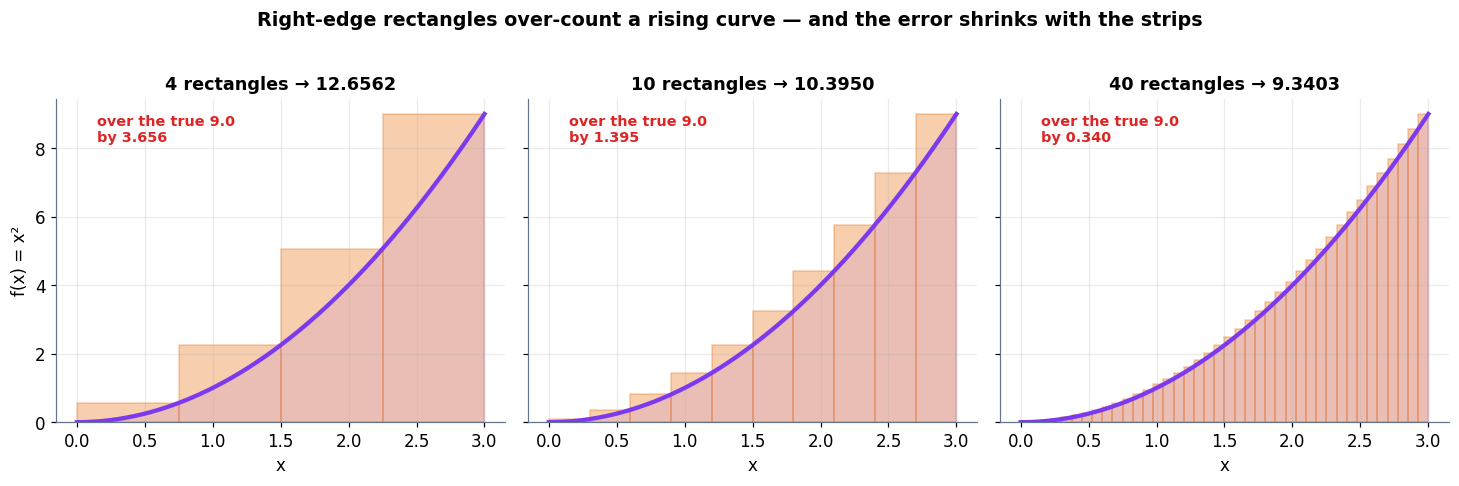

In [36]:
# ============================================================
#  Four rectangles, worked exactly as in the text
# ============================================================
def g(x):
    return x ** 2

a_lo, b_hi, n = 0.0, 3.0, 4
dx = (b_hi - a_lo) / n
right_edges = a_lo + dx * np.arange(1, n + 1)
heights = g(right_edges)

print(f"f(x) = x²  on [{a_lo:g}, {b_hi:g}]  with {n} rectangles, Δx = {dx:g}")
print("=" * 58)
print(f"{'strip':>7}{'right edge':>14}{'height f(x)':>16}{'area':>12}")
print("-" * 58)
for i, (xe, hh) in enumerate(zip(right_edges, heights), 1):
    print(f"{i:>7}{xe:>14.4f}{hh:>16.4f}{hh * dx:>12.6f}")
print("-" * 58)
print(f"{'sum of heights':>37}{heights.sum():>12.6f}")
print(f"{'× Δx':>37}{heights.sum() * dx:>12.6f}   <- the Riemann sum")
print()
print(f"book says   : 12.66")
print(f"we compute  : {heights.sum() * dx:.5f}   (the book rounds 12.65625)")
print(f"true area   : 9.0        -> we are over by {heights.sum()*dx - 9:.5f}")

# ============================================================
#  Figure: the rectangles, and where the over-count comes from
# ============================================================
def riemann(fn, a_, b_, n_, where="right"):
    dx_ = (b_ - a_) / n_
    if where == "right":  pts = a_ + dx_ * np.arange(1, n_ + 1)
    elif where == "left": pts = a_ + dx_ * np.arange(0, n_)
    else:                 pts = a_ + dx_ * (np.arange(n_) + 0.5)
    return float(fn(pts).sum() * dx_), pts, dx_

fig, axes = plt.subplots(1, 3, figsize=(13.4, 4.3), sharey=True)
xs = np.linspace(0, 3, 400)
for ax, n_ in zip(axes, [4, 10, 40]):
    tot, pts, dx_ = riemann(g, 0, 3, n_)
    ax.bar(pts - dx_, g(pts), width=dx_, align="edge", color=C_PRED,
           alpha=0.35, edgecolor=C_PRED, lw=1.0)
    ax.plot(xs, g(xs), color=C_MODEL, lw=2.8, zorder=4)
    ax.fill_between(xs, 0, g(xs), color=C_MODEL, alpha=0.10)
    ax.set_title(f"{n_} rectangles → {tot:.4f}", fontsize=11.5)
    ax.set_xlabel("x")
    ax.spines[["top", "right"]].set_visible(False)
    ax.text(0.15, 8.2, f"over the true 9.0\nby {tot - 9:.3f}", fontsize=9.4,
            color=C_ERR, fontweight="bold")
axes[0].set_ylabel("f(x) = x²")
fig.suptitle("Right-edge rectangles over-count a rising curve — and the error shrinks with the strips",
             fontsize=12.5, fontweight="bold", y=1.02)
plt.tight_layout(); plt.show()


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows


**Three panels, the same area, three levels of chopping.** In each, the purple curve is $f(x) = x^2$ on $[0, 3]$ and the shaded purple region is the true area we are chasing. The orange bars are the Riemann rectangles, each as tall as the curve at its **right edge**.

**Left, 4 rectangles.** Look at the little orange triangles poking out above the purple curve on every strip. Those slivers are the entire error: 12.66 instead of 9.00. Because the curve rises, the right edge is the *highest* point of each strip, so every rectangle over-claims.

**Middle and right, 10 and 40 rectangles.** The slivers get thinner. Each is roughly a triangle of width $\Delta x$ and height $f'(x)\Delta x$, so its area scales like $\Delta x^2$ — and there are $n$ of them, so the total error scales like $1/n$. Halve the strip width and you halve the error.

**What to look for:** the rectangles never become "curved". They stay as crude as they were; there are simply more of them, each responsible for less. That is the whole method of integration, and it is exactly the same trick as the shrinking nudge in Part 1 — approximate locally with something straight, then take a limit.

**The common misread:** thinking the over-count is a flaw in the method. It is a property of *right-edge sampling on a rising curve*. Left edges would under-count by a symmetric amount, and midpoints are far more accurate than either. The next cell measures all three.


</div>

In [37]:
# ============================================================
#  Taking the slices to zero — the convergence table
# ============================================================
TRUE = 9.0
print("f(x) = x² on [0, 3];  the exact area is 9.0")
print("=" * 84)
print(f"{'n':>7}{'Δx':>10}{'right edge':>14}{'left edge':>14}{'midpoint':>14}"
      f"{'right error':>15}")
print("-" * 84)
for n_ in [4, 10, 100, 1000, 100000]:
    r_, _, dx_ = riemann(g, 0, 3, n_, "right")
    l_, _, _ = riemann(g, 0, 3, n_, "left")
    m_, _, _ = riemann(g, 0, 3, n_, "mid")
    print(f"{n_:>7}{dx_:>10.5f}{r_:>14.5f}{l_:>14.5f}{m_:>14.7f}{r_ - TRUE:>15.6f}")
print("-" * 84)
print("book quotes (right edge) :  12.66,  10.40,   9.14,   9.01")
print("we compute               : ", ",  ".join(
    f"{riemann(g, 0, 3, n_)[0]:.2f}" for n_ in [4, 10, 100, 1000]))
print()
print("Right and left bracket the answer from above and below; the midpoint rule,")
print("with FOUR strips, is about as accurate as the right rule with a HUNDRED:")
print(f"  midpoint, n=4    : {riemann(g, 0, 3, 4, 'mid')[0]:.6f}   error "
      f"{abs(riemann(g, 0, 3, 4, 'mid')[0] - TRUE):.6f}")
print(f"  right edge, n=100: {riemann(g, 0, 3, 100)[0]:.6f}   error "
      f"{abs(riemann(g, 0, 3, 100)[0] - TRUE):.6f}")


f(x) = x² on [0, 3];  the exact area is 9.0
      n        Δx    right edge     left edge      midpoint    right error
------------------------------------------------------------------------------------
      4   0.75000      12.65625       5.90625     8.8593750       3.656250
     10   0.30000      10.39500       7.69500     8.9775000       1.395000
    100   0.03000       9.13545       8.86545     8.9997750       0.135450
   1000   0.00300       9.01350       8.98650     8.9999978       0.013504
 100000   0.00003       9.00014       8.99987     9.0000000       0.000135
------------------------------------------------------------------------------------
book quotes (right edge) :  12.66,  10.40,   9.14,   9.01
we compute               :  12.66,  10.39,  9.14,  9.01

Right and left bracket the answer from above and below; the midpoint rule,
with FOUR strips, is about as accurate as the right rule with a HUNDRED:
  midpoint, n=4    : 8.859375   error 0.140625
  right edge, n=100: 9.135

## 6.2 📐 The Definite Integral: the Sum at Its Limit

The estimate is converging to 9.0. That limit — the value the Riemann sum approaches as the strip width goes to zero — is the **definite integral**, and it gets its own notation:

$$ \int_0^3 x^2\,dx \;=\; \lim_{\Delta x \to 0}\; \sum_i f(x_i)\,\Delta x $$

Read the symbols one at a time, because each is a fossil of the sum it came from:

| Symbol | Was | Means |
|---|---|---|
| $\int$ | $\Sigma$ | an elongated **S** for *sum* |
| $dx$ | $\Delta x$ | what the strip width becomes when it shrinks to nothing |
| $0$ and $3$ | the ends | the left and right ends of the range |
| $f(x)$ | the height | the height of the strip at $x$ |

So $\int_0^3 x^2 dx$ says exactly: *add up $x^2 \cdot dx$ over infinitely many infinitesimally thin strips from 0 to 3.* **An integral is a Riemann sum evaluated at its limit** — nothing more mysterious than that.


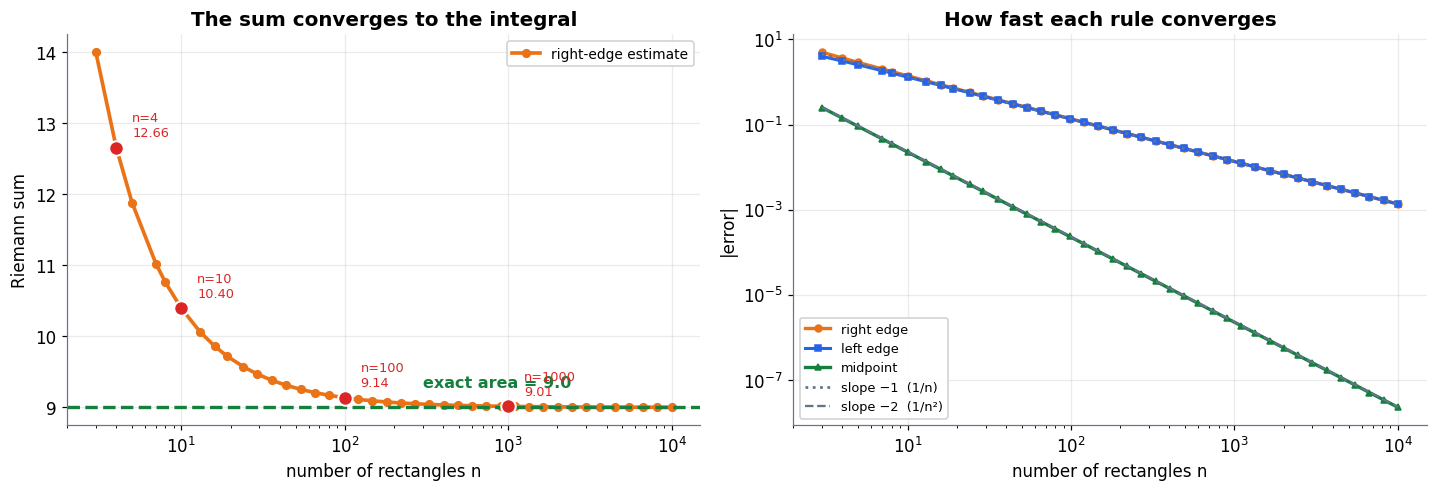

In [38]:
# ============================================================
#  Figure: convergence, and the rate at which it happens
# ============================================================
ns = np.unique(np.logspace(0.6, 4, 40).astype(int))
err_r = np.array([abs(riemann(g, 0, 3, int(n_), "right")[0] - TRUE) for n_ in ns])
err_l = np.array([abs(riemann(g, 0, 3, int(n_), "left")[0] - TRUE) for n_ in ns])
err_m = np.array([abs(riemann(g, 0, 3, int(n_), "mid")[0] - TRUE) for n_ in ns])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13.2, 4.6))

est = [riemann(g, 0, 3, int(n_))[0] for n_ in ns]
ax1.semilogx(ns, est, "o-", color=C_PRED, lw=2.4, ms=5, label="right-edge estimate")
ax1.axhline(TRUE, color=C_TRUE, ls="--", lw=2.2)
ax1.text(300, TRUE + 0.28, "exact area = 9.0", color=C_TRUE, fontsize=10.5,
         fontweight="bold")
for n_, lab in [(4, "12.66"), (10, "10.40"), (100, "9.14"), (1000, "9.01")]:
    v = riemann(g, 0, 3, n_)[0]
    ax1.scatter([n_], [v], s=90, color=C_ERR, zorder=6, edgecolor="white", lw=1.3)
    ax1.text(n_ * 1.25, v + 0.16, f"n={n_}\n{lab}", fontsize=8.4, color=C_ERR)
tidy(ax1, "number of rectangles n", "Riemann sum",
     "The sum converges to the integral", legend=True)
ax1.legend(fontsize=9)

ax2.loglog(ns, err_r, "o-", color=C_PRED, lw=2.2, ms=4.5, label="right edge")
ax2.loglog(ns, err_l, "s-", color=C_DATA, lw=2.0, ms=4, label="left edge")
ax2.loglog(ns, err_m, "^-", color=C_TRUE, lw=2.2, ms=4.5, label="midpoint")
ax2.loglog(ns, 13.5 / ns, ls=":", color=C_GREY, lw=1.8, label="slope −1  (1/n)")
ax2.loglog(ns, 2.3 / ns ** 2, ls="--", color=C_GREY, lw=1.5, label="slope −2  (1/n²)")
tidy(ax2, "number of rectangles n", "|error|",
     "How fast each rule converges", legend=True)
ax2.legend(fontsize=8.4, loc="lower left")
plt.tight_layout(); plt.show()


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows


**Left — the table, drawn.** Horizontal is the number of rectangles on a log axis; vertical is the Riemann sum they produce. Red dots mark the four values the book quotes: 12.66, 10.40, 9.14, 9.01. The green dashed line is the exact answer, 9.0. The estimate walks down onto it and stays.

**Right — the same convergence, but showing the *rate*.** Both axes are logarithmic and the vertical axis is now the **error**. On log-log axes a power law is a straight line whose slope is the power, and the two grey reference lines are slopes $-1$ and $-2$.

**What to look for:** right and left edge (orange and blue) both run parallel to the $1/n$ line — ten times as many rectangles buys you one decimal place. The midpoint rule (green) runs parallel to the $1/n^2$ line — ten times as many rectangles buys you *two* decimal places, because its over-count on one half of each strip cancels its under-count on the other.

**Why this matters beyond arithmetic:** this is the entire economics of numerical integration, and it is why Monte Carlo methods, quadrature rules and their descendants are a field of their own. The same question — *how much accuracy per unit of compute* — reappears whenever a model has to integrate something it cannot solve in closed form.

**The common misread:** looking at the left panel and calling the convergence "fast". It is not: $n = 1000$ still leaves an error of about $0.0135$ with the right rule. What makes integration practical is almost never brute-force rectangles. It is the shortcut in §6.3.


</div>

## 6.3 The Shortcut Nobody Expects: the Antiderivative

Summing a thousand rectangles by hand is miserable. The **Fundamental Theorem of Calculus** says you almost never have to, and it is genuinely one of the great results in mathematics:

$$ \textbf{Integration and differentiation are inverse operations.} $$

To find the area under $f$, find a function $F$ whose **derivative is $f$** — an *antiderivative* — and then

$$ \int_a^b f(x)\,dx \;=\; F(b) - F(a) $$

For $f(x) = x^2$, run the power rule backwards: what differentiates to $x^2$? Since $\frac{d}{dx}x^3 = 3x^2$, divide by 3:

$$ F(x) = \frac{x^3}{3} \qquad\text{because}\qquad F'(x) = \frac{3x^2}{3} = x^2 \;\checkmark $$

$$ \int_0^3 x^2\,dx = F(3) - F(0) = \frac{27}{3} - \frac{0}{3} = \mathbf{9} $$

Exactly 9.0, in one line, matching what a thousand rectangles were straining toward.

<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🧠 Two tools, two jobs

The **Riemann sum** tells you what an integral *means*: a total, accumulated from tiny pieces. Keep this picture — it is the one that transfers to probability.

The **antiderivative** tells you how to *compute* it fast, when the function is well behaved. Most functions a real model deals with are not well behaved, which is why numerical integration and Monte Carlo sampling exist at all.

</div>


In [39]:
# ============================================================
#  The Fundamental Theorem, checked in both directions
# ============================================================
xq = sp.Symbol("x")
F = xq ** 3 / 3

print("Claim: F(x) = x³/3 is an antiderivative of f(x) = x²")
print(f"  d/dx (x³/3) = {sp.diff(F, xq)}      <- yes, it gives back x²")
print()
val = float(F.subs(xq, 3) - F.subs(xq, 0))
print(f"F(3) − F(0) = {sp.nsimplify(F.subs(xq, 3))} − {sp.nsimplify(F.subs(xq, 0))} = {val:g}")
print(f"sympy integrate(x², (x, 0, 3)) = {sp.integrate(xq ** 2, (xq, 0, 3))}")
print(f"a million-rectangle midpoint sum = {riemann(g, 0, 3, 1000000, 'mid')[0]:.10f}")
print()
print("Three routes — antiderivative, symbolic integration, brute-force summation —")
print("and they agree. The theorem is not a shortcut that trades away accuracy.")
print()
for lo, hi in [(0, 1), (1, 2), (0, 3), (-2, 2)]:
    exact = float(F.subs(xq, hi) - F.subs(xq, lo))
    num, _, _ = riemann(g, lo, hi, 200000, "mid")
    print(f"  ∫ x² dx from {lo:>3} to {hi:>2} :  F(b)−F(a) = {exact:>9.5f}"
          f"   rectangles = {num:>9.5f}")


Claim: F(x) = x³/3 is an antiderivative of f(x) = x²
  d/dx (x³/3) = x**2      <- yes, it gives back x²

F(3) − F(0) = 9 − 0 = 9
sympy integrate(x², (x, 0, 3)) = 9
a million-rectangle midpoint sum = 9.0000000000

Three routes — antiderivative, symbolic integration, brute-force summation —
and they agree. The theorem is not a shortcut that trades away accuracy.

  ∫ x² dx from   0 to  1 :  F(b)−F(a) =   0.33333   rectangles =   0.33333
  ∫ x² dx from   1 to  2 :  F(b)−F(a) =   2.33333   rectangles =   2.33333
  ∫ x² dx from   0 to  3 :  F(b)−F(a) =   9.00000   rectangles =   9.00000
  ∫ x² dx from  -2 to  2 :  F(b)−F(a) =   5.33333   rectangles =   5.33333


## 6.4 Where Integration Actually Shows Up: Probability

<div style="background: linear-gradient(135deg, #f093fb 0%, #f5576c 100%); padding: 28px; border-radius: 18px; color: white; margin: 12px 0;">


### The reason this chapter is in a machine-learning book

🔗 In `foundations_3_probability.ipynb` you met **discrete** distributions: a random variable takes specific values, each with a specific probability. For a fair die, $P(X = 4) = 1/6$, and asking for the probability of one exact outcome is a sensible question.

Continuous quantities break that. What is the probability that a person is *exactly* 180.000000... cm tall? **Zero.** There are infinitely many possible heights, so no single one can carry any probability mass.


</div>

Continuous randomness is described instead by a **probability density function** (PDF), written $f(x)$ — and the rule changes accordingly:

$$ \boxed{\;P(a \le X \le b) \;=\; \int_a^b f(x)\,dx\;} $$

**The probability is not the height of the curve. It is the area under it.** Everything you know about area now transfers straight across, and two facts fall out immediately:

1. **Total area is exactly 1.** A probability can never exceed 1, and the variable must land *somewhere*, so $\int_{-\infty}^{\infty} f(x)\,dx = 1$. This is what makes a curve a valid distribution rather than just a curve.
2. **The probability of any single exact point is 0**, because $\int_a^a f(x)\,dx = 0$ — a strip of zero width has zero area. This is *why* we only ever ask about ranges for continuous variables.

Every time a model outputs a Gaussian and you ask "how confident is it that the true value is within this band?", you are computing $\int_a^b f$. Every softmax denominator and every Bayesian posterior normaliser is an integral forcing the total area to 1.


Standard normal, everything by adding up rectangles
  total area  ∫ f over [−12, 12]     = 1.0000000000
  P(−1 ≤ X ≤ 1)                      = 0.682689   (the 68% rule)
  P(−2 ≤ X ≤ 2)                      = 0.954500   (the 95% rule)
  P(−3 ≤ X ≤ 3)                      = 0.997300

  P(0 ≤ X ≤ 0.01)                     = 0.003989356315
  P(0 ≤ X ≤ 0.0001)                   = 0.000039894228
  P(0 ≤ X ≤ 1e-06)                    = 0.000000398942
  P(0 ≤ X ≤ 0)                        = 0.000000000000
  -> the probability of ONE exact value is the limit of that column: zero.

  sympy, symbolically: ∫ f(x) dx over all x = 1


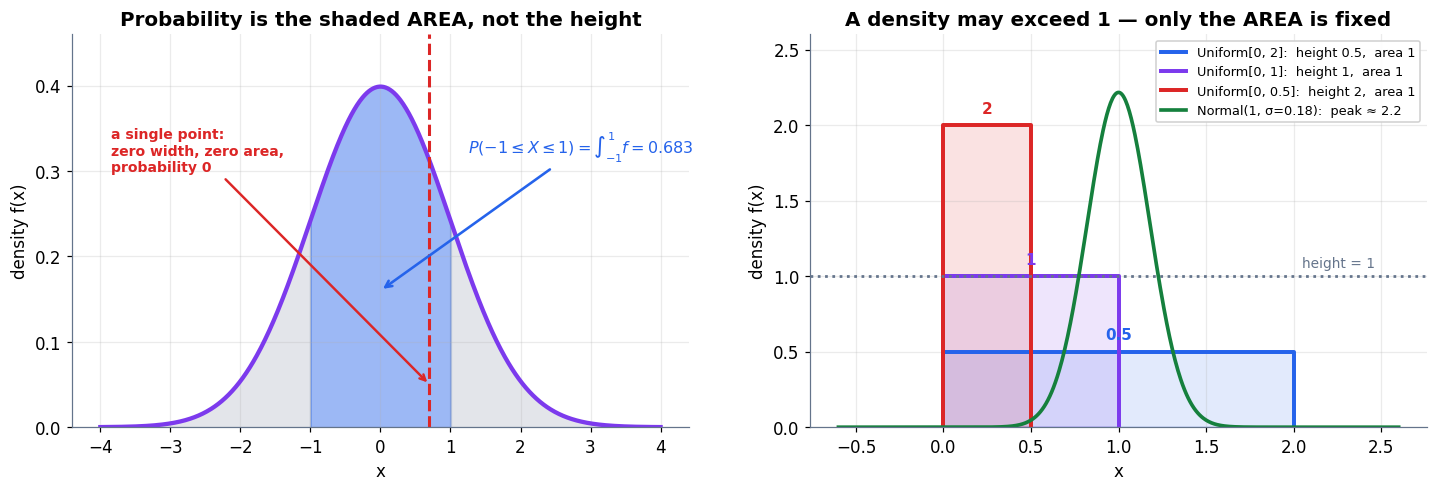

Uniform[0, 0.5] must be 2 tall to enclose area 1.
Normal(1, 0.18) peaks at 2.2163 — well above 1 —
and its total area is still 1.00000000.


In [40]:
# ============================================================
#  Probability = area. Measured on a Gaussian.
# ============================================================
def gauss(x, mu=0.0, sd=1.0):
    return np.exp(-0.5 * ((x - mu) / sd) ** 2) / (sd * np.sqrt(2 * np.pi))

def area(fn, lo, hi, n=400000):
    """Midpoint Riemann sum — the definition, with small enough rectangles."""
    dx_ = (hi - lo) / n
    return float(fn(lo + dx_ * (np.arange(n) + 0.5)).sum() * dx_)

print("Standard normal, everything by adding up rectangles")
print("=" * 62)
print(f"  total area  ∫ f over [−12, 12]     = {area(gauss, -12, 12):.10f}")
print(f"  P(−1 ≤ X ≤ 1)                      = {area(gauss, -1, 1):.6f}   (the 68% rule)")
print(f"  P(−2 ≤ X ≤ 2)                      = {area(gauss, -2, 2):.6f}   (the 95% rule)")
print(f"  P(−3 ≤ X ≤ 3)                      = {area(gauss, -3, 3):.6f}")
print()
for w in [1e-2, 1e-4, 1e-6, 0.0]:
    print(f"  P(0 ≤ X ≤ {w:g})".ljust(38) + f"= {area(gauss, 0, 0 + w, 2000) if w else 0.0:.12f}")
print("  -> the probability of ONE exact value is the limit of that column: zero.")
print()
x_s = sp.Symbol("x")
pdf_s = sp.exp(-x_s ** 2 / 2) / sp.sqrt(2 * sp.pi)
print(f"  sympy, symbolically: ∫ f(x) dx over all x = "
      f"{sp.integrate(pdf_s, (x_s, -sp.oo, sp.oo))}")

# ============================================================
#  Figure: area is the probability; height is not
# ============================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13.2, 4.6))

xs = np.linspace(-4, 4, 800)
ax1.plot(xs, gauss(xs), color=C_MODEL, lw=2.8)
band = (xs >= -1) & (xs <= 1)
ax1.fill_between(xs[band], 0, gauss(xs[band]), color=C_DATA, alpha=0.45)
ax1.fill_between(xs[xs <= -1], 0, gauss(xs[xs <= -1]), color=C_GREY, alpha=0.18)
ax1.fill_between(xs[xs >= 1], 0, gauss(xs[xs >= 1]), color=C_GREY, alpha=0.18)
ax1.annotate(f"$P(-1 \\leq X \\leq 1) = \\int_{{-1}}^{{1}} f = {area(gauss,-1,1):.3f}$",
             xy=(0, 0.16), xytext=(1.25, 0.32), fontsize=10.5, color=C_DATA,
             fontweight="bold", arrowprops=dict(arrowstyle="->", color=C_DATA, lw=1.7))
ax1.axvline(0.7, color=C_ERR, lw=2.0, ls="--")
ax1.annotate("a single point:\nzero width, zero area,\nprobability 0",
             xy=(0.7, 0.05), xytext=(-3.85, 0.30), fontsize=9.2, color=C_ERR,
             fontweight="bold", arrowprops=dict(arrowstyle="->", color=C_ERR, lw=1.6))
ax1.set_ylim(0, 0.46)
tidy(ax1, "x", "density f(x)", "Probability is the shaded AREA, not the height")

for w, col in [(2.0, C_DATA), (1.0, C_MODEL), (0.5, C_ERR)]:
    h = 1.0 / w
    ax2.plot([0, 0, w, w], [0, h, h, 0], color=col, lw=2.6,
             label=f"Uniform[0, {w:g}]:  height {h:g},  area {w*h:g}")
    ax2.fill_between([0, w], 0, h, color=col, alpha=0.13)
    ax2.text(w / 2, h + 0.08, f"{h:g}", ha="center", color=col, fontsize=10,
             fontweight="bold")
ax2.axhline(1.0, color=C_GREY, ls=":", lw=1.8)
ax2.text(2.05, 1.06, "height = 1", color=C_GREY, fontsize=9)
xs2 = np.linspace(-0.6, 2.6, 600)
ax2.plot(xs2, gauss(xs2, 1.0, 0.18), color=C_TRUE, lw=2.4,
         label="Normal(1, σ=0.18):  peak ≈ 2.2")
ax2.set_ylim(0, 2.6)
tidy(ax2, "x", "density f(x)", "A density may exceed 1 — only the AREA is fixed",
     legend=True)
ax2.legend(fontsize=8.4, loc="upper right")
plt.tight_layout(); plt.show()

print(f"Uniform[0, 0.5] must be {1/0.5:g} tall to enclose area 1.")
print(f"Normal(1, 0.18) peaks at {gauss(1.0, 1.0, 0.18):.4f} — well above 1 —")
print(f"and its total area is still {area(lambda t: gauss(t, 1.0, 0.18), -3, 5):.8f}.")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows


**Left — probability as area.** Horizontal is the value of the random variable; vertical is the **density**, not the probability. The blue shaded region between $-1$ and $1$ has area $0.683$, which *is* the probability that a standard normal draw lands in that band — the familiar 68% rule, here computed by adding up 400,000 rectangles rather than looked up in a table.

The red dashed line at $x = 0.7$ is a single exact value. It shades **nothing**, because a strip of zero width has zero area. That is the picture behind $P(X = 0.7) = 0$, and it is why continuous questions are always about ranges.

**Right — the trap that catches everyone once.** Three uniform distributions and a narrow Gaussian. As the uniform's base shrinks from 2 to 1 to 0.5, its height must rise from 0.5 to 1 to **2** to keep the enclosed area at exactly 1. The green Gaussian, squeezed to $\sigma = 0.18$, peaks above 2.2.

**What to look for:** the grey dotted line at height 1 is crossed freely. Nothing forbids it. A density is *probability per unit of $x$*, not a probability, so it has no ceiling — only its total area is constrained.

**The common misread:** panicking when a plotted PDF goes above 1 and assuming a bug. It is area conservation doing its job: squeeze the same unit of probability mass into a narrower range and the curve must spike. 🔗 Notebook 3 makes the same point from the distribution side; here it is a direct consequence of $\int f = 1$.


</div>

## 6.5 The Other Big One: Expected Value

The second place integration shows up in machine learning is the **expected value** — the long-run average of a random variable, and the most important summary statistic in the field.

For a **discrete** variable, weight each outcome by its probability and add:

$$ \mathbb{E}[X] = \sum_x x \cdot P(x) $$

For a **continuous** variable the sum becomes — you can guess it now — an integral, with the density playing the role of the weight:

$$ \mathbb{E}[X] = \int x \cdot f(x)\,dx $$

It is one idea seen from two sides: *value times probability, added up.* Discrete uses $\Sigma$; continuous uses $\int$; and the Riemann sum is the bridge, because an integral **is** a sum of infinitely many infinitely thin pieces.

### ✍️ Work it on a uniform

Take the uniform distribution on $[0, 2]$. It spreads probability evenly, so $f(x) = 0.5$ everywhere on that interval (base 2, height 0.5, area 1 — a valid PDF).

$$ \mathbb{E}[X] = \int_0^2 x \cdot 0.5\,dx = 0.5\int_0^2 x\,dx = 0.5\left[\frac{x^2}{2}\right]_0^2 = 0.5\left(\frac{4}{2} - 0\right) = 0.5 \cdot 2 = \mathbf{1.0} $$

The answer is **1.0**, the exact centre of the interval — which is precisely where the average of "any value from 0 to 2, all equally likely" ought to be.

<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ✅ Why checking a formula on an obvious case matters

The integral did not surprise us. It **recovered the intuitive answer**. That is exactly what you want from a first test of a new formula: when the machinery and the intuition agree on a case you already know, you have earned the right to trust the machinery on cases where intuition runs out — a skewed posterior, an expected loss over a data distribution you have never seen.

</div>


In [41]:
# ============================================================
#  Expected value, discrete and continuous, four ways each
# ============================================================
print("DISCRETE — a fair six-sided die")
print("=" * 62)
faces = np.arange(1, 7)
probs = np.full(6, 1 / 6)
print(f"  Σ x·P(x) = {(faces * probs).sum():.6f}")
print(f"  simulated mean of 400,000 rolls = "
      f"{rng.integers(1, 7, 400_000).mean():.6f}")
print()

print("CONTINUOUS — Uniform on [0, 2],  f(x) = 0.5")
print("=" * 62)
def unif_pdf(x, lo=0.0, hi=2.0):
    return np.where((x >= lo) & (x <= hi), 1.0 / (hi - lo), 0.0)

print(f"  total area  ∫ f dx                 = {area(unif_pdf, -1, 3):.8f}   (valid PDF)")
print(f"  E[X] = ∫ x·f(x) dx  by rectangles  = "
      f"{area(lambda t: t * unif_pdf(t), 0, 2):.8f}")
print(f"  E[X] by sympy                      = "
      f"{sp.integrate(xq * sp.Rational(1, 2), (xq, 0, 2))}")
print(f"  E[X] by hand: 0.5·[x²/2] from 0 to 2 = 0.5·2 = 1.0")
print(f"  simulated mean of 400,000 draws    = "
      f"{rng.uniform(0, 2, 400_000).mean():.6f}")
print()
print("Four independent routes to 1.0: symbolic, numeric, algebraic, empirical.")


DISCRETE — a fair six-sided die
  Σ x·P(x) = 3.500000
  simulated mean of 400,000 rolls = 3.503235

CONTINUOUS — Uniform on [0, 2],  f(x) = 0.5
  total area  ∫ f dx                 = 1.00000000   (valid PDF)
  E[X] = ∫ x·f(x) dx  by rectangles  = 1.00000000
  E[X] by sympy                      = 1
  E[X] by hand: 0.5·[x²/2] from 0 to 2 = 0.5·2 = 1.0
  simulated mean of 400,000 draws    = 0.999088

Four independent routes to 1.0: symbolic, numeric, algebraic, empirical.


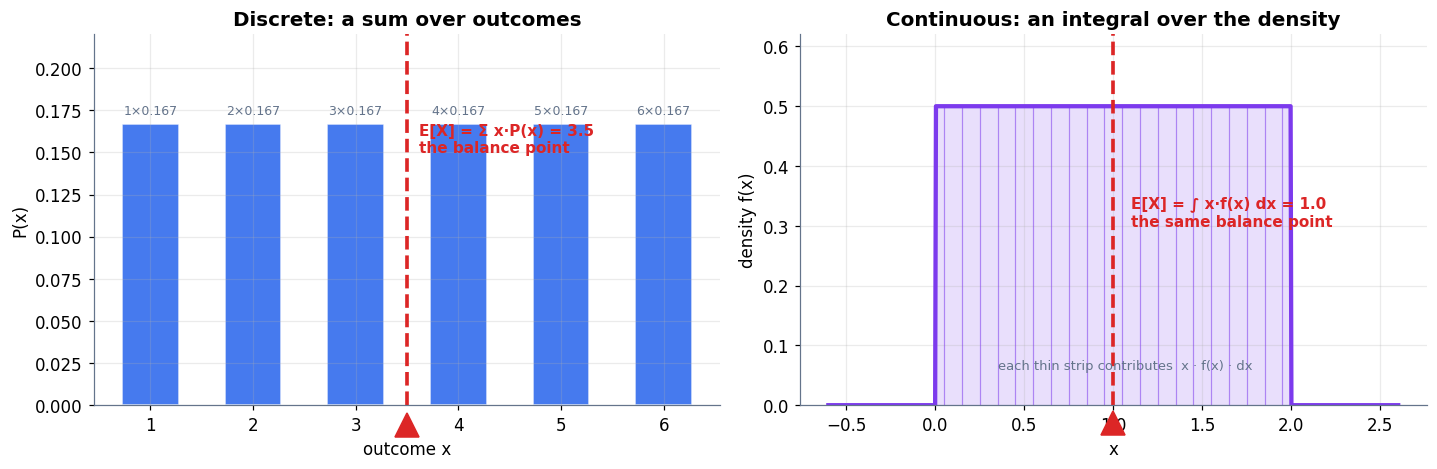

In [42]:
# ============================================================
#  Figure: expectation as the balance point
# ============================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13.2, 4.4))

ax1.bar(faces, probs, width=0.55, color=C_DATA, alpha=0.85, edgecolor="white")
for f_, p_ in zip(faces, probs):
    ax1.text(f_, p_ + 0.006, f"{f_}×{p_:.3f}", ha="center", fontsize=8.2, color=C_GREY)
ax1.axvline(3.5, color=C_ERR, lw=2.4, ls="--")
ax1.plot([3.5], [-0.012], marker="^", ms=16, color=C_ERR, clip_on=False)
ax1.text(3.62, 0.15, "E[X] = Σ x·P(x) = 3.5\nthe balance point", color=C_ERR,
         fontsize=10, fontweight="bold")
ax1.set_ylim(0, 0.22)
tidy(ax1, "outcome x", "P(x)", "Discrete: a sum over outcomes")

xs3 = np.linspace(-0.6, 2.6, 700)
ax2.plot(xs3, unif_pdf(xs3), color=C_MODEL, lw=2.8)
ax2.fill_between(xs3, 0, unif_pdf(xs3), color=C_MODEL, alpha=0.16)
ax2.axvline(1.0, color=C_ERR, lw=2.4, ls="--")
ax2.plot([1.0], [-0.03], marker="^", ms=16, color=C_ERR, clip_on=False)
ax2.text(1.1, 0.30, "E[X] = ∫ x·f(x) dx = 1.0\nthe same balance point",
         color=C_ERR, fontsize=10, fontweight="bold")
strip_x = np.linspace(0.05, 1.95, 20)
for sx in strip_x:
    ax2.plot([sx, sx], [0, 0.5], color=C_MODEL, lw=0.8, alpha=0.55)
ax2.text(0.35, 0.06, "each thin strip contributes  x · f(x) · dx",
         fontsize=8.6, color=C_GREY)
ax2.set_ylim(0, 0.62)
tidy(ax2, "x", "density f(x)", "Continuous: an integral over the density")
plt.tight_layout(); plt.show()


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows


**Left — the discrete case.** Horizontal is the six outcomes of a die; vertical is the probability of each, all $1/6$. The label above each bar is that outcome's contribution $x \cdot P(x)$ to the sum. The red triangle at 3.5 is the **balance point**: put the bars on a seesaw and 3.5 is where it tips level. That is what an expected value *is* — a centre of mass, not a value you can ever actually roll.

**Right — the continuous case, structurally identical.** Horizontal is $x$, vertical is the density of Uniform$[0, 2]$, a flat block of height 0.5. The thin vertical lines are the Riemann strips: each contributes $x \cdot f(x) \cdot dx$, exactly the same *value × weight* product as a bar on the left, only now there are infinitely many of them and each is infinitely thin. The balance point sits at 1.0.

**What to look for:** the two panels use different symbols ($\Sigma$ against $\int$) for the same operation. This is the single most useful thing to carry out of Part 6 — a sum and an integral are not two ideas, they are one idea at two resolutions.

**The common misread:** expecting $\mathbb{E}[X]$ to be a *likely* value. For the die, 3.5 is impossible. For a bimodal distribution the expectation can sit in the valley between the two humps, where the density is near zero. It is the balance point, and nothing more.


</div>

## 6.6 ✅ The Payoff: a Loss Function **Is** an Expected Value

Here is why all of this belongs in a book about learning.

A loss function is, formally, the **expected error of your model over the true data distribution**:

$$ L(\theta) \;=\; \mathbb{E}_{x \sim p_{\text{data}}}\big[\,\ell(f_\theta(x),\, y)\,\big] \;=\; \int \ell\big(f_\theta(x), y\big)\, p_{\text{data}}(x)\, dx $$

And there is an obvious problem: **we do not have $p_{\text{data}}$.** Nobody does. It is the true distribution of all possible photographs, or all possible sentences, and it is exactly the thing we are trying to learn about.

So we approximate that integral with the only thing we have — a finite pile of samples:

$$ \int \ell(x)\,p(x)\,dx \;\;\approx\;\; \frac{1}{N}\sum_{i=1}^{N} \ell(x_i) $$

<div style="background-color: #f3e5f5; border-left: 5px solid #9c27b0; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📖 `loss.mean()` is a Riemann sum in disguise

Every time you write `loss.mean()` over a batch, you are computing a **discrete approximation to a continuous expectation you cannot evaluate.** The batch is your set of rectangles; the batch size is how finely you sliced.

That reframing explains several things at once that otherwise look like folklore:

- **Why bigger batches give smoother gradients** — more rectangles, a better estimate of the same integral.
- **Why the estimate is noisy, and how noisy** — the error of a sample mean shrinks like $1/\sqrt{N}$, which is *slower* than the $1/n$ of ordered rectangles, because our samples land where the distribution puts them rather than where we choose.
- **Why training loss and test loss differ** — they are two different finite approximations of the same unreachable integral.
- **Why "the model overfits the training set"** is a statement about *approximation*, not about morality.

</div>

Let us measure that $1/\sqrt{N}$ on a case where the true expectation is known exactly.


In [43]:
# ============================================================
#  loss.mean() vs the integral it approximates
# ============================================================
# Setup with a KNOWN answer: x ~ N(0,1), truth y = 2x, model ŷ = 1.5x.
# Per-example loss  ℓ(x) = (1.5x − 2x)² = 0.25 x² ,  so
#     true expected loss = 0.25 · E[x²] = 0.25 · 1 = 0.25  exactly.
def per_example_loss(x):
    return (1.5 * x - 2.0 * x) ** 2

TRUE_EXPECTED_LOSS = 0.25
print("The integral we cannot normally compute — but here we can:")
print(f"  ∫ ℓ(x)·f(x) dx  by rectangles = "
      f"{area(lambda t: per_example_loss(t) * gauss(t), -12, 12):.10f}")
print(f"  by sympy                      = "
      f"{sp.integrate(sp.Rational(1,4) * xq**2 * sp.exp(-xq**2/2) / sp.sqrt(2*sp.pi), (xq, -sp.oo, sp.oo))}")
print(f"  exact                         = {TRUE_EXPECTED_LOSS}")
print()

print("Now the thing we actually do: average over a finite batch.")
print("=" * 78)
print(f"{'batch size N':>14}{'loss.mean() (5 draws)':>46}{'spread':>13}")
print("-" * 78)
sizes = [4, 16, 64, 256, 1024, 4096]
spread = []
for N in sizes:
    draws = [per_example_loss(rng.standard_normal(N)).mean() for _ in range(400)]
    spread.append(np.std(draws))
    shown_ = "  ".join(f"{d:6.3f}" for d in draws[:5])
    print(f"{N:>14}{shown_:>46}{np.std(draws):>13.4f}")
print("-" * 78)
print(f"true value being estimated : {TRUE_EXPECTED_LOSS}")
print(f"spread shrinks by a factor of {spread[0]/spread[-1]:.1f} as N grows "
      f"{sizes[-1]//sizes[0]}× — and √{sizes[-1]//sizes[0]} = {np.sqrt(sizes[-1]/sizes[0]):.1f}")


The integral we cannot normally compute — but here we can:
  ∫ ℓ(x)·f(x) dx  by rectangles = 0.2500000000
  by sympy                      = 1/4
  exact                         = 0.25

Now the thing we actually do: average over a finite batch.
  batch size N                         loss.mean() (5 draws)       spread
------------------------------------------------------------------------------
             4         0.096   0.089   0.019   0.064   0.157       0.1782
            16         0.191   0.268   0.236   0.274   0.311       0.0850
            64         0.250   0.229   0.300   0.257   0.256       0.0432
           256         0.250   0.251   0.276   0.242   0.250       0.0228
          1024         0.239   0.245   0.249   0.247   0.270       0.0117
          4096         0.249   0.250   0.252   0.256   0.253       0.0052
------------------------------------------------------------------------------
true value being estimated : 0.25
spread shrinks by a factor of 34.0 as N grows 1

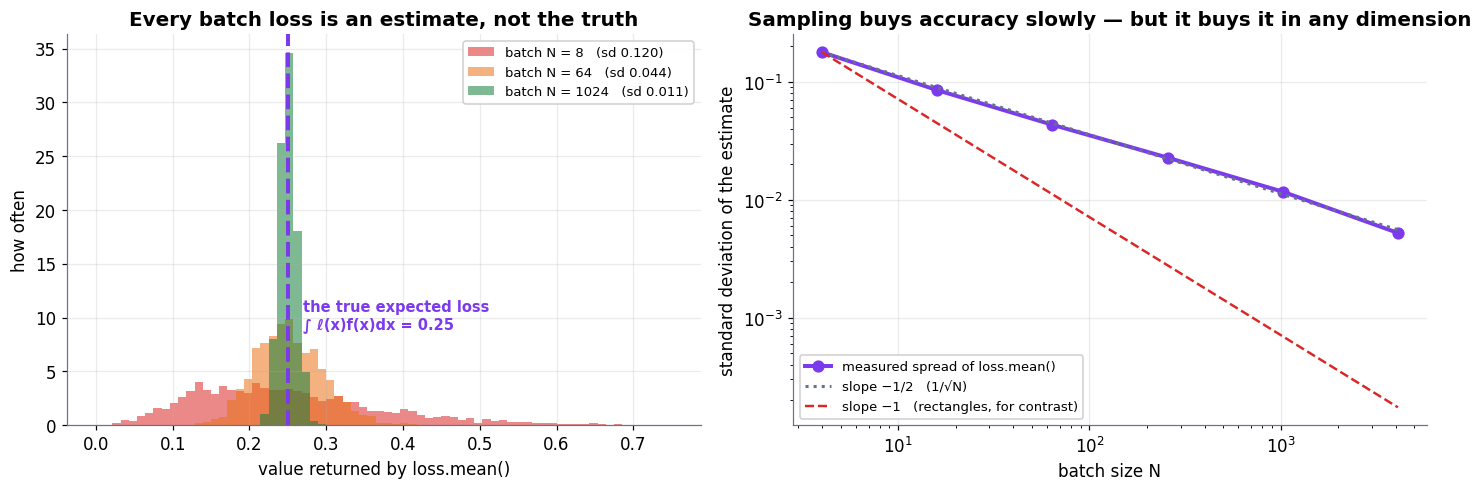

In [44]:
# ============================================================
#  Figure: the batch mean as a noisy measurement of an integral
# ============================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13.2, 4.6))

for N, col, off in [(8, C_ERR, 0), (64, C_PRED, 1), (1024, C_TRUE, 2)]:
    draws = np.array([per_example_loss(rng.standard_normal(N)).mean() for _ in range(3000)])
    ax1.hist(draws, bins=70, range=(0, 0.75), alpha=0.55, color=col, density=True,
             label=f"batch N = {N}   (sd {draws.std():.3f})")
ax1.axvline(TRUE_EXPECTED_LOSS, color=C_MODEL, lw=2.6, ls="--")
ax1.text(0.27, 9.0, "the true expected loss\n∫ ℓ(x)f(x)dx = 0.25", color=C_MODEL,
         fontsize=9.6, fontweight="bold")
tidy(ax1, "value returned by loss.mean()", "how often",
     "Every batch loss is an estimate, not the truth", legend=True)
ax1.legend(fontsize=8.6)

ax2.loglog(sizes, spread, "o-", color=C_MODEL, lw=2.6, ms=7,
           label="measured spread of loss.mean()")
ax2.loglog(sizes, spread[0] * (np.array(sizes) / sizes[0]) ** -0.5, ls=":",
           color=C_GREY, lw=2.0, label="slope −1/2   (1/√N)")
ax2.loglog(sizes, spread[0] * (np.array(sizes) / sizes[0]) ** -1.0, ls="--",
           color=C_ERR, lw=1.6, label="slope −1   (rectangles, for contrast)")
tidy(ax2, "batch size N", "standard deviation of the estimate",
     "Sampling buys accuracy slowly — but it buys it in any dimension", legend=True)
ax2.legend(fontsize=8.6, loc="lower left")
plt.tight_layout(); plt.show()


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows


**Left — what `loss.mean()` actually returns.** Horizontal is the value the batch mean reports; vertical is how often it reports it, over 3,000 independent batches. The purple dashed line at 0.25 is the *true* expected loss — the integral, which for this deliberately simple setup we can compute exactly.

**Read the three histograms as one story.** With $N = 8$ (red), individual batch losses scatter from below 0.05 to beyond 0.6: your printed training loss on any single small batch is barely informative. With $N = 64$ (orange) the spread tightens; with $N = 1024$ (green) it is a narrow spike on the true value. **Every one of these is unbiased** — they all centre on 0.25. What grows with $N$ is not correctness, it is *precision*.

**Right — the rate, on log-log axes.** The measured spread (purple) runs parallel to the grey $1/\sqrt{N}$ reference, not to the red $1/n$ line that ordered rectangles achieved in §6.2. Sampling is genuinely worse per unit of work than laying rectangles down in a row.

**So why does everyone sample?** Because the $1/n$ of rectangles is only available in one dimension. To integrate over a 1000-dimensional input space with a grid you would need $n^{1000}$ points; random sampling still costs $1/\sqrt{N}$ **no matter how many dimensions there are**. That single fact is why machine learning estimates every expectation it needs by averaging over batches.

**The common misread:** reading a jump in the training loss between two consecutive steps as the model getting worse. With a small batch, most of that jump is the measurement noise you can see in the red histogram — a different set of rectangles, not a different model.


</div>

<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ✅ Part 6 takeaway


**Derivatives are how a model learns; integrals are how it reasons about uncertainty.**

- An integral is a **Riemann sum at its limit** — slice, approximate each slice as flat, add, shrink.
- The **Fundamental Theorem** makes it cheap when a function is well behaved: $\int_a^b f = F(b) - F(a)$, where $F' = f$.
- For continuous variables, **probability is area**: $P(a \le X \le b) = \int_a^b f$, total area is 1, single points have probability 0, and a **density may exceed 1**.
- An **expected value** is *value × weight, added up*: $\Sigma$ when discrete, $\int$ when continuous — the same balance point either way.
- A **loss is an expected value**, and `loss.mean()` over a batch is a Riemann-style approximation of an integral nobody can compute — unbiased, and noisy at a rate of $1/\sqrt{N}$.

🔗 The densities and expectations here are the ones built in `foundations_3_probability.ipynb`. This part supplies the machinery underneath them.


</div>

# Part 7 · Capstone — and the End of the Series ⭐⭐⭐⭐

<div style="background: linear-gradient(135deg, #fc466b 0%, #3f5efb 100%); padding: 28px; border-radius: 18px; color: white; margin: 12px 0;">


### Four notebooks, one machine. Let's run it.

Everything is now built. Notebook 1 gave us the loop, Notebook 2 the matrices, Notebook 3 the probability, and this notebook the gradients. In this part we put all four together into a single model that we train, evaluate, and compare against the **best score any model could possibly achieve** on its data.

Then we close the whole series by answering the question every reader eventually asks out loud, usually a little suspiciously: *if these ideas are this old and this simple, why did the world only catch fire in the last decade?*


</div>

## 7.1 The Capstone: All Four Notebooks in One Model

**The problem.** Two classes of point, each drawn from its own Gaussian blob, deliberately **overlapping**. This is more honest than the crescents in Part 5: because the classes genuinely overlap, *no model can be perfect* — not ours, not a trillion-parameter one. There is a hard ceiling, and probability theory tells us exactly where it is.

**Where each notebook shows up:**

| Beat | Notebook | What it contributes here |
|---|---|---|
| **DATA** | 3 · probability | the data is *generated* from two known Gaussian densities, so we know the truth behind it |
| **MODEL** | 2 · linear algebra | every layer is $W\mathbf{x} + \mathbf{b}$ — a matrix transforming a vector |
| **LOSS** | 3 + 4 | binary cross-entropy: the negative log-likelihood of Notebook 3, an **expected value** in the sense of §6.6 |
| **UPDATE** | 4 · calculus | gradients by backpropagation, $\theta \leftarrow \theta - \eta\nabla L$ |
| **the loop** | 1 · the learning machine | forward, loss, backward, step — repeat |

**The ceiling.** With equal priors and two spherical Gaussians of the same width, the best achievable error rate — the **Bayes error** — is

$$ P(\text{error}) = \Phi\!\left(-\frac{d}{2}\right), \qquad d = \frac{\|\mu_1 - \mu_0\|}{\sigma} $$

where $\Phi$ is the normal CDF, itself an integral: $\Phi(t) = \int_{-\infty}^{t} \frac{1}{\sqrt{2\pi}}e^{-u^2/2}du$. We will compute it with the Riemann machinery from Part 6 — no lookup table, no `scipy`.

That number is the honest target. A model that beats it on the *test* set has got lucky, not clever.


In [45]:
# ============================================================
#  CAPSTONE — the four-beat loop, assembled from four notebooks
# ============================================================
# ---- BEAT 1 · DATA (notebook 3: two known Gaussian densities) --------
MU0, MU1, SD = np.array([-1.0, 0.0]), np.array([1.0, 0.6]), 0.8

def sample(n, seed):
    r = np.random.default_rng(seed)
    n0 = n // 2
    X0 = MU0[:, None] + SD * r.standard_normal((2, n0))
    X1 = MU1[:, None] + SD * r.standard_normal((2, n - n0))
    X = np.hstack([X0, X1])
    Y = np.hstack([np.zeros(n0), np.ones(n - n0)]).reshape(1, -1)
    idx = r.permutation(X.shape[1])
    return X[:, idx], Y[:, idx]

X_tr, Y_tr = sample(600, seed=21)
X_te, Y_te = sample(600, seed=99)          # a test set the model never trains on

# ---- the ceiling: Bayes error, by integration (part 6) ---------------
d_sep = np.linalg.norm(MU1 - MU0) / SD
Phi = lambda t: area(gauss, -12, t, 200000)          # our own normal CDF
bayes_err = Phi(-d_sep / 2)

print("BEAT 1 · DATA")
print("=" * 62)
print(f"  class 0 ~ N({MU0}, {SD}²I)   class 1 ~ N({MU1}, {SD}²I)")
print(f"  train {X_tr.shape[1]} points, test {X_te.shape[1]} points")
print(f"  separation d = ||μ1 − μ0|| / σ = {d_sep:.4f}")
print(f"  Bayes error   = Φ(−d/2) = Φ({-d_sep/2:.4f}) = {bayes_err:.4f}")
print(f"  CEILING on accuracy for ANY model = {100*(1-bayes_err):.2f}%")

# ---- BEATS 2-4 · MODEL, LOSS, UPDATE (notebooks 2 and 4) ------------
cap = Net([2, 12, 12, 1], seed=5)
eta_c, EP = 0.5, 3000
tr_hist, te_hist = [], []
for e in range(EP + 1):
    tr_hist.append(cap.loss(X_tr, Y_tr))       # LOSS   (notebook 3 + §6.6)
    te_hist.append(cap.loss(X_te, Y_te))
    cap.step(X_tr, Y_tr, eta_c)                # UPDATE (backprop, part 5)

X_big, Y_big = sample(20000, seed=123)      # a big set, to measure accuracy precisely
acc_tr = ((cap.predict(X_tr) > 0.5) == (Y_tr > 0.5)).mean()
acc_te = ((cap.predict(X_te) > 0.5) == (Y_te > 0.5)).mean()
acc_big = ((cap.predict(X_big) > 0.5) == (Y_big > 0.5)).mean()
# what the Bayes-optimal rule itself scores on that same sample
bayes_pred = (((X_big - MU1[:, None]) ** 2).sum(0)
              < ((X_big - MU0[:, None]) ** 2).sum(0)).astype(float)
acc_bayes = (bayes_pred == Y_big.ravel()).mean()

def se(acc, n):
    return np.sqrt(acc * (1 - acc) / n)

print()
print("BEATS 2-4 · MODEL, LOSS, UPDATE")
print("=" * 62)
print(f"  architecture {cap.sizes},  "
      f"{sum(w.size for w in cap.W) + sum(b.size for b in cap.b)} parameters")
print(f"  loss  train {tr_hist[0]:.4f} -> {tr_hist[-1]:.4f} | "
      f"test {te_hist[0]:.4f} -> {te_hist[-1]:.4f}")
print()
print(f"  accuracy, train (600)          {100*acc_tr:6.2f}%")
print(f"  accuracy, test  (600)          {100*acc_te:6.2f}%  ± {100*se(acc_te, 600):.2f}")
print(f"  accuracy, test  (20,000)       {100*acc_big:6.2f}%  ± {100*se(acc_big, 20000):.2f}")
print(f"  the Bayes ceiling              {100*(1-bayes_err):6.2f}%")
print(f"  the Bayes RULE on those 20,000 {100*acc_bayes:6.2f}%  "
      f"± {100*se(acc_bayes, 20000):.2f}")
print()
print(f"Note the 600-point test score of {100*acc_te:.2f}% sits ABOVE the ceiling.")
print(f"That is not a miracle: its standard error is ±{100*se(acc_te,600):.2f} points, so a")
print("finite sample can flatter a model by more than a point. Measure on 20,000")
print(f"and it falls to {100*acc_big:.2f}%, just under the ceiling — where it belongs.")
print("The perfect rule itself scores above the ceiling on that sample, for the")
print("same reason. A ceiling is a statement about the distribution, not a sample.")


BEAT 1 · DATA
  class 0 ~ N([-1.  0.], 0.8²I)   class 1 ~ N([1.  0.6], 0.8²I)
  train 600 points, test 600 points
  separation d = ||μ1 − μ0|| / σ = 2.6101
  Bayes error   = Φ(−d/2) = Φ(-1.3050) = 0.0959
  CEILING on accuracy for ANY model = 90.41%

BEATS 2-4 · MODEL, LOSS, UPDATE
  architecture [2, 12, 12, 1],  205 parameters
  loss  train 0.3888 -> 0.1459 | test 0.4146 -> 0.2486

  accuracy, train (600)           93.17%
  accuracy, test  (600)           91.00%  ± 1.17
  accuracy, test  (20,000)        90.22%  ± 0.21
  the Bayes ceiling               90.41%
  the Bayes RULE on those 20,000  90.45%  ± 0.21

Note the 600-point test score of 91.00% sits ABOVE the ceiling.
That is not a miracle: its standard error is ±1.17 points, so a
finite sample can flatter a model by more than a point. Measure on 20,000
and it falls to 90.22%, just under the ceiling — where it belongs.
The perfect rule itself scores above the ceiling on that sample, for the
same reason. A ceiling is a statement about

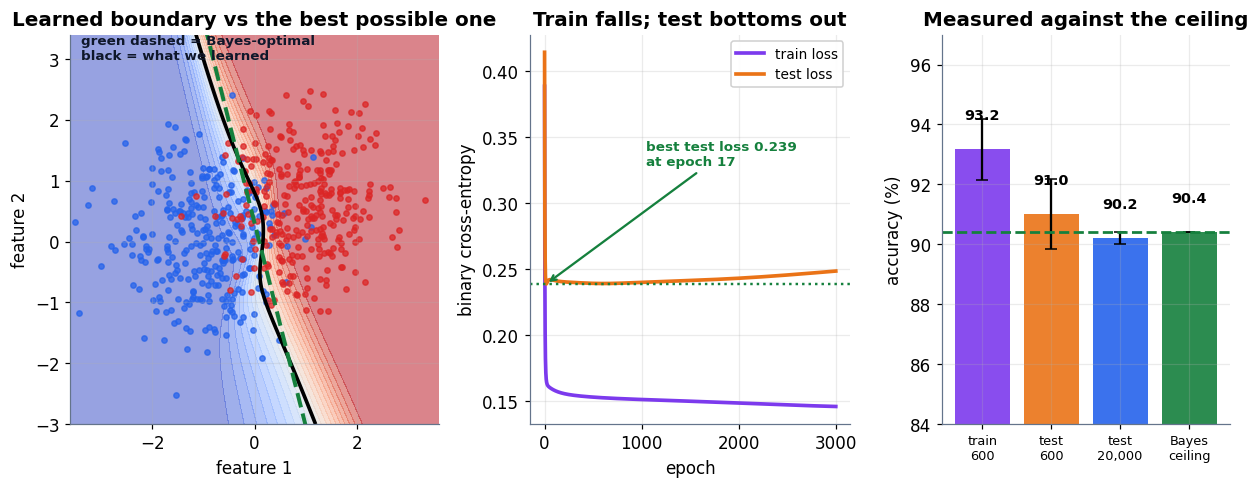

In [46]:
# ============================================================
#  Figure: the capstone, three ways
# ============================================================
fig = plt.figure(figsize=(13.6, 4.6))
gs = fig.add_gridspec(1, 3, width_ratios=[1.15, 1, 0.9], wspace=0.28)

ax1 = fig.add_subplot(gs[0])
gx3, gy3 = np.meshgrid(np.linspace(-3.6, 3.6, 240), np.linspace(-3.0, 3.4, 240))
grid3 = np.stack([gx3.ravel(), gy3.ravel()])
prob = cap.predict(grid3).reshape(gx3.shape)
ax1.contourf(gx3, gy3, prob, levels=np.linspace(0, 1, 21), cmap="coolwarm", alpha=0.55)
ax1.contour(gx3, gy3, prob, levels=[0.5], colors="k", linewidths=2.4)
# the Bayes-optimal boundary: equal densities <=> the perpendicular bisector
mid, direc = (MU0 + MU1) / 2, (MU1 - MU0)
tvals = np.linspace(-4, 4, 2)
ax1.plot(mid[0] - direc[1] * tvals, mid[1] + direc[0] * tvals,
         color=C_TRUE, lw=2.6, ls="--")
m0 = (Y_te.ravel() == 0)
ax1.scatter(X_te[0, m0], X_te[1, m0], s=12, color=C_DATA, alpha=0.75)
ax1.scatter(X_te[0, ~m0], X_te[1, ~m0], s=12, color=C_ERR, alpha=0.75)
ax1.set_xlim(-3.6, 3.6); ax1.set_ylim(-3.0, 3.4)
ax1.text(-3.4, 3.0, "green dashed = Bayes-optimal\nblack = what we learned",
         fontsize=8.8, fontweight="bold", color="#0F172A")
tidy(ax1, "feature 1", "feature 2", "Learned boundary vs the best possible one")

ax2 = fig.add_subplot(gs[1])
ax2.plot(tr_hist, color=C_MODEL, lw=2.4, label="train loss")
ax2.plot(te_hist, color=C_PRED, lw=2.4, label="test loss")
ax2.axhline(min(te_hist), color=C_TRUE, ls=":", lw=1.6)
ax2.annotate(f"best test loss {min(te_hist):.3f}\nat epoch {int(np.argmin(te_hist))}",
             xy=(np.argmin(te_hist), min(te_hist)),
             xytext=(EP * 0.35, min(te_hist) + 0.09), fontsize=8.8, color=C_TRUE,
             fontweight="bold", arrowprops=dict(arrowstyle="->", color=C_TRUE, lw=1.5))
tidy(ax2, "epoch", "binary cross-entropy", "Train falls; test bottoms out", legend=True)
ax2.legend(fontsize=9)

ax3 = fig.add_subplot(gs[2])
labels = ["train\n600", "test\n600", "test\n20,000", "Bayes\nceiling"]
vals = [100 * acc_tr, 100 * acc_te, 100 * acc_big, 100 * (1 - bayes_err)]
errs = [100 * se(acc_tr, 600), 100 * se(acc_te, 600), 100 * se(acc_big, 20000), 0]
bars = ax3.bar(labels, vals, yerr=errs, capsize=4,
               color=[C_MODEL, C_PRED, C_DATA, C_TRUE], alpha=0.9)
for b, v in zip(bars, vals):
    ax3.text(b.get_x() + b.get_width() / 2, v + 1.0, f"{v:.1f}", ha="center",
             fontsize=9.4, fontweight="bold")
ax3.axhline(100 * (1 - bayes_err), color=C_TRUE, ls="--", lw=1.8)
ax3.set_ylim(84, 97)
ax3.tick_params(axis="x", labelsize=8.4)
tidy(ax3, "", "accuracy (%)", "Measured against the ceiling")
plt.show()


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows


**Left — the learned boundary against the perfect one.** Axes are the two features. Blue and red dots are the held-out **test** points; the coloured background is our network's predicted probability. The black line is its decision boundary; the green dashed line is the **Bayes-optimal** boundary, which for two equal spherical Gaussians is exactly the perpendicular bisector of the line joining their centres.

Notice how much the two lines agree, and that the network's line is slightly **wobbly** — it has bent itself toward a few individual training points that happened to fall on the wrong side. That wobble is overfitting, visible as geometry rather than as a number.

**Middle — train and test loss together.** The train loss (purple) keeps falling, as it always will. The test loss (orange) falls, reaches a minimum, and then begins to **rise**. That turning point is the exact moment the model stops learning the distribution and starts learning the training sample, and it is the reason a held-out set is not optional.

**Right — the scoreboard against the ceiling**, with error bars showing the standard error of each estimate. The green dashed line is $1 - \Phi(-d/2)$, the best score *any* model could achieve given how much these two blobs overlap.

**What to look for:** the 600-point test bar sits **above** the ceiling — which no model can genuinely do. Its error bar explains why: on 600 points the standard error is more than a point, so a lucky sample flatters the model. Re-measured on 20,000 points the bar drops back below the line, where it belongs, and the printed output shows that the *perfect* Bayes rule also scores above the ceiling on that same sample. A ceiling is a statement about the distribution, not about any particular sample of it.

The remaining gap between the blue bar and the green line is not a defect to engineer away. Because the classes genuinely overlap, some points sit on the wrong side of even the perfect boundary — those errors live in the data.

**The common misread:** treating the remaining error as a problem to be engineered away. Adding parameters here can only push the *train* bar up while the *test* bar falls. When a model is already near the Bayes rate, more capacity buys memorisation, not accuracy.


</div>

## 7.2 One Equation Has Survived Every Era

<div style="background: linear-gradient(135deg, #fc466b 0%, #3f5efb 100%); padding: 28px; border-radius: 18px; color: white; margin: 12px 0;">


$$ \theta \leftarrow \theta - \eta \, \nabla L(\theta) $$

Strip away seventy years of jargon — perceptrons, expert systems, kernels, deep nets, transformers — and the learning rule at the bottom has barely moved. Parameters $\theta$, a loss $L$, its gradient $\nabla L$, a learning rate $\eta$, and a subtraction.

**Every model in this series, and every headline model outside it, is trained by a descendant of this line.** GPT-scale training is this loop run on a wider $\theta$, with more data, on faster hardware. That is not a simplification. It is literally the algorithm.


</div>

So the puzzle sharpens. Bayes died in 1761. Gradient descent is nineteenth-century calculus. Backpropagation was complete by the late 1980s. Yet the systems that write code and draft email arrived in the **2010s**.

If the loop is a constant, the revolution has to live in its **inputs**: how big $\theta$ is, how much data feeds $\nabla L$, and how fast we can compute the step. Three changes, one at a time.

## 7.3 Change One: the Winters Were Starvation, Not Wrong Ideas

The field has a famous history of **AI winters** — stretches in the 1970s and late 1980s when funding and faith collapsed because the systems underdelivered. It is tempting to read that as *"the ideas were wrong."* They were not. They were **starved**.

Take the founding example. The **perceptron** (Rosenblatt, 1958) is a single neuron: $z = w \cdot x + b$ followed by a threshold. One neuron, no hidden layer. In 1969 it was shown — correctly — that a single perceptron cannot learn **XOR**, the function that is true when exactly one of two inputs is on:

$$ (0,0) \to 0, \quad (1,1) \to 0, \quad (1,0) \to 1, \quad (0,1) \to 1 $$

A single neuron can only carve the plane with **one straight line**, and no straight line separates that checkerboard. The verdict at the time was that neural nets were a dead end.

**The fix was not a new idea. It was depth.** Stack a hidden layer between input and output and the network can bend the boundary into two pieces and solve XOR easily. What a stacked network needs is a way to assign blame to the hidden weights — and that is exactly **backpropagation**, the chain rule from Part 4 run backward layer by layer. The recipe was complete by the late 1980s. What was missing was fuel.

Let us run both models and watch it happen.


In [47]:
# ============================================================
#  XOR: one neuron cannot; one hidden layer can
# ============================================================
X_xor = np.array([[0., 0., 1., 1.],
                  [0., 1., 0., 1.]])
Y_xor = np.array([[0., 1., 1., 0.]])

flat = Net([2, 1], seed=0)          # a perceptron: no hidden layer
deep = Net([2, 4, 1], seed=0)       # one hidden layer of four units
for _ in range(6000):
    flat.step(X_xor, Y_xor, 1.0)
    deep.step(X_xor, Y_xor, 1.0)

print("XOR — the function that ended the first AI spring")
print("=" * 68)
print(f"{'input':>12}{'target':>9}{'no hidden layer':>19}{'one hidden layer':>20}")
print("-" * 68)
for i in range(4):
    print(f"{str(X_xor[:, i].astype(int)):>12}{int(Y_xor[0, i]):>9}"
          f"{flat.predict(X_xor)[0, i]:>19.4f}{deep.predict(X_xor)[0, i]:>20.4f}")
print("-" * 68)
for name, m in [("no hidden layer", flat), ("one hidden layer", deep)]:
    a = ((m.predict(X_xor) > 0.5) == (Y_xor > 0.5)).mean()
    print(f"  {name:<18} loss {m.loss(X_xor, Y_xor):.4f}   accuracy {100*a:5.1f}%")
print()
print(f"The flat model converges to log 2 = {np.log(2):.4f} and outputs 0.5 for")
print("everything: unable to separate the classes, it hedges perfectly. Note that")
print("even the BEST single line would only get 3 of the 4 points (75%) — gradient")
print("descent does not even find that, because the symmetric hedge has lower loss.")


XOR — the function that ended the first AI spring
       input   target    no hidden layer    one hidden layer
--------------------------------------------------------------------
       [0 0]        0             0.5000              0.0001
       [0 1]        1             0.5000              0.9998
       [1 0]        1             0.5000              0.9998
       [1 1]        0             0.5000              0.0002
--------------------------------------------------------------------
  no hidden layer    loss 0.6931   accuracy  50.0%
  one hidden layer   loss 0.0002   accuracy 100.0%

The flat model converges to log 2 = 0.6931 and outputs 0.5 for
everything: unable to separate the classes, it hedges perfectly. Note that
even the BEST single line would only get 3 of the 4 points (75%) — gradient
descent does not even find that, because the symmetric hedge has lower loss.


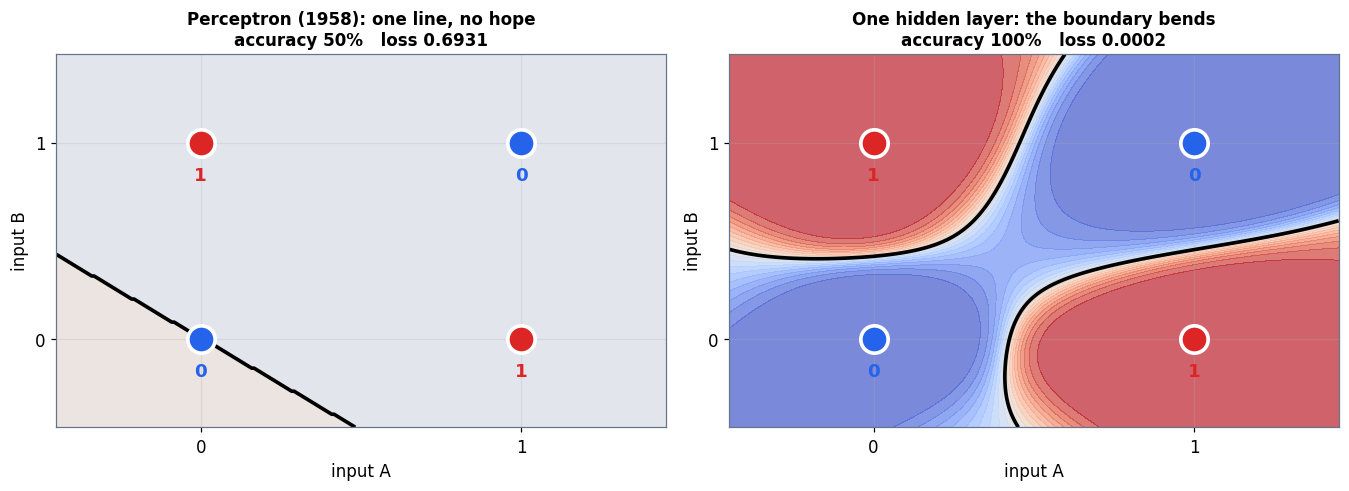

In [48]:
# ============================================================
#  Figure: one line cannot; two can
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(12.4, 4.6))
gxo, gyo = np.meshgrid(np.linspace(-0.45, 1.45, 260), np.linspace(-0.45, 1.45, 260))
grid_o = np.stack([gxo.ravel(), gyo.ravel()])

for ax, m, title in [(axes[0], flat, "Perceptron (1958): one line, no hope"),
                     (axes[1], deep, "One hidden layer: the boundary bends")]:
    p = m.predict(grid_o).reshape(gxo.shape)
    ax.contourf(gxo, gyo, p, levels=np.linspace(0, 1, 21), cmap="coolwarm", alpha=0.7)
    ax.contour(gxo, gyo, p, levels=[0.5], colors="k", linewidths=2.4)
    for i in range(4):
        col = C_ERR if Y_xor[0, i] == 1 else C_DATA
        ax.scatter([X_xor[0, i]], [X_xor[1, i]], s=320, color=col, zorder=6,
                   edgecolor="white", lw=2.4)
        ax.text(X_xor[0, i], X_xor[1, i] - 0.19, f"{int(Y_xor[0, i])}", ha="center",
                fontsize=12, fontweight="bold", color=col)
    acc = ((m.predict(X_xor) > 0.5) == (Y_xor > 0.5)).mean()
    ax.set_title(f"{title}\naccuracy {100*acc:.0f}%   loss {m.loss(X_xor, Y_xor):.4f}",
                 fontsize=11)
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xlabel("input A"); ax.set_ylabel("input B")
plt.tight_layout(); plt.show()


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows


**Two panels, the same four points, one architectural difference.** The axes are the two binary inputs; the four big dots are the whole of XOR, labelled with their target. Blue means 0, red means 1, and the background is each model's predicted probability with its 0.5 boundary drawn in black.

**Left — the perceptron.** The background is almost uniformly pale: the model has settled on predicting **0.5 everywhere**. That is not a bug, it is the optimum available to it. A single neuron can only draw one straight line, and there is no straight line with the two red points on one side and the two blue points on the other. Faced with an impossible task and a loss that rewards honesty, it hedges — and lands exactly on $\log 2$, the loss of a coin flip.

**Right — the same everything, plus four hidden units.** The background now has a genuine structure: red in two opposite corners, blue in the other two, with a boundary that **bends**. Accuracy is 100% and the loss is essentially zero.

**What to look for:** nothing changed except depth. Same loop, same loss, same learning rate, same optimiser, same number of epochs, same seed. The hidden layer did not add cleverness; it added the ability to compose two lines, and composition is what a single layer structurally cannot do.

**The common misread:** that the 1969 XOR result was a mistake. It was correct, and it was correct about single-layer networks specifically. What was wrong was the conclusion drawn from it — the fix (depth, plus a way to train it) was already conceptually available and took another two decades to become practical.


</div>

## 7.4 Change Two: the Data Flood and the Compute That Could Drink It

The modern era begins at an embarrassingly concrete moment. In **2012** a deep network called **AlexNet** won the ImageNet contest by a margin that made the room go quiet. Nothing about its mathematics would have surprised a researcher from 1990. What changed was two numbers meeting for the first time.

**Data.** ImageNet was roughly **1.2 million labelled images** across 1,000 categories — a training set that simply did not exist in the winter years. Recall from §6.6 that the quality of $\nabla L$ depends entirely on how many examples you average it over, and that the noise falls as $1/\sqrt{N}$. More and cleaner data makes every gradient step point in a truer direction.

**Compute.** AlexNet trained on consumer **GPUs** — and this is where Notebook 2 pays off directly. A network's forward and backward passes are, underneath, dense **matrix multiplications**, and a GPU does thousands of multiply-adds in parallel.

Make it tangible: multiplying a $1000 \times 1000$ matrix by a 1000-vector is $1000 \times 1000 = 1{,}000{,}000$ multiply-adds. Done one lane at a time, that is a million sequential steps. Done in parallel — every output entry is an **independent dot product** — it is a tiny fraction of the wall-clock time.

We do not have a GPU in this notebook, but we can demonstrate the same principle at a smaller scale: NumPy dispatches that matrix product to a vectorised BLAS routine, while a hand-written Python loop does the identical arithmetic one lane at a time.


In [49]:
# ============================================================
#  Same arithmetic, one lane at a time vs many lanes at once
# ============================================================
import time
n_dim = 1000
Amat = rng.standard_normal((n_dim, n_dim))
vvec = rng.standard_normal(n_dim)

t0 = time.perf_counter(); fast = Amat @ vvec; t_fast = time.perf_counter() - t0

t0 = time.perf_counter()
slow = np.zeros(n_dim)
for i in range(n_dim):                      # one output entry at a time...
    acc = 0.0
    for j in range(n_dim):                  # ...one multiply-add at a time
        acc += Amat[i, j] * vvec[j]
    slow[i] = acc
t_slow = time.perf_counter() - t0

print(f"A is {n_dim}×{n_dim}, v is {n_dim} long")
print(f"multiply-adds performed by BOTH methods : {n_dim * n_dim:,}")
print("=" * 64)
print(f"  Python loop, one lane at a time : {t_slow:8.4f} s")
print(f"  vectorised (BLAS under NumPy)   : {t_fast:8.6f} s")
print(f"  speed-up                        : {t_slow / t_fast:8.0f}×")
print(f"  same answer?  max difference    : {np.abs(fast - slow).max():.2e}")
print()
print("Identical arithmetic, identical result, three orders of magnitude apart.")
print("A GPU applies the same idea with thousands of lanes instead of a handful —")
print("which is why the maths that stalled in the 1990s flew in 2012.")


A is 1000×1000, v is 1000 long
multiply-adds performed by BOTH methods : 1,000,000
  Python loop, one lane at a time :   0.6285 s
  vectorised (BLAS under NumPy)   : 0.000925 s
  speed-up                        :      679×
  same answer?  max difference    : 2.13e-13

Identical arithmetic, identical result, three orders of magnitude apart.
A GPU applies the same idea with thousands of lanes instead of a handful —
which is why the maths that stalled in the 1990s flew in 2012.


## 7.5 Change Three: an Architecture That Rewards Scale

Data and compute lit the spark. The **transformer** (2017) turned it into an engine that gets better the more you feed it.

Earlier sequence models processed text strictly one step at a time, wasting exactly the parallelism GPUs had just unlocked. Attention computes every position at once, so it maps cleanly onto parallel hardware. But the property that actually opened the chequebooks was different: transformers exhibit smooth **scaling laws**. Widen the parameters, add data, add compute, and the loss drops **predictably**.

$$ L \;\approx\; L_\infty + \left(\frac{C}{N}\right)^{p} $$

where $N$ is parameters (or tokens, or FLOPs), $p$ is a small positive exponent, and $L_\infty$ is a floor you can never beat. Power laws look flat when plotted raw, so researchers read them on **log-log axes**, where a power becomes a straight line.

### ✍️ The book's worked example

Suppose a 1-billion-parameter model lands at loss 2.0, and every $10\times$ in parameters shaves 0.3 off the loss. Then 10B predicts 1.7, 100B predicts 1.4, and 1T predicts 1.1 — no cliff, no plateau, a ruler-straight line you can extend **before you spend any money**. That straight line is the justification for the invoice: a big training run stops being a gamble and becomes a budgeting decision.

<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ A subtlety worth being exact about

"A constant 0.3 per decade" and "$L = L_\infty + (C/N)^p$" are **not quite the same claim**. A constant drop per decade is a straight line against $\log N$ that keeps going down forever, eventually through zero and beyond — which is impossible, since a loss is bounded below. The power law bends: the drops shrink as $L$ approaches $L_\infty$.

The book itself says as much in the next breath — *"the curve is bending toward $L_\infty$, not toward zero"* — so the constant-0.3 arithmetic is a **local reading** of a curve that is genuinely flattening. The next cell fits a real power law through the first two of the book's points and shows exactly where the two descriptions part company.

</div>


In [50]:
# ============================================================
#  Scaling laws: the linear reading vs the actual power law
# ============================================================
N_pts = np.array([1e9, 1e10, 1e11, 1e12])
book_L = np.array([2.0, 1.7, 1.4, 1.1])        # "0.3 per decade"

# Fit L = L_inf + (C/N)^p through the FIRST TWO points, with a floor L_inf = 0.7.
L_INF = 0.7
# require L(1e9) = 2.0 and L(1e10) = 1.7  ->  (C/1e10)^p = 1.0 -> C = 1e10
C_fit = 1e10
p_fit = np.log10((2.0 - L_INF) / (1.7 - L_INF))     # 10^p = 1.3
law = lambda N: L_INF + (C_fit / N) ** p_fit

print(f"fitted power law:  L(N) = {L_INF} + (1e10 / N)^{p_fit:.4f}")
print("=" * 74)
print(f"{'parameters N':>16}{'book (0.3/decade)':>22}{'power law':>14}{'difference':>14}")
print("-" * 74)
for Nv, bl in zip(N_pts, book_L):
    print(f"{Nv:>16.0e}{bl:>22.2f}{law(Nv):>14.4f}{law(Nv) - bl:>14.4f}")
print("-" * 74)
print("The two agree exactly where the law was fitted and diverge as N grows:")
print("the power law's per-decade drops shrink (0.300, 0.231, 0.177, ...) because")
print("it is bending toward the floor, while the straight-line reading never bends.")
prev = law(1e9)
for k in range(1, 5):
    nxt = law(1e9 * 10 ** k)
    print(f"    decade {k}:  {prev:.4f} -> {nxt:.4f}   drop {prev - nxt:.4f}")
    prev = nxt
print()
print(f"Extended far enough, the straight line reaches zero loss at N = "
      f"1e{9 + 2.0/0.3:.1f}, which is impossible; the power law never gets below "
      f"{L_INF}.")


fitted power law:  L(N) = 0.7 + (1e10 / N)^0.1139
    parameters N     book (0.3/decade)     power law    difference
--------------------------------------------------------------------------
           1e+09                  2.00        2.0000        0.0000
           1e+10                  1.70        1.7000        0.0000
           1e+11                  1.40        1.4692        0.0692
           1e+12                  1.10        1.2917        0.1917
--------------------------------------------------------------------------
The two agree exactly where the law was fitted and diverge as N grows:
the power law's per-decade drops shrink (0.300, 0.231, 0.177, ...) because
it is bending toward the floor, while the straight-line reading never bends.
    decade 1:  2.0000 -> 1.7000   drop 0.3000
    decade 2:  1.7000 -> 1.4692   drop 0.2308
    decade 3:  1.4692 -> 1.2917   drop 0.1775
    decade 4:  1.2917 -> 1.1552   drop 0.1365

Extended far enough, the straight line reaches zero loss 

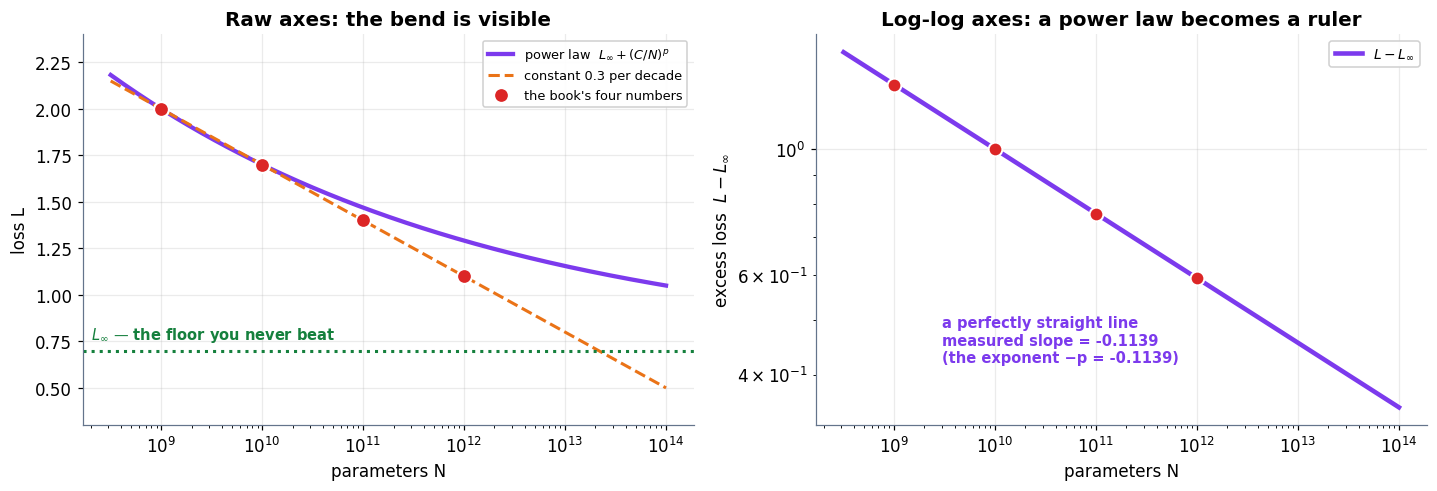

In [51]:
# ============================================================
#  Figure: why labs plot scaling laws on log-log axes
# ============================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13.2, 4.6))

Ns = np.logspace(8.5, 14, 300)
ax1.semilogx(Ns, law(Ns), color=C_MODEL, lw=2.8, label="power law  $L_\\infty + (C/N)^p$")
ax1.semilogx(Ns, 2.0 - 0.3 * np.log10(Ns / 1e9), color=C_PRED, lw=2.0, ls="--",
             label="constant 0.3 per decade")
ax1.scatter(N_pts, book_L, s=95, color=C_ERR, zorder=6, edgecolor="white", lw=1.4,
            label="the book's four numbers")
ax1.axhline(L_INF, color=C_TRUE, ls=":", lw=2.0)
ax1.text(2e8, L_INF + 0.06, "$L_\\infty$ — the floor you never beat", color=C_TRUE,
         fontsize=9.6, fontweight="bold")
ax1.set_ylim(0.3, 2.4)
tidy(ax1, "parameters N", "loss L", "Raw axes: the bend is visible", legend=True)
ax1.legend(fontsize=8.4, loc="upper right")

excess = law(Ns) - L_INF
ax2.loglog(Ns, excess, color=C_MODEL, lw=3.0, label="$L - L_\\infty$")
ax2.loglog(N_pts, law(N_pts) - L_INF, "o", color=C_ERR, ms=9, zorder=6,
           markeredgecolor="white", markeredgewidth=1.3)
slope = np.log(excess[-1] / excess[0]) / np.log(Ns[-1] / Ns[0])
ax2.text(3e9, 0.42, f"a perfectly straight line\nmeasured slope = {slope:+.4f}\n"
                    f"(the exponent −p = {-p_fit:+.4f})",
         fontsize=9.6, color=C_MODEL, fontweight="bold")
tidy(ax2, "parameters N", "excess loss  $L - L_\\infty$",
     "Log-log axes: a power law becomes a ruler", legend=True)
ax2.legend(fontsize=9)
plt.tight_layout(); plt.show()


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows


**Left — the two readings of the same four numbers.** Horizontal is parameter count on a log axis; vertical is the loss. Red dots are the book's four quoted values. The orange dashed line is the "0.3 per decade" reading, which is straight forever. The purple curve is a genuine power law fitted through the first two points, with its floor $L_\infty$ marked in green.

They are indistinguishable where the fit was made and separate visibly by $10^{12}$ parameters. Follow the orange line far enough and it crosses zero loss, then goes negative — which no loss can do. The purple curve flattens toward the floor instead, which is why each additional decade of scale buys less than the last while costing $10\times$ more.

**Right — the reason labs plot it this way.** Both axes are logarithmic, and the vertical axis is the **excess** loss $L - L_\infty$. The power law becomes a perfectly straight line whose slope is measured on the figure as $-p$. That is the whole engineering value of a scaling law: fit two points, read the slope, and you can **forecast the loss of a model you have not trained yet**.

**What to look for:** the straightness on the right is not evidence about reality — it is what fitting a power law guarantees. The genuine empirical finding, from thousands of real training runs, is that measured losses **do** fall close to such a line over many orders of magnitude. That reproducibility is what turned a research gamble into a budgeting decision.

**The common misread:** reading a scaling law as a promise of unlimited improvement. It contains its own ceiling, in plain sight: $L_\infty$. The line is straight in the *excess* over the floor, and the floor never moves.


</div>

<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ The pitfall that trips careful readers

Seeing that the loop never changes, it is tempting to conclude that scaling is *only* more of the same — and that with a big enough computer we could have had today's models in 1990.

Not quite. Data, compute and parameters were the primary requirements, but the transformer also supplied a better **inductive bias**: a structure that spends its parameters more wisely on language. Without it the same FLOPs buy a far worse model.

So the accurate claim is narrow: **the optimisation loop is a constant; the architecture fed into it still matters enormously.** Confusing *the same loop* with *the same system* is the mistake.

</div>

## 7.6 So What Is Actually Next — and What Stays Constant

It is easy to feel the frontier is racing away from you. Look at where the field is going, and every arrow lands back on the four pillars this series built.

| Direction | What it really is |
|---|---|
| **Bigger and multimodal models** | more $\theta$, more data, the *same* descent — one text-and-image loss instead of one text loss |
| **Efficiency and small models** (quantisation, distillation, on-device) | the inverse pressure: keep the accuracy, shrink $\theta$ and the compute. Optimisation and linear algebra squeezed hard, not a new science |
| **Reinforcement learning from feedback** (the technique behind aligned assistants) | the third paradigm from Notebook 1 — a reward signal instead of a fixed label — steering the same gradient step |
| **Evaluation and trust** | precision, recall and the confusion matrix, deciding whether a model is genuinely good or merely looks good |

Notice the through-line. Every capability leap sits on the same base: **a matrix as a linear transformation, a gradient as the direction of steepest ascent that you descend, probability to model uncertainty and read off a prediction.** You did not learn the ancestors of modern AI. You learned its live, load-bearing parts.

<div style="background: linear-gradient(135deg, #fc466b 0%, #3f5efb 100%); padding: 26px; border-radius: 18px; color: white; margin: 14px 0;">

### The claim worth defending

There has been roughly **one genuinely new idea** in this book's toolbox in seventy years: the parallel, all-pairs mixing of **attention**. Everything else that seemed extraordinary was old mathematics finally given enough data and enough parallel compute to work.

The winters were starvation. The spring was fuel. The engine was always the gradient.

</div>

You are not perpetually one breakthrough behind, because you are holding the durable core. When the next architecture lands, you will read its paper and recognise the matrices, the softmax, the loss and the gradient descent — and then ask the only question that matters: **what did it unlock? More scale, cheaper compute, or a better inductive bias?**


---

# 🏆 Cheat Sheet

## The one line

$$ \theta \leftarrow \theta - \eta\,\nabla L(\theta) $$

## Derivatives

| Idea | Formula |
|---|---|
| definition | $f'(x) = \lim_{h\to 0}\dfrac{f(x+h)-f(x)}{h}$ |
| power rule | $\dfrac{d}{dx}x^n = n x^{n-1}$ |
| sum rule | $(u+v)' = u' + v'$ |
| product rule | $(uv)' = u'v + uv'$ |
| chain rule | $\dfrac{d}{dx}f(g(x)) = f'(g(x))\,g'(x)$ |
| sigmoid | $\sigma'(z) = \sigma(z)(1-\sigma(z)) \le 0.25$ |
| tanh | $\tanh'(z) = 1 - \tanh^2(z) \le 1$ |
| ReLU | $\text{ReLU}'(z) = 1$ if $z>0$, else $0$ |
| sigmoid + BCE | $\delta = \dfrac{dL}{dz} = a - y$ |

## Gradients

| Idea | Meaning |
|---|---|
| $\partial f/\partial x$ | derivative with all other variables **frozen** |
| $\nabla f$ | the vector of all partials |
| direction | points **steepest uphill**; step against it |
| length $\|\nabla f\|$ | the steepest rate of increase |
| $\nabla f \cdot \mathbf{u} = \|\nabla f\|\cos\theta$ | why it is steepest — maximised at $\theta = 0$ |
| $\nabla f \perp$ contours | walking a contour changes nothing |

## Backpropagation

```python
# forward: cache x, z = W @ x + b, a = phi(z)
delta         = grad_from_above * phi_prime(z)   # dL/dz
grad_W        = delta @ x.T
grad_b        = delta
grad_to_below = W.T @ delta                      # transpose = the fan-out rule
```

- multiply local slopes **along** a path; **add** across paths that fan out
- cost is **two passes**, independent of the parameter count
- gradient through $N$ layers $\sim \kappa^N$: $\kappa<1$ vanishes, $\kappa>1$ explodes

## Integrals

| Idea | Formula |
|---|---|
| definite integral | $\int_a^b f = \lim_{\Delta x\to 0}\sum_i f(x_i)\Delta x$ |
| fundamental theorem | $\int_a^b f = F(b)-F(a)$ where $F' = f$ |
| probability | $P(a\le X\le b) = \int_a^b f(x)dx$, total area $=1$ |
| single point | $P(X = a) = 0$; a **density may exceed 1** |
| expectation, discrete | $\mathbb{E}[X] = \sum x\,P(x)$ |
| expectation, continuous | $\mathbb{E}[X] = \int x\,f(x)\,dx$ |
| a loss | an expectation; `loss.mean()` estimates it, noise $\propto 1/\sqrt{N}$ |

## Numbers worth remembering

| Quantity | Value |
|---|---|
| $\sigma'$ ceiling | $0.25$, only at $z=0$ |
| stable $\eta$ for $3y^2$ | $\eta < 1/3$ |
| ReLU + He init, 25 layers | per-layer factor $\approx 0.98$ |
| sigmoid + standard init, 25 layers | per-layer factor $\approx 0.23$ |
| gradient check should reach | relative error $< 10^{-7}$ |


---

# ⚠️ Common Pitfalls to Avoid

1. **Confusing the derivative with the tangent line.** The tangent is a picture; the derivative is a number. What flows backward through a network is the number.
2. **Stepping *with* the gradient.** $\theta \leftarrow \theta + \eta\nabla L$ is gradient *ascent* — a model that makes itself worse as fast as possible. The minus sign is the algorithm.
3. **Blaming the direction when the step size is at fault.** In §3.3 every diverging step pointed downhill correctly. $\nabla L$ gives you a direction you can trust and a distance you cannot.
4. **Assuming a learning rate transfers.** $\eta < 1/3$ was a fact about *that* bowl's curvature. Change the loss, change the threshold. This is why every recipe starts with a sweep.
5. **Reading "slope zero" as "loss zero".** In §1.4 the flat spot sat at $L = 1$. Converged means *cannot locally improve*, not *is right*.
6. **Following one path through a fan-out.** When a value feeds several places, its gradient is the **sum** — not the max, not the mean. In code this is `grad +=`, and forgetting `optimizer.zero_grad()` is the same bug from the other side.
7. **Shipping an unchecked gradient.** A wrong gradient throws no exception. It produces a run that looks plausible and learns the wrong thing. Gradient-check *before* you train, and expect a relative error below $10^{-7}$.
8. **Treating vanishing gradients as a problem of depth.** Depth is only the exponent; the base $\kappa$ is set by your activation and initialisation — the parts you control.
9. **Trying to fix a saturating sigmoid by scaling up the weights.** §5.5 measured it: bigger weights push $z$ into the flat tails, and $\sigma'$ takes back what the matrix gave. Change the activation, not the volume.
10. **Reading a density as a probability.** A PDF may exceed 1; only its total *area* is fixed. Uniform on $[0, 0.5]$ has height 2 and is perfectly valid.
11. **Trusting a single batch loss.** `loss.mean()` is a noisy estimate of an integral. With a small batch, most of a step-to-step jump is measurement noise, not the model changing.
12. **Believing the loop being constant means the system is.** Same $\theta \leftarrow \theta - \eta\nabla L$, wildly different results, because architecture supplies inductive bias.
13. **Extending a scaling law to zero loss.** It has a floor built into it. The straight line lives in $L - L_\infty$, and $L_\infty$ does not move.

---

# 🧠 Self-Check

Cover the notebook. If you can do all ten, Notebook 4 has done its job.

| # | Can you… | Part |
|---|---|---|
| 1 | Compute a derivative from the limit definition, and say what the *sign* tells you? | 1 |
| 2 | State the four rules and apply them to $L(w) = w^2 - 4w + 5$? | 1 |
| 3 | Take a partial derivative and explain what "freeze the others" means? | 2 |
| 4 | Explain, using the dot product, **why** the gradient points steepest uphill? | 2 |
| 5 | Run three steps of gradient descent by hand, and predict when a run will diverge? | 3 |
| 6 | Use the chain rule to reach a weight three links from the loss — and check it by nudging? | 4 |
| 7 | Say what happens to a gradient when a value fans out, and why it is a sum? | 4 |
| 8 | Write the four-line backward step, and justify the transpose? | 5 |
| 9 | Explain why backprop costs two passes rather than one per parameter? | 5 |
| 10 | Explain why `loss.mean()` is a Riemann sum, and what its error rate is? | 6 |

**Extensions, if you want to push further:**

- **A.** In §3.3 we derived $\eta < 1/3$ from the curvature 6 in the $y$ direction. Derive the threshold for the $x$ direction (curvature 2), then explain why one shared learning rate cannot be optimal for both — and what an adaptive optimiser like Adam does about it.
- **B.** Replace $\tanh$ with ReLU in the `Net` class of Part 5. You will need to change **one line** of `backward`. Gradient-check it, then compare training speed on the moons.
- **C.** Rerun the §5.5 measurement with $\tanh$ instead of sigmoid, and with residual connections ($a = \varphi(z) + x$). Where does $\kappa$ land, and why does the residual path help so much?
- **D.** The capstone's test loss turned upward while the train loss kept falling. Add early stopping at the minimum of the test loss and measure what it buys. Then try shrinking the network instead — which helps more, and why?
- **E.** Estimate $\int_0^1 \sqrt{1-x^2}\,dx = \pi/4$ two ways: with rectangles, and by averaging random samples. Plot error against work for both, and find the dimension at which sampling would win.

---

# 📚 References

**The source for this series**
- *Foundations for AI &amp; ML* — Vizuara (`books.vizuara.ai`). This notebook covers the **Calculus for Optimization** section — *Differential Calculus: Derivatives and Gradients*; *The Chain Rule and Backpropagation*; *Integral Calculus Foundations for ML* — and the closing chapter *The Evolution and Future of AI/ML*.

**To build the intuition visually**
- 3Blue1Brown — *Essence of Calculus*, and *Neural Networks* chapters 3–4 for backpropagation.
- Andrej Karpathy — *The spelled-out intro to neural networks and backpropagation* (`micrograd`), which builds the same backward pass one scalar at a time.

**The history in Part 7**
- Rosenblatt (1958) — the perceptron. · Minsky &amp; Papert (1969) — the XOR result.
- Rumelhart, Hinton &amp; Williams (1986) — *Learning representations by back-propagating errors*.
- Glorot &amp; Bengio (2010); He et al. (2015) — the initialisations measured in §5.5.
- Krizhevsky, Sutskever &amp; Hinton (2012) — AlexNet. · Vaswani et al. (2017) — *Attention Is All You Need*.
- Kaplan et al. (2020); Hoffmann et al. (2022) — scaling laws.

**The rest of this series**
- `foundations_1_the_learning_machine.ipynb` — the four-beat loop this notebook completes.
- `foundations_2_linear_algebra.ipynb` — the dot product behind §2.2, and the matrices behind §5.2.
- `foundations_3_probability.ipynb` — the densities and expectations of Part 6.

---

<div style="background: linear-gradient(135deg, #11998e 0%, #38ef7d 100%); padding: 32px; border-radius: 20px; color: white; text-align: center; margin: 22px 0;">

## 🎓 Notebook Complete


## 🎓 And that is the whole series.

You started, four notebooks ago, with three words people use interchangeably. You finish holding the machine itself.

**Notebook 1** built the loop: data → model → loss → update, and left two boxes open.
**Notebook 2** made the model a matrix. **Notebook 3** made the data and the scoreboard probabilistic.
**Notebook 4** opened the last two boxes — and you did not take a single result on trust: every derivative here was checked with SymPy, with finite differences, or against `torch.autograd`, and where the book's arithmetic and ours disagreed, we printed both.

You derived the gradient, proved it points steepest uphill, broke gradient descent on purpose and diagnosed it, built backpropagation from four lines of matrix algebra, gradient-checked it to $10^{-10}$, trained a network that no straight line could ever fit, measured the vanishing gradient instead of believing it, and showed that the `loss.mean()` you will write a thousand times is an integral in disguise.

### *The winters were starvation. The spring was fuel. The engine was always the gradient — and now it is yours.*


</div>

---

<div style="text-align: center; color: #64748B; font-size: 0.9em; padding: 10px;">
Part of the four-notebook <b>Foundations for AI &amp; ML</b> series ·
built from the Vizuara book · every claim verified in runnable code
</div>
